# ThermoGuard-DE: Explainable Neural Early-Fault Prediction for German District-Heating Substations

 Methods of Prediction
**Student:** RANITABH MALLICK


**Dataset:** PreDist (Roelofs *et al.*, 2025), Zenodo record 19496480, CC BY 4.0. doi:10.5281/zenodo.17522255

## Section 1 — Executive summary and business problem

District-heating substations are the interface between the thermal network and the building, yet faults often go undetected until customers report inadequate space heating or domestic hot water (DHW). Such faults raise return temperatures, reduce network efficiency and degrade comfort (van Dreven *et al.*, 2023).

ThermoGuard-DE is an exploratory, explainable neural proof of concept that performs supervised binary classification of 24-hour operational windows into documented normal (class 0) and strict expert-annotated pre-fault (class 1) operation, using the service-report-validated PreDist dataset (Roelofs *et al.*, 2025). It is designed for human-reviewed maintenance prioritisation, not autonomous control or exact fault diagnosis.

A leakage-safe, complete-substation split (391 training, 114 validation and 118 test windows from 623 modelling rows with 49 features) was locked before any test access. A five-seed neural ensemble (dense 64→32→16, dropout 0.30, L2 1e-4, Adam) with an alert threshold of 0.51 was evaluated once on six unseen substations. It reached near-random balanced accuracy and low pre-fault precision (full metrics in Section 11), detecting two of three independent faults with useful warning time but alerting in all four normal events and missing the no-heat event. The model therefore captures some pre-fault signal yet does not generalise reliably enough for production deployment, and is presented as an exploratory, human-in-the-loop proof of concept.

### Research question

Can a compact supervised neural network, using physics-informed 24-hour window features, distinguish documented normal operation from strict pre-fault behaviour in district-heating substations while generalising to previously unseen substations?

### Intended users and decision boundary

The intended users are substation operators and maintenance planners, supported by EU and German policy on digitalised heat networks (Toleikyte *et al.*, 2025; *Wärmeplanungsgesetz*, 2023). The supported decision is whether to prioritise a human inspection before failure. The boundary is firm: every alert is investigative evidence for a qualified technician, and the model never modifies setpoints or controls equipment.


## Section 2 — Research context and contribution

Progress in intelligent fault detection and diagnosis (FDD) for district-heating substations has been hindered by the scarcity of public, labelled, real-world datasets and by inconsistent evaluation metrics (Neumayer *et al.*, 2023; van Dreven *et al.*, 2023): prior work often relied on a single unlabelled utility dataset, and many public datasets are simulation-based, hindering cross-study comparison.

The PreDist dataset and evaluation framework (Roelofs *et al.*, 2025) addresses this gap by combining operational time series from 93 substations across two manufacturers with service-report-validated fault labels, documented normal events and fault metadata. Its published baseline uses an autoencoder normal-behaviour model evaluated on accuracy, reliability and earliness.

Foundational FDD methods range from rule-based thresholds to data-driven anomaly detection. Månsson *et al.* (2021) propose a taxonomy for labelling deviations in district-heating customer data, motivating the strict, expert-anchored labels used here. The IEA DHC programme reports that self-learning neural methods can support fault detection while identifying fault-data scarcity as a core barrier (IEA DHC, 2021). The sector is undergoing digital transformation (Ma and Lygnerud, 2025), reinforced by EU smart-thermal-network policy (Toleikyte *et al.*, 2025).

### Research gap and contribution

The published PreDist baseline models normal behaviour with unsupervised anomaly detection. ThermoGuard-DE instead explores supervised binary classification of strict normal versus pre-fault windows, using physics-informed features and a leakage-safe complete-substation split, with class-imbalance treatment, a validation-selected threshold and interpretable feature attribution. The contrast is summarised below.

| Existing PreDist baseline | ThermoGuard-DE |
| --- | --- |
| Autoencoder reconstruction | Supervised binary neural classification |
| Normal-behaviour model | Normal versus strict pre-fault windows |
| Raw or selected operational signals | Statistical and physics-informed window features |
| Event-centred evaluation | Window, event and unseen-substation evaluation |
| Reconstruction-error attribution | Permutation importance and Integrated Gradients |
| Baseline configurations | Thirteen controlled configurations |
| Detection threshold | Validation-selected classification threshold |


## Section 3 — Dataset and exploratory analysis

The PreDist dataset (Roelofs *et al.*, 2025) is published on Zenodo under CC BY 4.0 (concept doi:10.5281/zenodo.17522255; version record 19496480, archive `predist_dataset.zip`, 254.45 MiB, MD5 `298b6425df12ee0d93c05bd67efa3b75`). It contains operational time series from 93 substations across two manufacturers, with fault reports, disturbances, documented normal events and configuration metadata.

This study works with **Manufacturer 1**, which offers more events suitable for early fault detection, more events with an expert-estimated anomaly start, and a simpler, purely numeric substation population. The cells below acquire and MD5-verify the official archive, extract it locally without Google Drive, resolve the mixed-delimiter CSV schema and compare the manufacturers.

**Coverage and events.** Manufacturer 1 provides 35 operational substations with about 6.93 million ten-minute records spanning 2012-03-28 to 2020-07-28, and no duplicate timestamps. Of the fault reports, 29 are marked as suitable for early fault detection (`efd_possible`), but only **15** carry a reliable expert-estimated anomaly start, so the positive class derives from very few independent failures. The fault problem categories are no heat (9), no DHW (7), not enough heat (6), leakage (4), other (2) and noise (1).

**Class imbalance and quality.** Window construction yields 981 candidate windows (873 normal and 108 pre-fault), confirming substantial imbalance. Feature completeness is high (median 1.0; mean pre-fault 0.95), so imbalance — not missingness — is the dominant constraint. The small number of independent fault events remains a source of substantial uncertainty throughout the evaluation.


In [ ]:
 #ThermoGuard-DE environment and official dataset audit

import sys
import platform
import shutil
from pathlib import Path

import requests
import tensorflow as tf

try:
    import psutil
except ImportError:
    psutil = None


# Latest official PreDist v2 Zenodo record
RECORD_ID = "19496480"
ZENODO_API = f"https://zenodo.org/api/records/{RECORD_ID}"


def bytes_to_gib(value):
    """Convert bytes to GiB."""
    return value / (1024 ** 3)


print("=== SOFTWARE ===")
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("TensorFlow:", tf.__version__)


print("\n=== ACCELERATOR ===")
gpu_devices = tf.config.list_physical_devices("GPU")
print("GPU detected:", bool(gpu_devices))
print("GPU devices:", gpu_devices if gpu_devices else "None")


print("\n=== MEMORY ===")
if psutil is not None:
    memory = psutil.virtual_memory()
    print(f"Total RAM: {bytes_to_gib(memory.total):.2f} GiB")
    print(f"Available RAM: {bytes_to_gib(memory.available):.2f} GiB")
else:
    print("RAM information unavailable.")


print("\n=== STORAGE ===")
total_disk, used_disk, free_disk = shutil.disk_usage("/content")
print(f"Total disk: {bytes_to_gib(total_disk):.2f} GiB")
print(f"Used disk: {bytes_to_gib(used_disk):.2f} GiB")
print(f"Free disk: {bytes_to_gib(free_disk):.2f} GiB")
print("Content directory exists:", Path("/content").exists())


print("\n=== OFFICIAL ZENODO METADATA ===")

try:
    response = requests.get(ZENODO_API, timeout=60)
    response.raise_for_status()
    record = response.json()

    metadata = record.get("metadata", {})
    files = record.get("files", [])

    licence = metadata.get("license", {})
    if isinstance(licence, dict):
        licence_value = licence.get("id", licence.get("title", "Unknown"))
    else:
        licence_value = licence

    print("HTTP status:", response.status_code)
    print("Record ID:", record.get("id"))
    print("Title:", metadata.get("title"))
    print("Version:", metadata.get("version"))
    print("Publication date:", metadata.get("publication_date"))
    print("Resource type:", metadata.get("resource_type"))
    print("Access right:", metadata.get("access_right"))
    print("Licence:", licence_value)
    print("Number of repository files:", len(files))

    print("\n=== OFFICIAL FILES ===")

    archive_url = None
    archive_size = None

    for file_info in files:
        file_name = file_info.get("key", "Unknown")
        file_size = file_info.get("size", 0)
        checksum = file_info.get("checksum", "Not supplied")
        links = file_info.get("links", {})

        print(f"File: {file_name}")
        print(f"Size: {file_size / (1024 ** 2):.2f} MiB")
        print(f"Checksum: {checksum}")

        if file_name.lower().endswith(".zip"):
            archive_url = links.get("content") or links.get("self")
            archive_size = file_size

    print("\n=== DOWNLOAD ENDPOINT TEST ===")

    if archive_url:
        download_test = requests.get(
            archive_url,
            stream=True,
            allow_redirects=True,
            timeout=60
        )

        print("Download endpoint status:", download_test.status_code)
        print("Download endpoint reachable:", download_test.ok)
        print("Final host:", download_test.url.split("/")[2])
        print(
            "Official archive size:",
            f"{archive_size / (1024 ** 2):.2f} MiB"
            if archive_size
            else "Unknown"
        )

        download_test.close()
    else:
        print("No ZIP archive URL found in the official record.")

except requests.RequestException as error:
    print("Zenodo access error:", type(error).__name__)
    print("Details:", error)


print("\n=== PRELIMINARY STORAGE MARGIN ===")

if "archive_size" in locals() and archive_size:
    ratio = free_disk / archive_size
    print(f"Free disk / archive size ratio: {ratio:.1f}x")

    if ratio >= 10:
        print("Storage rating: STRONG")
    elif ratio >= 5:
        print("Storage rating: ADEQUATE")
    else:
        print("Storage rating: LIMITED")
else:
    print("Storage ratio unavailable because archive size was not retrieved.")

=== SOFTWARE ===
Python: 3.12.13
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
TensorFlow: 2.20.0

=== ACCELERATOR ===
GPU detected: True
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

=== MEMORY ===
Total RAM: 12.67 GiB
Available RAM: 10.98 GiB

=== STORAGE ===
Total disk: 112.64 GiB
Used disk: 47.07 GiB
Free disk: 65.56 GiB
Content directory exists: True

=== OFFICIAL ZENODO METADATA ===
HTTP status: 200
Record ID: 19496480
Title: PreDist Dataset - Operational data of district heating substations labelled with faults and maintenance information
Version: None
Publication date: 2026-04-10
Resource type: {'title': 'Dataset', 'type': 'dataset'}
Access right: open
Licence: cc-by-4.0
Number of repository files: 1

=== OFFICIAL FILES ===
File: predist_dataset.zip
Size: 254.45 MiB
Checksum: md5:298b6425df12ee0d93c05bd67efa3b75

=== DOWNLOAD ENDPOINT TEST ===
Download endpoint status: 200
Download endpoint reachable: True
Final host: zenodo.org
Official arch

In [ ]:
# Phase 0B: verify and inspection of the PreDist archive

from pathlib import Path
from collections import Counter
import hashlib
import shutil
import subprocess
import zipfile

RECORD_ID = "19496480"
ARCHIVE_NAME = "predist_dataset.zip"
ARCHIVE_PATH = Path("/content") / ARCHIVE_NAME

DOWNLOAD_URL = (
    f"https://zenodo.org/records/{RECORD_ID}/"
    f"files/{ARCHIVE_NAME}?download=1"
)

EXPECTED_MD5 = "298b6425df12ee0d93c05bd67efa3b75"


def bytes_to_mib(value):
    return value / (1024 ** 2)


def bytes_to_gib(value):
    return value / (1024 ** 3)


def calculate_md5(file_path, chunk_size=8 * 1024 * 1024):
    """Calculate an MD5 checksum without loading the full file into RAM."""
    md5_hash = hashlib.md5()

    with open(file_path, "rb") as file:
        while chunk := file.read(chunk_size):
            md5_hash.update(chunk)

    return md5_hash.hexdigest()


# ---------------------------------------------------------
# 1. Download with resume support
# ---------------------------------------------------------
print("=== DOWNLOAD ===")

download_command = [
    "wget",
    "-c",
    "--tries=5",
    "--timeout=60",
    "--progress=bar:force:noscroll",
    "-O",
    str(ARCHIVE_PATH),
    DOWNLOAD_URL,
]

subprocess.run(download_command, check=True)

print("\nArchive path:", ARCHIVE_PATH)
print("Archive exists:", ARCHIVE_PATH.exists())
print(
    "Downloaded size:",
    f"{bytes_to_mib(ARCHIVE_PATH.stat().st_size):.2f} MiB"
)


# ---------------------------------------------------------
# 2. Checksum validation
# ---------------------------------------------------------
print("\n=== CHECKSUM VALIDATION ===")

actual_md5 = calculate_md5(ARCHIVE_PATH)

print("Expected MD5:", EXPECTED_MD5)
print("Actual MD5:  ", actual_md5)
print("Checksum match:", actual_md5 == EXPECTED_MD5)

if actual_md5 != EXPECTED_MD5:
    raise ValueError(
        "Checksum mismatch. The archive may be incomplete or corrupt."
    )


# ---------------------------------------------------------
# 3. ZIP validation and structural inspection
# ---------------------------------------------------------
print("\n=== ZIP VALIDATION ===")

is_valid_zip = zipfile.is_zipfile(ARCHIVE_PATH)
print("Valid ZIP:", is_valid_zip)

if not is_valid_zip:
    raise ValueError("The downloaded file is not a valid ZIP archive.")


with zipfile.ZipFile(ARCHIVE_PATH, "r") as archive:
    archive_entries = archive.infolist()
    file_entries = [
        entry for entry in archive_entries
        if not entry.is_dir()
    ]

    file_names = [entry.filename for entry in file_entries]

    total_uncompressed = sum(
        entry.file_size for entry in file_entries
    )

    total_compressed = sum(
        entry.compress_size for entry in file_entries
    )

    extension_counts = Counter(
        Path(name).suffix.lower() or "[no extension]"
        for name in file_names
    )

    top_level_items = Counter(
        Path(name).parts[0]
        for name in file_names
        if Path(name).parts
    )

    documentation_files = sorted(
        name for name in file_names
        if any(
            keyword in Path(name).name.lower()
            for keyword in [
                "readme",
                "license",
                "licence",
                "citation",
                "description",
                "metadata"
            ]
        )
    )

    important_files = sorted(
        name for name in file_names
        if any(
            keyword in Path(name).name.lower()
            for keyword in [
                "fault",
                "disturbance",
                "maintenance",
                "normal",
                "feature",
                "configuration"
            ]
        )
    )

    corrupt_member = archive.testzip()


print("\n=== ARCHIVE SUMMARY ===")
print("Number of files:", len(file_entries))
print(
    "Compressed contents:",
    f"{bytes_to_mib(total_compressed):.2f} MiB"
)
print(
    "Uncompressed contents:",
    f"{bytes_to_gib(total_uncompressed):.2f} GiB"
)
print("Corrupt member:", corrupt_member)


print("\n=== FILE TYPES ===")
for extension, count in extension_counts.most_common():
    print(f"{extension:>15}: {count}")


print("\n=== TOP-LEVEL ITEMS ===")
for item, count in top_level_items.most_common():
    print(f"{item}: {count} files")


print("\n=== DOCUMENTATION FILES ===")
if documentation_files:
    for name in documentation_files:
        print(name)
else:
    print("No obvious documentation file detected.")


print("\n=== IMPORTANT DATA FILES ===")
for name in important_files[:60]:
    print(name)

if len(important_files) > 60:
    print(f"... and {len(important_files) - 60} more")


print("\n=== FIRST 40 ARCHIVE PATHS ===")
for name in file_names[:40]:
    print(name)


# ---------------------------------------------------------
# 4. Storage check before extraction
# ---------------------------------------------------------
_, _, free_disk = shutil.disk_usage("/content")

estimated_remaining = free_disk - total_uncompressed

print("\n=== EXTRACTION STORAGE CHECK ===")
print(
    "Current free disk:",
    f"{bytes_to_gib(free_disk):.2f} GiB"
)
print(
    "Estimated free disk after extraction:",
    f"{bytes_to_gib(estimated_remaining):.2f} GiB"
)

if estimated_remaining >= 10:
    print("Extraction storage rating: STRONG")
elif estimated_remaining >= 5:
    print("Extraction storage rating: ADEQUATE")
else:
    print("Extraction storage rating: LIMITED")

=== DOWNLOAD ===

Archive path: /content/predist_dataset.zip
Archive exists: True
Downloaded size: 254.45 MiB

=== CHECKSUM VALIDATION ===
Expected MD5: 298b6425df12ee0d93c05bd67efa3b75
Actual MD5:   298b6425df12ee0d93c05bd67efa3b75
Checksum match: True

=== ZIP VALIDATION ===
Valid ZIP: True

=== ARCHIVE SUMMARY ===
Number of files: 104
Compressed contents: 254.43 MiB
Uncompressed contents: 1.42 GiB
Corrupt member: None

=== FILE TYPES ===
           .csv: 103
            .md: 1

=== TOP-LEVEL ITEMS ===
manufacturer 2: 63 files
manufacturer 1: 40 files
README.md: 1 files

=== DOCUMENTATION FILES ===
README.md
manufacturer 1/feature_descriptions.csv
manufacturer 2/feature_descriptions.csv

=== IMPORTANT DATA FILES ===
manufacturer 1/configuration_types.csv
manufacturer 1/disturbances.csv
manufacturer 1/faults.csv
manufacturer 1/feature_descriptions.csv
manufacturer 1/normal_events.csv
manufacturer 2/configuration_types.csv
manufacturer 2/disturbances.csv
manufacturer 2/faults.csv
manuf

In [ ]:
# Phase 0C — Local-only extraction and schema audit
# No Google Drive is required.

from pathlib import Path
import hashlib
import shutil
import zipfile

import pandas as pd
import requests


# =========================================================
# 1. Local paths and official dataset information
# =========================================================

ARCHIVE_PATH = Path("/content/predist_dataset.zip")
EXTRACT_DIR = Path("/content/predist_dataset")

DATASET_URL = (
    "https://zenodo.org/records/19496480/"
    "files/predist_dataset.zip?download=1"
)

EXPECTED_MD5 = "298b6425df12ee0d93c05bd67efa3b75"


def calculate_md5(file_path, chunk_size=8 * 1024 * 1024):
    """Calculate MD5 without loading the complete file into memory."""
    checksum = hashlib.md5()

    with open(file_path, "rb") as file:
        while chunk := file.read(chunk_size):
            checksum.update(chunk)

    return checksum.hexdigest()


def download_file(url, destination, chunk_size=8 * 1024 * 1024):
    """Download the public dataset only when it is not already available."""
    print("Downloading the official PreDist archive...")

    with requests.get(url, stream=True, timeout=120) as response:
        response.raise_for_status()

        with open(destination, "wb") as file:
            for chunk in response.iter_content(chunk_size=chunk_size):
                if chunk:
                    file.write(chunk)

    print("Download complete.")


# =========================================================
# 2. Reuse or download archive
# =========================================================

print("=== LOCAL ARCHIVE ===")

if ARCHIVE_PATH.exists():
    print("Existing archive found.")
else:
    download_file(DATASET_URL, ARCHIVE_PATH)

print("Archive:", ARCHIVE_PATH)
print(
    "Archive size:",
    f"{ARCHIVE_PATH.stat().st_size / (1024 ** 2):.2f} MiB"
)


# =========================================================
# 3. Verify archive integrity
# =========================================================

print("\n=== CHECKSUM ===")

actual_md5 = calculate_md5(ARCHIVE_PATH)

print("Expected MD5:", EXPECTED_MD5)
print("Actual MD5:  ", actual_md5)
print("Checksum valid:", actual_md5 == EXPECTED_MD5)

if actual_md5 != EXPECTED_MD5:
    raise ValueError(
        "Checksum mismatch. Delete /content/predist_dataset.zip "
        "and rerun this cell."
    )


# =========================================================
# 4. Extract locally
# =========================================================

print("\n=== EXTRACTION ===")

required_paths = [
    EXTRACT_DIR / "README.md",
    EXTRACT_DIR / "manufacturer 1",
    EXTRACT_DIR / "manufacturer 2",
]

already_extracted = all(path.exists() for path in required_paths)

if already_extracted:
    print("Dataset is already extracted.")
else:
    if EXTRACT_DIR.exists():
        print("Removing incomplete extraction directory...")
        shutil.rmtree(EXTRACT_DIR)

    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

    print("Extracting dataset locally...")
    with zipfile.ZipFile(ARCHIVE_PATH, "r") as archive:
        archive.extractall(EXTRACT_DIR)

    print("Extraction complete.")

print("Extraction directory:", EXTRACT_DIR)


# =========================================================
# 5. Validate expected structure
# =========================================================

README_PATH = EXTRACT_DIR / "README.md"
M1_DIR = EXTRACT_DIR / "manufacturer 1"
M2_DIR = EXTRACT_DIR / "manufacturer 2"

print("\n=== EXPECTED PATHS ===")
print("README exists:", README_PATH.exists())
print("Manufacturer 1 exists:", M1_DIR.exists())
print("Manufacturer 2 exists:", M2_DIR.exists())

if not all([
    README_PATH.exists(),
    M1_DIR.exists(),
    M2_DIR.exists(),
]):
    raise FileNotFoundError(
        "Expected PreDist folders were not found after extraction."
    )


# =========================================================
# 6. README preview
# =========================================================

print("\n=== README PREVIEW ===")

readme_text = README_PATH.read_text(
    encoding="utf-8",
    errors="replace"
)

print(readme_text[:6000])


# =========================================================
# 7. Safe CSV-loading helper
# =========================================================

def read_csv_safe(path, nrows=None):
    """
    Load a CSV with basic delimiter and encoding fallbacks.
    nrows prevents large operational files from filling RAM.
    """
    attempts = [
        {"encoding": "utf-8", "sep": ","},
        {"encoding": "utf-8", "sep": ";"},
        {"encoding": "utf-8-sig", "sep": ","},
        {"encoding": "utf-8-sig", "sep": ";"},
        {"encoding": "latin-1", "sep": ","},
        {"encoding": "latin-1", "sep": ";"}
    ]

    last_error = None

    for options in attempts:
        try:
            return pd.read_csv(
                path,
                nrows=nrows,
                low_memory=False,
                **options
            )
        except Exception as error:
            last_error = error

    raise RuntimeError(
        f"Could not read {path.name}: {last_error}"
    )


METADATA_FILES = [
    "configuration_types.csv",
    "disturbances.csv",
    "faults.csv",
    "feature_descriptions.csv",
    "normal_events.csv",
]


# =========================================================
# 8. Metadata inspection
# =========================================================

for manufacturer_name, manufacturer_dir in [
    ("Manufacturer 1", M1_DIR),
    ("Manufacturer 2", M2_DIR),
]:
    print("\n" + "=" * 90)
    print(manufacturer_name.upper(), "— METADATA")
    print("=" * 90)

    for file_name in METADATA_FILES:
        file_path = manufacturer_dir / file_name

        print(f"\n--- {file_name} ---")
        print("Exists:", file_path.exists())

        if not file_path.exists():
            continue

        frame = read_csv_safe(file_path)

        print("Shape:", frame.shape)
        print("Columns:", frame.columns.tolist())

        if frame.empty:
            print("The table is empty.")
        else:
            print(frame.head(3).to_string(index=False))


# =========================================================
# 9. Operational-data inspection
# =========================================================

for manufacturer_name, manufacturer_dir in [
    ("Manufacturer 1", M1_DIR),
    ("Manufacturer 2", M2_DIR),
]:
    operational_dir = manufacturer_dir / "operational_data"
    operational_files = sorted(operational_dir.glob("*.csv"))

    print("\n" + "=" * 90)
    print(manufacturer_name.upper(), "— OPERATIONAL DATA")
    print("=" * 90)

    print("Operational directory:", operational_dir)
    print("Operational file count:", len(operational_files))

    if not operational_files:
        print("No operational CSV files found.")
        continue

    sample_path = operational_files[0]

    # Read only the first 5,000 rows for the initial audit.
    sample = read_csv_safe(sample_path, nrows=5000)

    print("Sample file:", sample_path.name)
    print("Rows inspected:", len(sample))
    print("Number of columns:", sample.shape[1])
    print("Columns:", sample.columns.tolist())

    print("\nData types:")
    print(sample.dtypes.to_string())

    print("\nFirst 3 rows:")
    print(sample.head(3).to_string(index=False))

    missing_percent = (
        sample.isna()
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    print("\nTop missing-value percentages:")
    print(missing_percent.head(15).round(2).to_string())

    print("\nDuplicate rows in inspected sample:")
    print(sample.duplicated().sum())


# =========================================================
# 10. Local storage report
# =========================================================

extracted_bytes = sum(
    path.stat().st_size
    for path in EXTRACT_DIR.rglob("*")
    if path.is_file()
)

total_disk, used_disk, free_disk = shutil.disk_usage("/content")

print("\n=== LOCAL STORAGE REPORT ===")
print(
    "Extracted dataset size:",
    f"{extracted_bytes / (1024 ** 3):.2f} GiB"
)
print(
    "Current free Colab storage:",
    f"{free_disk / (1024 ** 3):.2f} GiB"
)

print("\nLOCAL-ONLY WORKFLOW READY")


=== LOCAL ARCHIVE ===
Existing archive found.
Archive: /content/predist_dataset.zip
Archive size: 254.45 MiB

=== CHECKSUM ===
Expected MD5: 298b6425df12ee0d93c05bd67efa3b75
Actual MD5:   298b6425df12ee0d93c05bd67efa3b75
Checksum valid: True

=== EXTRACTION ===
Extracting dataset locally...
Extraction complete.
Extraction directory: /content/predist_dataset

=== EXPECTED PATHS ===
README exists: True
Manufacturer 1 exists: True
Manufacturer 2 exists: True

=== README PREVIEW ===
# PreDist Dataset: Operational data of district heating substations labelled with faults and maintenance actions

This dataset consists of operational data and labels based on incident reports of district heating substations
of enercity AG. The labels are available as a list of ‘disturbances’ as well as a list of fault reports 
including a short description and problem category, which can be used to develop (early) fault detection models
for district heating substations. In addition, fault labels and monitoring

In [ ]:
# Phase 0D: Correct mixed-delimiter loading and compare manufacturers

from pathlib import Path
from collections import Counter
import pandas as pd
import numpy as np

ROOT = Path("/content/predist_dataset")

MANUFACTURERS = {
    "Manufacturer 1": ROOT / "manufacturer 1",
    "Manufacturer 2": ROOT / "manufacturer 2",
}


def detect_separator(file_path):
    """Detect comma, semicolon or tab from the header row."""
    with open(
        file_path,
        "r",
        encoding="utf-8-sig",
        errors="replace"
    ) as file:
        header = file.readline()

    counts = {
        ",": header.count(","),
        ";": header.count(";"),
        "\t": header.count("\t"),
    }

    separator = max(counts, key=counts.get)

    if counts[separator] == 0:
        raise ValueError(
            f"No supported separator detected in {file_path.name}"
        )

    return separator


def read_predist_csv(file_path, nrows=None):
    """Read PreDist files despite their mixed delimiters."""
    separator = detect_separator(file_path)

    frame = pd.read_csv(
        file_path,
        sep=separator,
        nrows=nrows,
        encoding="utf-8-sig",
        low_memory=False
    )

    frame.columns = frame.columns.str.strip()

    return frame, separator


metadata_names = [
    "configuration_types.csv",
    "disturbances.csv",
    "faults.csv",
    "feature_descriptions.csv",
    "normal_events.csv",
]

schema_results = {}


for manufacturer_name, manufacturer_dir in MANUFACTURERS.items():

    print("\n" + "=" * 90)
    print(manufacturer_name.upper())
    print("=" * 90)

    metadata = {}

    # -----------------------------------------------------
    # 1. Correct metadata inspection
    # -----------------------------------------------------
    print("\n=== METADATA SCHEMAS ===")

    for file_name in metadata_names:
        file_path = manufacturer_dir / file_name
        frame, separator = read_predist_csv(file_path)
        metadata[file_name] = frame

        print(f"\n{file_name}")
        print("Separator:", repr(separator))
        print("Shape:", frame.shape)
        print("Columns:", frame.columns.tolist())
        print(frame.head(2).to_string(index=False))

    # -----------------------------------------------------
    # 2. Fault-label summary
    # -----------------------------------------------------
    faults = metadata["faults.csv"].copy()

    efd_flag = (
        faults["efd_possible"]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq("true")
    )

    monitoring = pd.to_numeric(
        faults["Monitoring potential"],
        errors="coerce"
    )

    print("\n=== FAULT SUMMARY ===")
    print("Total fault reports:", len(faults))
    print("efd_possible = True:", int(efd_flag.sum()))
    print("efd_possible = False:", int((~efd_flag).sum()))
    print(
        "Possible anomaly start available:",
        int(faults["Possible anomaly start"].notna().sum())
    )
    print(
        "Training period available:",
        int(
            (
                faults["Training start"].notna()
                & faults["Training end"].notna()
            ).sum()
        )
    )
    print(
        "Numeric monitoring potential available:",
        int(monitoring.notna().sum())
    )

    print("\nProblem categories:")
    print(
        faults["Problem EN"]
        .fillna("Missing")
        .value_counts()
        .to_string()
    )

    # -----------------------------------------------------
    # 3. Normal-event and configuration summary
    # -----------------------------------------------------
    normal_events = metadata["normal_events.csv"]
    configurations = metadata["configuration_types.csv"]
    disturbances = metadata["disturbances.csv"]

    print("\n=== EVENT SUMMARY ===")
    print("Normal events:", len(normal_events))
    print("Disturbances:", len(disturbances))

    print("\nConfiguration counts:")
    print(
        configurations["configuration_type"]
        .fillna("Missing")
        .value_counts()
        .to_string()
    )

    # -----------------------------------------------------
    # 4. Inspect schemas of all operational files
    # -----------------------------------------------------
    operational_dir = manufacturer_dir / "operational_data"
    operational_files = sorted(operational_dir.glob("*.csv"))

    schemas = []
    feature_coverage = Counter()

    for file_path in operational_files:
        header, separator = read_predist_csv(
            file_path,
            nrows=0
        )

        columns = set(header.columns)
        schemas.append(columns)

        for column in columns:
            if column != "timestamp":
                feature_coverage[column] += 1

    common_columns = set.intersection(*schemas)
    union_columns = set.union(*schemas)

    print("\n=== OPERATIONAL SCHEMA COVERAGE ===")
    print("Operational files:", len(operational_files))
    print("Features present in every substation:", len(common_columns) - 1)
    print("Total unique features:", len(union_columns) - 1)

    print("\nColumns common to every substation:")
    print(sorted(common_columns))

    print("\nTop 20 features by substation coverage:")
    for feature, count in feature_coverage.most_common(20):
        percentage = 100 * count / len(operational_files)
        print(
            f"{feature:<55} "
            f"{count:>3}/{len(operational_files)} "
            f"({percentage:>5.1f}%)"
        )

    # -----------------------------------------------------
    # 5. Correct operational sample inspection
    # -----------------------------------------------------
    sample_path = operational_files[0]
    sample, separator = read_predist_csv(
        sample_path,
        nrows=5000
    )

    sample["timestamp"] = pd.to_datetime(
        sample["timestamp"],
        errors="coerce"
    )

    intervals = (
        sample["timestamp"]
        .sort_values()
        .diff()
        .dropna()
    )

    likely_interval = (
        intervals.mode().iloc[0]
        if not intervals.empty and not intervals.mode().empty
        else "Unavailable"
    )

    numeric_columns = sample.select_dtypes(
        include=np.number
    ).columns.tolist()

    categorical_columns = [
        column
        for column in sample.columns
        if column not in numeric_columns
        and column != "timestamp"
    ]

    missing_percent = (
        sample.isna()
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    print("\n=== CORRECTED OPERATIONAL SAMPLE ===")
    print("Sample file:", sample_path.name)
    print("Separator:", repr(separator))
    print("Sample shape:", sample.shape)
    print("Timestamp parsing failures:", sample["timestamp"].isna().sum())
    print("Likely sampling interval:", likely_interval)
    print("Numeric features:", len(numeric_columns))
    print("Categorical features:", categorical_columns)

    print("\nFirst 3 timestamps:")
    print(sample["timestamp"].head(3).to_string(index=False))

    print("\nTop 15 missing-value percentages:")
    print(missing_percent.head(15).round(2).to_string())

    print("\nDuplicate timestamps:")
    print(sample["timestamp"].duplicated().sum())

    schema_results[manufacturer_name] = {
        "files": len(operational_files),
        "common_columns": common_columns,
        "union_columns": union_columns,
        "efd_possible": int(efd_flag.sum()),
        "normal_events": len(normal_events),
    }


# ---------------------------------------------------------
# 6. Cross-manufacturer comparison
# ---------------------------------------------------------
m1 = schema_results["Manufacturer 1"]
m2 = schema_results["Manufacturer 2"]

shared_features = (
    m1["union_columns"]
    & m2["union_columns"]
) - {"timestamp"}

print("\n" + "=" * 90)
print("CROSS-MANUFACTURER COMPARISON")
print("=" * 90)

print("Manufacturer 1 operational files:", m1["files"])
print("Manufacturer 2 operational files:", m2["files"])
print("Manufacturer 1 usable EFD reports:", m1["efd_possible"])
print("Manufacturer 2 usable EFD reports:", m2["efd_possible"])
print("Manufacturer 1 normal events:", m1["normal_events"])
print("Manufacturer 2 normal events:", m2["normal_events"])
print("Features appearing somewhere in both manufacturers:", len(shared_features))

print("\nShared feature names:")
print(sorted(shared_features))

print("\nMIXED-DELIMITER SCHEMA AUDIT COMPLETE")


MANUFACTURER 1

=== METADATA SCHEMAS ===

configuration_types.csv
Separator: ';'
Shape: (35, 2)
Columns: ['substation ID', 'configuration_type']
 substation ID configuration_type
             1           SH + DHW
             2           SH + DHW

disturbances.csv
Separator: ';'
Shape: (165, 3)
Columns: ['substation ID', 'Event start', 'type']
 substation ID         Event start     type
            26 2020-03-10 15:49:00    fault
             3 2015-11-24 00:00:00 activity

faults.csv
Separator: ';'
Shape: (33, 12)
Columns: ['Event ID', 'substation ID', 'Report date', 'Problem EN', 'Event description EN', 'Possible anomaly start', 'Possible anomaly end', 'Training start', 'Training end', 'efd_possible', 'Fault label', 'Monitoring potential']
 Event ID  substation ID         Report date Problem EN                          Event description EN Possible anomaly start Possible anomaly end      Training start        Training end  efd_possible                                                

In [ ]:
# Phase 0E: Manufacturer 1 event coverage and split feasibility

from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path("/content/predist_dataset")
M1_DIR = ROOT / "manufacturer 1"
OPERATIONAL_DIR = M1_DIR / "operational_data"


def read_m1_csv(path, usecols=None):
    return pd.read_csv(
        path,
        sep=";",
        usecols=usecols,
        encoding="utf-8-sig",
        low_memory=False
    )


def parse_datetime_columns(frame, columns):
    result = frame.copy()

    for column in columns:
        if column in result.columns:
            result[column] = pd.to_datetime(
                result[column],
                errors="coerce"
            )

    return result


# ---------------------------------------------------------
# 1. Load and parse metadata
# ---------------------------------------------------------

faults = read_m1_csv(M1_DIR / "faults.csv")
normal_events = read_m1_csv(M1_DIR / "normal_events.csv")
disturbances = read_m1_csv(M1_DIR / "disturbances.csv")
configurations = read_m1_csv(
    M1_DIR / "configuration_types.csv"
)

faults = parse_datetime_columns(
    faults,
    [
        "Report date",
        "Possible anomaly start",
        "Possible anomaly end",
        "Training start",
        "Training end",
    ]
)

normal_events = parse_datetime_columns(
    normal_events,
    [
        "Event start",
        "Event end",
        "Training start",
        "Training end",
    ]
)

disturbances = parse_datetime_columns(
    disturbances,
    ["Event start"]
)

faults["efd_possible_bool"] = (
    faults["efd_possible"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("true")
)


# ---------------------------------------------------------
# 2. Inspect operational coverage per substation
# ---------------------------------------------------------

coverage_records = []

for file_path in sorted(OPERATIONAL_DIR.glob("*.csv")):

    substation_id = int(file_path.stem.split("_")[-1])

    timestamps = pd.read_csv(
        file_path,
        sep=";",
        usecols=["timestamp"],
        encoding="utf-8-sig"
    )

    timestamps["timestamp"] = pd.to_datetime(
        timestamps["timestamp"],
        errors="coerce"
    )

    valid_timestamps = timestamps["timestamp"].dropna()

    coverage_records.append(
        {
            "substation ID": substation_id,
            "row_count": len(timestamps),
            "valid_timestamp_count": len(valid_timestamps),
            "coverage_start": valid_timestamps.min(),
            "coverage_end": valid_timestamps.max(),
            "duplicate_timestamps": int(
                valid_timestamps.duplicated().sum()
            ),
        }
    )

coverage = pd.DataFrame(coverage_records)


# ---------------------------------------------------------
# 3. Audit early-detection fault events
# ---------------------------------------------------------

efd_faults = faults[
    faults["efd_possible_bool"]
].copy()

efd_faults = efd_faults.merge(
    coverage,
    on="substation ID",
    how="left"
)

efd_faults["report_in_coverage"] = (
    efd_faults["Report date"].notna()
    & (efd_faults["Report date"] >= efd_faults["coverage_start"])
    & (efd_faults["Report date"] <= efd_faults["coverage_end"])
)

efd_faults["training_period_available"] = (
    efd_faults["Training start"].notna()
    & efd_faults["Training end"].notna()
)

efd_faults["training_period_in_coverage"] = (
    efd_faults["training_period_available"]
    & (efd_faults["Training start"] >= efd_faults["coverage_start"])
    & (efd_faults["Training end"] <= efd_faults["coverage_end"])
)

efd_faults["anomaly_start_available"] = (
    efd_faults["Possible anomaly start"].notna()
)

efd_faults["anomaly_start_in_coverage"] = (
    efd_faults["anomaly_start_available"]
    & (
        efd_faults["Possible anomaly start"]
        >= efd_faults["coverage_start"]
    )
    & (
        efd_faults["Possible anomaly start"]
        <= efd_faults["coverage_end"]
    )
)

efd_faults = efd_faults.merge(
    configurations,
    on="substation ID",
    how="left"
)


# ---------------------------------------------------------
# 4. Audit documented normal events
# ---------------------------------------------------------

normal_audit = normal_events.merge(
    coverage,
    on="substation ID",
    how="left"
)

normal_audit["event_period_available"] = (
    normal_audit["Event start"].notna()
    & normal_audit["Event end"].notna()
)

normal_audit["event_in_coverage"] = (
    normal_audit["event_period_available"]
    & (normal_audit["Event start"] >= normal_audit["coverage_start"])
    & (normal_audit["Event end"] <= normal_audit["coverage_end"])
)

normal_audit["training_period_available"] = (
    normal_audit["Training start"].notna()
    & normal_audit["Training end"].notna()
)

normal_audit["training_period_in_coverage"] = (
    normal_audit["training_period_available"]
    & (
        normal_audit["Training start"]
        >= normal_audit["coverage_start"]
    )
    & (
        normal_audit["Training end"]
        <= normal_audit["coverage_end"]
    )
)


# ---------------------------------------------------------
# 5. Substation-level event availability
# ---------------------------------------------------------

fault_substations = set(
    efd_faults.loc[
        efd_faults["report_in_coverage"],
        "substation ID"
    ]
)

anomaly_substations = set(
    efd_faults.loc[
        efd_faults["anomaly_start_in_coverage"],
        "substation ID"
    ]
)

normal_substations = set(
    normal_audit.loc[
        normal_audit["event_in_coverage"],
        "substation ID"
    ]
)

both_classes_substations = (
    fault_substations & normal_substations
)

fault_only_substations = (
    fault_substations - normal_substations
)

normal_only_substations = (
    normal_substations - fault_substations
)


# ---------------------------------------------------------
# 6. Print scientific summary
# ---------------------------------------------------------

print("=== OPERATIONAL COVERAGE ===")
print("Substations with operational files:", len(coverage))
print("Total operational rows:", f"{coverage['row_count'].sum():,}")
print(
    "Coverage start:",
    coverage["coverage_start"].min()
)
print(
    "Coverage end:",
    coverage["coverage_end"].max()
)
print(
    "Duplicate timestamps across all files:",
    coverage["duplicate_timestamps"].sum()
)


print("\n=== EARLY-DETECTION FAULT FEASIBILITY ===")
print("efd_possible events:", len(efd_faults))
print(
    "Reports inside operational coverage:",
    int(efd_faults["report_in_coverage"].sum())
)
print(
    "Training periods available:",
    int(efd_faults["training_period_available"].sum())
)
print(
    "Training periods inside coverage:",
    int(efd_faults["training_period_in_coverage"].sum())
)
print(
    "Anomaly starts available:",
    int(efd_faults["anomaly_start_available"].sum())
)
print(
    "Anomaly starts inside coverage:",
    int(efd_faults["anomaly_start_in_coverage"].sum())
)
print(
    "Unique fault substations:",
    len(fault_substations)
)
print(
    "Unique anomaly-start substations:",
    len(anomaly_substations)
)


print("\nFault events per substation:")
print(
    efd_faults.loc[
        efd_faults["report_in_coverage"]
    ]
    .groupby("substation ID")
    .size()
    .sort_values(ascending=False)
    .to_string()
)


print("\nFault problem categories:")
print(
    efd_faults.loc[
        efd_faults["report_in_coverage"],
        "Problem EN"
    ]
    .fillna("Missing")
    .value_counts()
    .to_string()
)


print("\nFault configuration types:")
print(
    efd_faults.loc[
        efd_faults["report_in_coverage"],
        "configuration_type"
    ]
    .fillna("Missing")
    .value_counts()
    .to_string()
)


print("\n=== DOCUMENTED NORMAL-EVENT FEASIBILITY ===")
print("Normal events:", len(normal_audit))
print(
    "Normal events inside coverage:",
    int(normal_audit["event_in_coverage"].sum())
)
print(
    "Normal training periods inside coverage:",
    int(normal_audit["training_period_in_coverage"].sum())
)
print(
    "Unique normal-event substations:",
    len(normal_substations)
)


print("\n=== GROUP-SPLIT FEASIBILITY ===")
print(
    "Substations containing valid fault events:",
    sorted(fault_substations)
)
print(
    "Substations containing valid normal events:",
    sorted(normal_substations)
)
print(
    "Substations containing both classes:",
    sorted(both_classes_substations)
)
print(
    "Fault-only substations:",
    sorted(fault_only_substations)
)
print(
    "Normal-only substations:",
    sorted(normal_only_substations)
)

print("\nCounts:")
print("Fault substations:", len(fault_substations))
print("Normal substations:", len(normal_substations))
print(
    "Both-class substations:",
    len(both_classes_substations)
)
print(
    "Fault-only substations:",
    len(fault_only_substations)
)
print(
    "Normal-only substations:",
    len(normal_only_substations)
)


print("\n=== EVENT AUDIT TABLE ===")

audit_columns = [
    "Event ID",
    "substation ID",
    "Report date",
    "Problem EN",
    "Possible anomaly start",
    "Training start",
    "Training end",
    "Monitoring potential",
    "configuration_type",
    "report_in_coverage",
    "training_period_in_coverage",
    "anomaly_start_in_coverage",
]

print(
    efd_faults[audit_columns]
    .sort_values(
        ["substation ID", "Report date"]
    )
    .to_string(index=False)
)

print("\nPHASE 0E EVENT FEASIBILITY AUDIT COMPLETE")

=== OPERATIONAL COVERAGE ===
Substations with operational files: 35
Total operational rows: 6,928,782
Coverage start: 2012-03-28 08:00:00
Coverage end: 2020-07-28 23:50:00
Duplicate timestamps across all files: 0

=== EARLY-DETECTION FAULT FEASIBILITY ===
efd_possible events: 29
Reports inside operational coverage: 29
Training periods available: 28
Training periods inside coverage: 25
Anomaly starts available: 15
Anomaly starts inside coverage: 15
Unique fault substations: 20
Unique anomaly-start substations: 15

Fault events per substation:
substation ID
21    4
11    3
24    3
13    2
26    2
8     1
7     1
6     1
9     1
17    1
10    1
12    1
20    1
19    1
18    1
27    1
28    1
29    1
30    1
31    1

Fault problem categories:
Problem EN
no heat            9
no DHW             7
not enough heat    6
leakage            4
other              2
noise              1

Fault configuration types:
configuration_type
SH + DHW                      21
SH + DHW with sub-circuits     8



## Section 4 — Label construction and leakage-safe split

**Window definition.** Each modelling row is a 24-hour window (144 ten-minute samples) advanced by a 6-hour stride. Positive (pre-fault) windows are sampled only from the final 72 hours before a customer report — a labelling cap, not a guaranteed forecasting horizon — and normal windows from documented normal events. A window is retained only when at least 90% of the expected 144 timestamps are present, no internal gap exceeds 60 minutes, and mean completeness across the ten core measurements is at least 70%.

**Why a random split would leak.** Because windows from the same substation and event overlap and are highly correlated, a random window split could place near-duplicate windows in both training and test, letting the model memorise a substation rather than learn generalisable pre-fault signatures (Månsson *et al.*, 2021; Neumayer *et al.*, 2023). ThermoGuard-DE therefore assigns entire substations to training, validation or test.

**Locked split.** The test substations are 1, 13, 14, 21, 23 and 24, giving 391 training, 114 validation and 118 test windows (623 modelling rows) with 9, 3 and 3 positive fault events respectively. Integrity checks confirmed zero group overlap, zero duplicate substation-window pairs and zero cross-class label conflicts before locking. The training normal class was capped at twelve windows per event (reducing eligible normal windows from 660 to 324) to limit dominance by a few long episodes. Because overlapping windows are not independent failures, results are reported at both window and event levels.


In [ ]:
# Phase 0F: Candidate window counts and group-split feasibility

from pathlib import Path
import math
import pandas as pd

ROOT = Path("/content/predist_dataset")
M1_DIR = ROOT / "manufacturer 1"
OP_DIR = M1_DIR / "operational_data"


def load_csv(path):
    return pd.read_csv(
        path,
        sep=";",
        encoding="utf-8-sig",
        low_memory=False
    )


def parse_dates(frame, columns):
    frame = frame.copy()

    for column in columns:
        frame[column] = pd.to_datetime(
            frame[column],
            errors="coerce"
        )

    return frame


# ---------------------------------------------------------
# 1. Load metadata
# ---------------------------------------------------------

faults = load_csv(M1_DIR / "faults.csv")
normal_events = load_csv(M1_DIR / "normal_events.csv")
configurations = load_csv(
    M1_DIR / "configuration_types.csv"
)

faults = parse_dates(
    faults,
    [
        "Report date",
        "Possible anomaly start",
        "Possible anomaly end",
        "Training start",
        "Training end",
    ]
)

normal_events = parse_dates(
    normal_events,
    [
        "Event start",
        "Event end",
        "Training start",
        "Training end",
    ]
)

faults["efd_possible_bool"] = (
    faults["efd_possible"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("true")
)


# ---------------------------------------------------------
# 2. Reuse or calculate operational coverage
# ---------------------------------------------------------

if "coverage" not in globals():

    coverage_records = []

    for file_path in sorted(OP_DIR.glob("*.csv")):

        substation_id = int(
            file_path.stem.split("_")[-1]
        )

        timestamps = pd.read_csv(
            file_path,
            sep=";",
            usecols=["timestamp"],
            encoding="utf-8-sig"
        )

        timestamps["timestamp"] = pd.to_datetime(
            timestamps["timestamp"],
            errors="coerce"
        )

        valid = timestamps["timestamp"].dropna()

        coverage_records.append(
            {
                "substation ID": substation_id,
                "coverage_start": valid.min(),
                "coverage_end": valid.max(),
            }
        )

    coverage = pd.DataFrame(coverage_records)


# ---------------------------------------------------------
# 3. Strict positive events
# ---------------------------------------------------------

strict_faults = faults[
    faults["efd_possible_bool"]
    & faults["Possible anomaly start"].notna()
].copy()

strict_faults = strict_faults.merge(
    coverage,
    on="substation ID",
    how="left"
)

strict_faults = strict_faults.merge(
    configurations,
    on="substation ID",
    how="left"
)

strict_faults["lead_hours"] = (
    strict_faults["Report date"]
    - strict_faults["Possible anomaly start"]
).dt.total_seconds() / 3600

strict_faults["valid_interval"] = (
    strict_faults["lead_hours"] > 0
)


# ---------------------------------------------------------
# 4. Candidate-window functions
# ---------------------------------------------------------

SAMPLING_INTERVAL_MINUTES = 10
STRIDE_HOURS = 6
POSITIVE_HORIZON_HOURS = 72


def count_positive_windows(row, observation_hours):
    """
    Count prediction endpoints between the strict anomaly start
    and the report, capped to the final 72 hours.
    """

    start = max(
        row["Possible anomaly start"],
        row["Report date"]
        - pd.Timedelta(hours=POSITIVE_HORIZON_HOURS),
        row["coverage_start"]
        + pd.Timedelta(hours=observation_hours),
    )

    end = (
        row["Report date"]
        - pd.Timedelta(
            minutes=SAMPLING_INTERVAL_MINUTES
        )
    )

    if pd.isna(start) or pd.isna(end) or end < start:
        return 0

    duration_hours = (
        end - start
    ).total_seconds() / 3600

    return (
        math.floor(
            duration_hours / STRIDE_HOURS
        ) + 1
    )


def count_normal_windows(row, observation_hours):
    """
    Count complete observation windows inside a documented
    normal interval.
    """

    start = max(
        row["Event start"],
        row["coverage_start"]
    )

    end = min(
        row["Event end"],
        row["coverage_end"]
    )

    duration_hours = (
        end - start
    ).total_seconds() / 3600

    if duration_hours < observation_hours:
        return 0

    return (
        math.floor(
            (
                duration_hours
                - observation_hours
            ) / STRIDE_HOURS
        ) + 1
    )


# ---------------------------------------------------------
# 5. Calculate positive-window counts
# ---------------------------------------------------------

for observation_hours in [12, 24, 48]:

    strict_faults[
        f"positive_windows_{observation_hours}h"
    ] = strict_faults.apply(
        count_positive_windows,
        axis=1,
        observation_hours=observation_hours
    )


# ---------------------------------------------------------
# 6. Calculate normal-window counts
# ---------------------------------------------------------

normal_audit = normal_events.merge(
    coverage,
    on="substation ID",
    how="left"
)

for observation_hours in [12, 24, 48]:

    normal_audit[
        f"normal_windows_{observation_hours}h"
    ] = normal_audit.apply(
        count_normal_windows,
        axis=1,
        observation_hours=observation_hours
    )


# ---------------------------------------------------------
# 7. Aggregate by substation
# ---------------------------------------------------------

positive_summary = (
    strict_faults
    .groupby("substation ID")
    .agg(
        positive_events=("Event ID", "count"),
        positive_windows_12h=(
            "positive_windows_12h",
            "sum"
        ),
        positive_windows_24h=(
            "positive_windows_24h",
            "sum"
        ),
        positive_windows_48h=(
            "positive_windows_48h",
            "sum"
        ),
        problem_categories=(
            "Problem EN",
            lambda values: " | ".join(
                sorted(set(values.dropna()))
            )
        ),
        configuration_type=(
            "configuration_type",
            "first"
        ),
    )
    .reset_index()
)

normal_summary = (
    normal_audit
    .groupby("substation ID")
    .agg(
        normal_events=("Event ID", "count"),
        normal_windows_12h=(
            "normal_windows_12h",
            "sum"
        ),
        normal_windows_24h=(
            "normal_windows_24h",
            "sum"
        ),
        normal_windows_48h=(
            "normal_windows_48h",
            "sum"
        ),
    )
    .reset_index()
)

group_summary = positive_summary.merge(
    normal_summary,
    on="substation ID",
    how="outer"
)

count_columns = [
    "positive_events",
    "positive_windows_12h",
    "positive_windows_24h",
    "positive_windows_48h",
    "normal_events",
    "normal_windows_12h",
    "normal_windows_24h",
    "normal_windows_48h",
]

group_summary[count_columns] = (
    group_summary[count_columns]
    .fillna(0)
    .astype(int)
)

group_summary["has_positive"] = (
    group_summary["positive_events"] > 0
)

group_summary["has_normal"] = (
    group_summary["normal_events"] > 0
)

group_summary["has_both_classes"] = (
    group_summary["has_positive"]
    & group_summary["has_normal"]
)


# ---------------------------------------------------------
# 8. Print results
# ---------------------------------------------------------

print("=== STRICT POSITIVE EVENT SUMMARY ===")
print("Strict positive events:", len(strict_faults))
print(
    "Unique strict-positive substations:",
    strict_faults["substation ID"].nunique()
)

print("\nLead-time statistics in hours:")
print(
    strict_faults["lead_hours"]
    .describe()
    .round(2)
    .to_string()
)

print("\nStrict fault-event details:")

fault_columns = [
    "Event ID",
    "substation ID",
    "Problem EN",
    "Possible anomaly start",
    "Report date",
    "lead_hours",
    "positive_windows_12h",
    "positive_windows_24h",
    "positive_windows_48h",
]

print(
    strict_faults[fault_columns]
    .sort_values("lead_hours")
    .to_string(index=False)
)


print("\n=== TOTAL CANDIDATE WINDOWS ===")

for observation_hours in [12, 24, 48]:

    positive_total = strict_faults[
        f"positive_windows_{observation_hours}h"
    ].sum()

    normal_total = normal_audit[
        f"normal_windows_{observation_hours}h"
    ].sum()

    ratio = (
        normal_total / positive_total
        if positive_total > 0
        else float("nan")
    )

    print(
        f"{observation_hours}h observation: "
        f"{positive_total} positive, "
        f"{normal_total} normal, "
        f"normal/positive ratio = {ratio:.2f}"
    )


print("\n=== GROUP-LEVEL WINDOW SUMMARY ===")

print(
    group_summary
    .sort_values("substation ID")
    .to_string(index=False)
)


print("\n=== BOTH-CLASS SUBSTATIONS ===")

both_class_groups = group_summary[
    group_summary["has_both_classes"]
].copy()

print(
    both_class_groups[
        [
            "substation ID",
            "positive_events",
            "positive_windows_24h",
            "normal_events",
            "normal_windows_24h",
            "problem_categories",
            "configuration_type",
        ]
    ]
    .sort_values("substation ID")
    .to_string(index=False)
)


print("\nCounts:")
print(
    "Positive-only groups:",
    int(
        (
            group_summary["has_positive"]
            & ~group_summary["has_normal"]
        ).sum()
    )
)

print(
    "Normal-only groups:",
    int(
        (
            ~group_summary["has_positive"]
            & group_summary["has_normal"]
        ).sum()
    )
)

print(
    "Both-class groups:",
    int(
        group_summary["has_both_classes"].sum()
    )
)


print("\nPHASE 0F WINDOW FEASIBILITY COMPLETE")

=== STRICT POSITIVE EVENT SUMMARY ===
Strict positive events: 15
Unique strict-positive substations: 15

Lead-time statistics in hours:
count      15.00
mean      388.65
std      1336.98
min         3.47
25%        21.48
50%        31.00
75%        76.75
max      5220.25

Strict fault-event details:
 Event ID  substation ID Problem EN Possible anomaly start         Report date  lead_hours  positive_windows_12h  positive_windows_24h  positive_windows_48h
       57              9    no heat    2020-02-24 17:45:00 2020-02-24 21:13:00    3.466667                     1                     1                     1
       52             21    no heat    2016-12-11 20:00:00 2016-12-12 15:55:00   19.916667                     4                     4                     4
       15             29    no heat    2020-03-06 12:00:00 2020-03-07 07:59:43   19.995278                     4                     4                     4
       49             18     no DHW    2019-05-03 11:00:00 2019-05-04 0

In [ ]:
# Phase 0G: Audit actual 24-hour candidate windows

from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path("/content/predist_dataset")
M1_DIR = ROOT / "manufacturer 1"
OP_DIR = M1_DIR / "operational_data"

OBSERVATION_HOURS = 24
STRIDE_HOURS = 6
POSITIVE_HORIZON_HOURS = 72
SAMPLING_MINUTES = 10
EXPECTED_ROWS = int(
    OBSERVATION_HOURS * 60 / SAMPLING_MINUTES
)

CORE_FEATURES = [
    "outdoor_temperature",
    "s_hc1_supply_temperature",
    "s_hc1_supply_temperature_setpoint",
    "p_hc1_return_temperature",
    "p_net_supply_temperature",
    "p_net_return_temperature",
    "p_net_meter_heat_power",
    "p_net_meter_flow",
    "p_net_meter_energy",
    "p_net_meter_volume",
]


def load_metadata(path):
    return pd.read_csv(
        path,
        sep=";",
        encoding="utf-8-sig",
        low_memory=False
    )


def parse_dates(frame, columns):
    result = frame.copy()

    for column in columns:
        result[column] = pd.to_datetime(
            result[column],
            errors="coerce"
        )

    return result


# ---------------------------------------------------------
# 1. Load labels
# ---------------------------------------------------------

faults = load_metadata(M1_DIR / "faults.csv")
normal_events = load_metadata(
    M1_DIR / "normal_events.csv"
)

faults = parse_dates(
    faults,
    [
        "Report date",
        "Possible anomaly start",
    ]
)

normal_events = parse_dates(
    normal_events,
    [
        "Event start",
        "Event end",
    ]
)

faults["efd_possible_bool"] = (
    faults["efd_possible"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("true")
)

strict_faults = faults[
    faults["efd_possible_bool"]
    & faults["Possible anomaly start"].notna()
].copy()


# ---------------------------------------------------------
# 2. Generate positive candidate endpoints
# ---------------------------------------------------------

candidate_records = []

for _, event in strict_faults.iterrows():

    interval_start = max(
        event["Possible anomaly start"],
        event["Report date"]
        - pd.Timedelta(
            hours=POSITIVE_HORIZON_HOURS
        )
    )

    interval_end = (
        event["Report date"]
        - pd.Timedelta(
            minutes=SAMPLING_MINUTES
        )
    )

    first_endpoint = interval_start.ceil(
        f"{SAMPLING_MINUTES}min"
    )

    last_endpoint = interval_end.floor(
        f"{SAMPLING_MINUTES}min"
    )

    if last_endpoint < first_endpoint:
        continue

    endpoints = pd.date_range(
        start=first_endpoint,
        end=last_endpoint,
        freq=f"{STRIDE_HOURS}h"
    )

    for endpoint in endpoints:
        candidate_records.append(
            {
                "event_type": "fault",
                "event_id": event["Event ID"],
                "substation ID": int(
                    event["substation ID"]
                ),
                "label": 1,
                "window_end": endpoint,
                "problem_category": event["Problem EN"],
            }
        )


# ---------------------------------------------------------
# 3. Generate documented normal endpoints
# ---------------------------------------------------------

for _, event in normal_events.iterrows():

    first_endpoint = (
        event["Event start"]
        + pd.Timedelta(
            hours=OBSERVATION_HOURS
        )
    ).ceil(f"{SAMPLING_MINUTES}min")

    last_endpoint = event["Event end"].floor(
        f"{SAMPLING_MINUTES}min"
    )

    if last_endpoint < first_endpoint:
        continue

    endpoints = pd.date_range(
        start=first_endpoint,
        end=last_endpoint,
        freq=f"{STRIDE_HOURS}h"
    )

    for endpoint in endpoints:
        candidate_records.append(
            {
                "event_type": "normal",
                "event_id": event["Event ID"],
                "substation ID": int(
                    event["substation ID"]
                ),
                "label": 0,
                "window_end": endpoint,
                "problem_category": "normal",
            }
        )


candidates = pd.DataFrame(candidate_records)

before_deduplication = len(candidates)

candidates = (
    candidates
    .drop_duplicates(
        subset=[
            "substation ID",
            "window_end",
            "label",
        ]
    )
    .reset_index(drop=True)
)

removed_duplicates = (
    before_deduplication - len(candidates)
)


print("=== CANDIDATE WINDOWS ===")
print("Before deduplication:", before_deduplication)
print("Duplicates removed:", removed_duplicates)
print("Final candidates:", len(candidates))

print("\nCandidates by class:")
print(
    candidates["label"]
    .value_counts()
    .rename(index={0: "normal", 1: "pre-fault"})
    .to_string()
)


# ---------------------------------------------------------
# 4. Audit windows using one substation file at a time
# ---------------------------------------------------------

audit_records = []

for substation_id, group in candidates.groupby(
    "substation ID"
):

    file_path = (
        OP_DIR / f"substation_{substation_id}.csv"
    )

    required_columns = [
        "timestamp",
        *CORE_FEATURES,
    ]

    data = pd.read_csv(
        file_path,
        sep=";",
        usecols=required_columns,
        encoding="utf-8-sig",
        low_memory=False
    )

    data["timestamp"] = pd.to_datetime(
        data["timestamp"],
        errors="coerce"
    )

    data = (
        data
        .dropna(subset=["timestamp"])
        .sort_values("timestamp")
        .drop_duplicates(
            subset=["timestamp"],
            keep="first"
        )
    )

    for feature in CORE_FEATURES:
        data[feature] = pd.to_numeric(
            data[feature],
            errors="coerce"
        )

    for _, candidate in group.iterrows():

        window_end = candidate["window_end"]

        window_start = (
            window_end
            - pd.Timedelta(
                hours=OBSERVATION_HOURS
            )
        )

        window = data[
            (data["timestamp"] > window_start)
            & (data["timestamp"] <= window_end)
        ].copy()

        row_count = len(window)

        if row_count > 1:
            maximum_gap_minutes = (
                window["timestamp"]
                .diff()
                .dt.total_seconds()
                .div(60)
                .max()
            )
        else:
            maximum_gap_minutes = np.nan

        feature_completeness = (
            window[CORE_FEATURES]
            .notna()
            .mean()
            if row_count > 0
            else pd.Series(
                0.0,
                index=CORE_FEATURES
            )
        )

        overall_completeness = float(
            feature_completeness.mean()
        )

        minimum_feature_completeness = float(
            feature_completeness.min()
        )

        record = {
            **candidate.to_dict(),
            "window_start": window_start,
            "row_count": row_count,
            "expected_rows": EXPECTED_ROWS,
            "row_coverage": (
                row_count / EXPECTED_ROWS
            ),
            "maximum_gap_minutes": (
                maximum_gap_minutes
            ),
            "overall_feature_completeness": (
                overall_completeness
            ),
            "minimum_feature_completeness": (
                minimum_feature_completeness
            ),
        }

        for feature in CORE_FEATURES:
            record[
                f"complete__{feature}"
            ] = float(
                feature_completeness[feature]
            )

        audit_records.append(record)


window_audit = pd.DataFrame(audit_records)


# ---------------------------------------------------------
# 5. Provisional quality flags
# ---------------------------------------------------------

window_audit["row_quality_pass"] = (
    window_audit["row_coverage"] >= 0.90
)

window_audit["gap_quality_pass"] = (
    window_audit["maximum_gap_minutes"]
    .fillna(np.inf)
    <= 60
)

window_audit["feature_quality_pass"] = (
    window_audit[
        "overall_feature_completeness"
    ] >= 0.70
)

window_audit["provisional_quality_pass"] = (
    window_audit["row_quality_pass"]
    & window_audit["gap_quality_pass"]
    & window_audit["feature_quality_pass"]
)


# ---------------------------------------------------------
# 6. Summaries
# ---------------------------------------------------------

print("\n=== WINDOW QUALITY BY CLASS ===")

quality_by_class = (
    window_audit
    .groupby("label")
    .agg(
        windows=("label", "size"),
        passed=(
            "provisional_quality_pass",
            "sum"
        ),
        mean_row_coverage=(
            "row_coverage",
            "mean"
        ),
        mean_feature_completeness=(
            "overall_feature_completeness",
            "mean"
        ),
        median_max_gap=(
            "maximum_gap_minutes",
            "median"
        ),
    )
)

quality_by_class.index = quality_by_class.index.map(
    {0: "normal", 1: "pre-fault"}
)

print(
    quality_by_class
    .round(3)
    .to_string()
)


print("\n=== ROW COVERAGE STATISTICS ===")
print(
    window_audit["row_coverage"]
    .describe()
    .round(3)
    .to_string()
)


print("\n=== FEATURE COMPLETENESS STATISTICS ===")
print(
    window_audit[
        "overall_feature_completeness"
    ]
    .describe()
    .round(3)
    .to_string()
)


# ---------------------------------------------------------
# 7. Feature-specific completeness
# ---------------------------------------------------------

feature_columns = [
    f"complete__{feature}"
    for feature in CORE_FEATURES
]

feature_summary = (
    window_audit[feature_columns]
    .mean()
    .rename(
        index=lambda value:
        value.replace("complete__", "")
    )
    .sort_values()
)

print("\n=== MEAN COMPLETENESS BY FEATURE ===")
print(
    feature_summary
    .round(3)
    .to_string()
)


# ---------------------------------------------------------
# 8. Substation-level quality
# ---------------------------------------------------------

substation_quality = (
    window_audit
    .groupby(
        ["substation ID", "label"]
    )
    .agg(
        candidate_windows=("label", "size"),
        passed_windows=(
            "provisional_quality_pass",
            "sum"
        ),
        mean_row_coverage=(
            "row_coverage",
            "mean"
        ),
        mean_feature_completeness=(
            "overall_feature_completeness",
            "mean"
        ),
    )
    .reset_index()
)

substation_quality["class"] = (
    substation_quality["label"]
    .map({0: "normal", 1: "pre-fault"})
)

print("\n=== SUBSTATION QUALITY SUMMARY ===")
print(
    substation_quality[
        [
            "substation ID",
            "class",
            "candidate_windows",
            "passed_windows",
            "mean_row_coverage",
            "mean_feature_completeness",
        ]
    ]
    .sort_values(
        ["class", "substation ID"]
    )
    .round(3)
    .to_string(index=False)
)


# ---------------------------------------------------------
# 9. Failed-window inspection
# ---------------------------------------------------------

failed_windows = window_audit[
    ~window_audit["provisional_quality_pass"]
].copy()

print("\n=== FAILED WINDOW SUMMARY ===")
print("Failed windows:", len(failed_windows))

if not failed_windows.empty:
    print(
        failed_windows[
            [
                "substation ID",
                "event_type",
                "event_id",
                "window_end",
                "row_count",
                "row_coverage",
                "maximum_gap_minutes",
                "overall_feature_completeness",
            ]
        ]
        .sort_values(
            [
                "overall_feature_completeness",
                "row_coverage",
            ]
        )
        .head(30)
        .round(3)
        .to_string(index=False)
    )


# ---------------------------------------------------------
# 10. Cross-class timestamp conflict check
# ---------------------------------------------------------

conflicts = (
    window_audit
    .groupby(
        ["substation ID", "window_end"]
    )["label"]
    .nunique()
)

conflict_count = int(
    (conflicts > 1).sum()
)

print("\n=== LABEL CONFLICT CHECK ===")
print(
    "Same substation and endpoint assigned both labels:",
    conflict_count
)


# ---------------------------------------------------------
# 11. Save development audit locally
# ---------------------------------------------------------

AUDIT_PATH = Path(
    "/content/thermoguard_window_audit.csv"
)

window_audit.to_csv(
    AUDIT_PATH,
    index=False
)

print("\n=== SAVED AUDIT ===")
print("Path:", AUDIT_PATH)
print("Rows:", len(window_audit))

print("\nPHASE 0G WINDOW-INTEGRITY AUDIT COMPLETE")

=== CANDIDATE WINDOWS ===
Before deduplication: 981
Duplicates removed: 0
Final candidates: 981

Candidates by class:
label
normal       873
pre-fault    108

=== WINDOW QUALITY BY CLASS ===
           windows  passed  mean_row_coverage  mean_feature_completeness  median_max_gap
label                                                                                   
normal         873     859              1.000                      0.983            10.0
pre-fault      108     100              0.947                      0.951            10.0

=== ROW COVERAGE STATISTICS ===
count    981.000
mean       0.994
std        0.071
min        0.000
25%        1.000
50%        1.000
75%        1.000
max        1.000

=== FEATURE COMPLETENESS STATISTICS ===
count    981.000
mean       0.979
std        0.089
min        0.000
25%        1.000
50%        1.000
75%        1.000
max        1.000

=== MEAN COMPLETENESS BY FEATURE ===
p_net_meter_flow                     0.968
p_net_meter_heat_power    

In [ ]:
# Phase 0H correction:
# Preserve grouping columns when limiting training normal windows

from pathlib import Path
import numpy as np
import pandas as pd

AUDIT_PATH = Path("/content/thermoguard_window_audit.csv")

# ---------------------------------------------------------
# 1. Reload the verified window audit
# ---------------------------------------------------------

window_audit = pd.read_csv(
    AUDIT_PATH,
    parse_dates=["window_start", "window_end"]
)

# Ensure Boolean columns are interpreted correctly
if window_audit["provisional_quality_pass"].dtype != bool:
    window_audit["provisional_quality_pass"] = (
        window_audit["provisional_quality_pass"]
        .astype(str)
        .str.lower()
        .eq("true")
    )

eligible = window_audit[
    window_audit["provisional_quality_pass"]
].copy()

eligible["substation ID"] = (
    pd.to_numeric(
        eligible["substation ID"],
        errors="raise"
    )
    .astype(int)
)

eligible["event_id"] = (
    pd.to_numeric(
        eligible["event_id"],
        errors="raise"
    )
    .astype(int)
)


# ---------------------------------------------------------
# 2. Locked group allocation
# ---------------------------------------------------------

VALIDATION_GROUPS = {
    10, 12, 15, 25, 29
}

TEST_GROUPS = {
    1, 13, 14, 21, 23, 24
}

ALL_GROUPS = set(
    eligible["substation ID"].unique()
)

TRAIN_GROUPS = (
    ALL_GROUPS
    - VALIDATION_GROUPS
    - TEST_GROUPS
)


def assign_split(substation_id):
    if substation_id in TEST_GROUPS:
        return "test"

    if substation_id in VALIDATION_GROUPS:
        return "validation"

    if substation_id in TRAIN_GROUPS:
        return "train"

    raise ValueError(
        f"Substation {substation_id} has no split."
    )


eligible["split"] = (
    eligible["substation ID"]
    .map(assign_split)
)


# ---------------------------------------------------------
# 3. Separate training, validation and test windows
# ---------------------------------------------------------

train_positive = eligible[
    (eligible["split"] == "train")
    & (eligible["label"] == 1)
].copy()

train_normal_all = eligible[
    (eligible["split"] == "train")
    & (eligible["label"] == 0)
].copy()

validation_data = eligible[
    eligible["split"] == "validation"
].copy()

test_data = eligible[
    eligible["split"] == "test"
].copy()


# ---------------------------------------------------------
# 4. Limit correlated training-normal windows
# ---------------------------------------------------------

TRAIN_NORMAL_LIMIT_PER_EVENT = 12


def select_evenly_spaced_rows(group, limit):
    group = group.sort_values("window_end")

    if len(group) <= limit:
        return group.copy()

    positions = np.linspace(
        0,
        len(group) - 1,
        num=limit,
        dtype=int
    )

    positions = np.unique(positions)

    return group.iloc[positions].copy()


# Explicit loop preserves substation ID and event_id columns
selected_normal_groups = []

for (_, _), group in train_normal_all.groupby(
    ["substation ID", "event_id"],
    sort=True
):
    selected_group = select_evenly_spaced_rows(
        group,
        TRAIN_NORMAL_LIMIT_PER_EVENT
    )

    selected_normal_groups.append(
        selected_group
    )

if selected_normal_groups:
    train_normal_selected = pd.concat(
        selected_normal_groups,
        ignore_index=True
    )
else:
    train_normal_selected = (
        train_normal_all.copy()
    )


# ---------------------------------------------------------
# 5. Validate selected training-normal data
# ---------------------------------------------------------

required_group_columns = [
    "substation ID",
    "event_id",
    "window_end",
]

missing_group_values = (
    train_normal_selected[
        required_group_columns
    ]
    .isna()
    .sum()
)

print("=== GROUP-COLUMN VALIDATION ===")
print(missing_group_values.to_string())

if missing_group_values.sum() > 0:
    raise ValueError(
        "Grouping information was lost during sampling."
    )


# ---------------------------------------------------------
# 6. Construct modelling index
# ---------------------------------------------------------

model_index = pd.concat(
    [
        train_positive,
        train_normal_selected,
        validation_data,
        test_data,
    ],
    ignore_index=True
)

model_index = (
    model_index
    .sort_values(
        [
            "split",
            "substation ID",
            "window_end",
            "label",
        ]
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# 7. Leakage and duplicate checks
# ---------------------------------------------------------

split_groups = {
    split_name: set(
        model_index.loc[
            model_index["split"] == split_name,
            "substation ID"
        ]
    )
    for split_name in [
        "train",
        "validation",
        "test",
    ]
}

train_validation_overlap = (
    split_groups["train"]
    & split_groups["validation"]
)

train_test_overlap = (
    split_groups["train"]
    & split_groups["test"]
)

validation_test_overlap = (
    split_groups["validation"]
    & split_groups["test"]
)


duplicate_mask = model_index.duplicated(
    subset=[
        "substation ID",
        "window_end",
    ],
    keep=False
)

duplicate_windows = model_index[
    duplicate_mask
].copy()


label_conflicts = (
    model_index
    .groupby(
        [
            "substation ID",
            "window_end",
        ]
    )["label"]
    .nunique()
)

label_conflict_count = int(
    (label_conflicts > 1).sum()
)


if train_validation_overlap:
    raise ValueError(
        "Train/validation leakage: "
        f"{train_validation_overlap}"
    )

if train_test_overlap:
    raise ValueError(
        f"Train/test leakage: {train_test_overlap}"
    )

if validation_test_overlap:
    raise ValueError(
        "Validation/test leakage: "
        f"{validation_test_overlap}"
    )

if not duplicate_windows.empty:
    print("\nUnexpected duplicate rows:")
    print(
        duplicate_windows[
            [
                "substation ID",
                "event_id",
                "window_end",
                "label",
                "split",
            ]
        ]
        .sort_values(
            [
                "substation ID",
                "window_end",
            ]
        )
        .to_string(index=False)
    )

    raise ValueError(
        "Genuine duplicate windows remain."
    )

if label_conflict_count > 0:
    raise ValueError(
        f"Label conflicts detected: "
        f"{label_conflict_count}"
    )


# ---------------------------------------------------------
# 8. Summaries
# ---------------------------------------------------------

split_summary = (
    model_index
    .groupby(
        [
            "split",
            "label",
        ]
    )
    .agg(
        windows=("label", "size"),
        substations=(
            "substation ID",
            "nunique"
        ),
        events=(
            "event_id",
            "nunique"
        ),
    )
    .reset_index()
)

split_summary["class"] = (
    split_summary["label"]
    .map({
        0: "normal",
        1: "pre-fault",
    })
)

split_summary = split_summary[
    [
        "split",
        "class",
        "windows",
        "substations",
        "events",
    ]
]


print("\n=== LOCKED GROUP SPLIT ===")

for split_name in [
    "train",
    "validation",
    "test",
]:
    print(
        f"{split_name.title()} groups:",
        sorted(split_groups[split_name])
    )


print("\n=== SPLIT CLASS SUMMARY ===")

print(
    split_summary
    .sort_values(
        [
            "split",
            "class",
        ]
    )
    .to_string(index=False)
)


print("\n=== POSITIVE EVENTS BY SPLIT ===")

positive_event_summary = (
    model_index[
        model_index["label"] == 1
    ]
    .groupby(
        [
            "split",
            "substation ID",
            "event_id",
            "problem_category",
        ]
    )
    .size()
    .rename("positive_windows")
    .reset_index()
)

print(
    positive_event_summary
    .sort_values(
        [
            "split",
            "substation ID",
        ]
    )
    .to_string(index=False)
)


print("\n=== NORMAL TRAINING REDUCTION ===")
print(
    "Eligible training normal windows before limit:",
    len(train_normal_all)
)
print(
    "Selected training normal windows:",
    len(train_normal_selected)
)
print(
    "Maximum normal windows per training event:",
    TRAIN_NORMAL_LIMIT_PER_EVENT
)


print("\n=== LEAKAGE AND DUPLICATE CHECKS ===")
print(
    "Train/validation group overlap:",
    train_validation_overlap
)
print(
    "Train/test group overlap:",
    train_test_overlap
)
print(
    "Validation/test group overlap:",
    validation_test_overlap
)
print(
    "Duplicate substation-window pairs:",
    len(duplicate_windows)
)
print(
    "Cross-class label conflicts:",
    label_conflict_count
)


# ---------------------------------------------------------
# 9. Save corrected locked index
# ---------------------------------------------------------

INDEX_PATH = Path(
    "/content/thermoguard_locked_window_index.csv"
)

model_index.to_csv(
    INDEX_PATH,
    index=False
)

print("\n=== SAVED LOCKED INDEX ===")
print("Path:", INDEX_PATH)
print("Rows:", len(model_index))

print("\nPHASE 0H GROUP SPLIT COMPLETE")

=== GROUP-COLUMN VALIDATION ===
substation ID    0
event_id         0
window_end       0

=== LOCKED GROUP SPLIT ===
Train groups: [2, 3, 4, 5, 6, 7, 8, 9, 11, 16, 17, 18, 19, 20, 22, 26, 28, 30]
Validation groups: [10, 12, 15, 25, 29]
Test groups: [1, 13, 14, 21, 23, 24]

=== SPLIT CLASS SUMMARY ===
     split     class  windows  substations  events
      test    normal      100            4       4
      test pre-fault       18            3       3
     train    normal      324           15      27
     train pre-fault       67            9       9
validation    normal       99            3       4
validation pre-fault       15            3       3

=== POSITIVE EVENTS BY SPLIT ===
     split  substation ID  event_id problem_category  positive_windows
      test             13        53           no DHW                 6
      test             21        52          no heat                 4
      test             24        40          leakage                 8
     train             

## Project specification lock

The cell below validates and freezes the locked project specification (groups, window counts, feature set, architecture and metrics) so that no scientific decision can be silently changed after the data audit. The following cell records a reproducibility manifest of package versions, seeds and file hashes.


In [ ]:
# Phase 2: Lock and validate the ThermoGuard-DE project specification

from pathlib import Path
import json
import pandas as pd

INDEX_PATH = Path(
    "/content/thermoguard_locked_window_index.csv"
)

if not INDEX_PATH.exists():
    raise FileNotFoundError(
        "Locked index not found. Complete Phase 0H first."
    )

model_index = pd.read_csv(
    INDEX_PATH,
    parse_dates=["window_start", "window_end"]
)

REQUIRED_COLUMNS = {
    "substation ID",
    "event_id",
    "label",
    "split",
    "window_start",
    "window_end",
}

missing_columns = (
    REQUIRED_COLUMNS - set(model_index.columns)
)

if missing_columns:
    raise ValueError(
        f"Locked index is missing columns: {missing_columns}"
    )


# ---------------------------------------------------------
# 1. Validate locked groups
# ---------------------------------------------------------

EXPECTED_TEST_GROUPS = {
    1, 13, 14, 21, 23, 24
}

split_groups = {
    split_name: set(
        model_index.loc[
            model_index["split"] == split_name,
            "substation ID"
        ].astype(int)
    )
    for split_name in [
        "train",
        "validation",
        "test",
    ]
}

assert (
    split_groups["test"] == EXPECTED_TEST_GROUPS
), "The locked test groups have changed."

assert not (
    split_groups["train"]
    & split_groups["validation"]
), "Train/validation group overlap detected."

assert not (
    split_groups["train"]
    & split_groups["test"]
), "Train/test group overlap detected."

assert not (
    split_groups["validation"]
    & split_groups["test"]
), "Validation/test group overlap detected."

assert set(model_index["label"].unique()) == {
    0, 1
}, "Unexpected class labels detected."


# ---------------------------------------------------------
# 2. Project specification table
# ---------------------------------------------------------

project_specification = pd.DataFrame([
    {
        "component": "Project title",
        "decision": (
            "ThermoGuard-DE: Explainable Neural Early Fault "
            "Prediction for German District-Heating Substations"
        )
    },
    {
        "component": "Manufacturer scope",
        "decision": "Manufacturer 1 only"
    },
    {
        "component": "Learning task",
        "decision": "Supervised binary classification"
    },
    {
        "component": "Prediction unit",
        "decision": "One 24-hour operational window"
    },
    {
        "component": "Sampling interval",
        "decision": "10 minutes"
    },
    {
        "component": "Prediction frequency",
        "decision": "Every 6 hours"
    },
    {
        "component": "Normal class",
        "decision": "Documented normal-event windows"
    },
    {
        "component": "Positive class",
        "decision": (
            "Strict anomaly-annotated pre-fault windows, "
            "capped to the final 72 hours before reporting"
        )
    },
    {
        "component": "Primary model",
        "decision": "Compact TensorFlow/Keras MLP"
    },
    {
        "component": "Input representation",
        "decision": (
            "Statistical and physics-informed tabular features"
        )
    },
    {
        "component": "Validation unit",
        "decision": "Complete unseen substations"
    },
    {
        "component": "Deployment purpose",
        "decision": "Maintenance-priority decision support"
    },
    {
        "component": "Deployment boundary",
        "decision": "Human-reviewed alerts; no autonomous control"
    },
])


# ---------------------------------------------------------
# 3. Metric framework
# ---------------------------------------------------------

metric_framework = pd.DataFrame([
    {
        "level": "Predictive",
        "metric": "Macro F1",
        "purpose": (
            "Balance performance across normal and pre-fault classes"
        )
    },
    {
        "level": "Predictive",
        "metric": "Pre-fault recall",
        "purpose": "Measure the proportion of fault windows detected"
    },
    {
        "level": "Predictive",
        "metric": "Precision",
        "purpose": "Measure alert reliability"
    },
    {
        "level": "Predictive",
        "metric": "PR-AUC",
        "purpose": "Evaluate ranking under class imbalance"
    },
    {
        "level": "Predictive",
        "metric": "Balanced accuracy",
        "purpose": "Average class-specific recall"
    },
    {
        "level": "Operational",
        "metric": "Event recall",
        "purpose": "Count independent fault events detected"
    },
    {
        "level": "Operational",
        "metric": "Warning lead time",
        "purpose": "Estimate warning before customer reporting"
    },
    {
        "level": "Operational",
        "metric": "Normal-period false alerts",
        "purpose": "Estimate technician alert burden"
    },
])


# ---------------------------------------------------------
# 4. Split summary
# ---------------------------------------------------------

split_summary = (
    model_index
    .groupby(["split", "label"])
    .agg(
        windows=("label", "size"),
        substations=("substation ID", "nunique"),
        events=("event_id", "nunique"),
    )
    .reset_index()
)

split_summary["class"] = (
    split_summary["label"]
    .map({
        0: "normal",
        1: "pre-fault",
    })
)


# ---------------------------------------------------------
# 5. Save development specification
# ---------------------------------------------------------

SPECIFICATION_CSV = Path(
    "/content/thermoguard_project_specification.csv"
)

METRICS_CSV = Path(
    "/content/thermoguard_metric_framework.csv"
)

SPECIFICATION_JSON = Path(
    "/content/thermoguard_project_specification.json"
)

project_specification.to_csv(
    SPECIFICATION_CSV,
    index=False
)

metric_framework.to_csv(
    METRICS_CSV,
    index=False
)

specification_dictionary = dict(
    zip(
        project_specification["component"],
        project_specification["decision"]
    )
)

with open(
    SPECIFICATION_JSON,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        specification_dictionary,
        file,
        indent=2,
        ensure_ascii=False
    )


# ---------------------------------------------------------
# 6. Display validated decisions
# ---------------------------------------------------------

print("=== PROJECT SPECIFICATION ===")
print(project_specification.to_string(index=False))

print("\n=== METRIC FRAMEWORK ===")
print(metric_framework.to_string(index=False))

print("\n=== LOCKED SPLIT SUMMARY ===")
print(
    split_summary[
        [
            "split",
            "class",
            "windows",
            "substations",
            "events",
        ]
    ]
    .sort_values(["split", "class"])
    .to_string(index=False)
)

print("\n=== GROUP VALIDATION ===")
print(
    "Train groups:",
    sorted(split_groups["train"])
)
print(
    "Validation groups:",
    sorted(split_groups["validation"])
)
print(
    "Test groups:",
    sorted(split_groups["test"])
)
print("All group-overlap checks passed.")

print("\n=== SAVED DEVELOPMENT FILES ===")
print(SPECIFICATION_CSV)
print(METRICS_CSV)
print(SPECIFICATION_JSON)

print("\nPHASE 2 PROJECT SPECIFICATION COMPLETE")

=== PROJECT SPECIFICATION ===
           component                                                                                          decision
       Project title ThermoGuard-DE: Explainable Neural Early Fault Prediction for German District-Heating Substations
  Manufacturer scope                                                                               Manufacturer 1 only
       Learning task                                                                  Supervised binary classification
     Prediction unit                                                                    One 24-hour operational window
   Sampling interval                                                                                        10 minutes
Prediction frequency                                                                                     Every 6 hours
        Normal class                                                                   Documented normal-event windows
      Positive cla

In [ ]:
# Phase 3: Reproducible environment and local state protection

from pathlib import Path
from importlib.metadata import version, PackageNotFoundError
from datetime import datetime, timezone
import hashlib
import json
import os
import platform
import random
import shutil
import sys

import numpy as np
import pandas as pd
import tensorflow as tf


# =========================================================
# 1. Reproducibility configuration
# =========================================================

SEED = 507

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
    DETERMINISM_STATUS = "Enabled"
except Exception as error:
    DETERMINISM_STATUS = (
        f"Not enabled: {type(error).__name__}"
    )


# =========================================================
# 2. Local project structure
# =========================================================

PROJECT_ROOT = Path("/content/thermoguard_de")
STATE_DIR = PROJECT_ROOT / "state"
PROCESSED_DIR = PROJECT_ROOT / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models"

for directory in [
    PROJECT_ROOT,
    STATE_DIR,
    PROCESSED_DIR,
    RESULTS_DIR,
    MODELS_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# =========================================================
# 3. Verify required source files
# =========================================================

DATASET_ARCHIVE = Path(
    "/content/predist_dataset.zip"
)

DATASET_ROOT = Path(
    "/content/predist_dataset"
)

LOCKED_INDEX = Path(
    "/content/thermoguard_locked_window_index.csv"
)

WINDOW_AUDIT = Path(
    "/content/thermoguard_window_audit.csv"
)

required_paths = {
    "dataset_archive": DATASET_ARCHIVE,
    "dataset_root": DATASET_ROOT,
    "locked_index": LOCKED_INDEX,
    "window_audit": WINDOW_AUDIT,
}

missing_required = [
    name
    for name, path in required_paths.items()
    if not path.exists()
]

if missing_required:
    raise FileNotFoundError(
        "Missing required project items: "
        f"{missing_required}"
    )


# =========================================================
# 4. Hashing helper
# =========================================================

def calculate_hash(
    file_path,
    algorithm="sha256",
    chunk_size=8 * 1024 * 1024
):
    hash_object = hashlib.new(algorithm)

    with open(file_path, "rb") as file:
        while chunk := file.read(chunk_size):
            hash_object.update(chunk)

    return hash_object.hexdigest()


archive_md5 = calculate_hash(
    DATASET_ARCHIVE,
    algorithm="md5"
)

index_sha256 = calculate_hash(
    LOCKED_INDEX,
    algorithm="sha256"
)

audit_sha256 = calculate_hash(
    WINDOW_AUDIT,
    algorithm="sha256"
)

EXPECTED_ARCHIVE_MD5 = (
    "298b6425df12ee0d93c05bd67efa3b75"
)

if archive_md5 != EXPECTED_ARCHIVE_MD5:
    raise ValueError(
        "The PreDist archive checksum has changed."
    )


# =========================================================
# 5. Copy important development files
# =========================================================

development_files = [
    Path("/content/thermoguard_locked_window_index.csv"),
    Path("/content/thermoguard_window_audit.csv"),
    Path("/content/thermoguard_literature_matrix.csv"),
    Path("/content/thermoguard_project_specification.csv"),
    Path("/content/thermoguard_project_specification.json"),
    Path("/content/thermoguard_metric_framework.csv"),
]

copied_files = []

for source_path in development_files:
    if source_path.exists():
        destination = (
            STATE_DIR / source_path.name
        )

        shutil.copy2(
            source_path,
            destination
        )

        copied_files.append(
            destination.name
        )


# =========================================================
# 6. Package-version helper
# =========================================================

def safe_version(package_name):
    try:
        return version(package_name)
    except PackageNotFoundError:
        return "Not installed"


package_versions = {
    "python": sys.version.split()[0],
    "tensorflow": tf.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit-learn": safe_version(
        "scikit-learn"
    ),
    "scipy": safe_version("scipy"),
    "matplotlib": safe_version(
        "matplotlib"
    ),
}


# =========================================================
# 7. Reload and validate locked split
# =========================================================

model_index = pd.read_csv(
    LOCKED_INDEX,
    parse_dates=[
        "window_start",
        "window_end",
    ]
)

split_groups = {
    split_name: sorted(
        model_index.loc[
            model_index["split"]
            == split_name,
            "substation ID"
        ]
        .astype(int)
        .unique()
        .tolist()
    )
    for split_name in [
        "train",
        "validation",
        "test",
    ]
}

EXPECTED_TEST_GROUPS = [
    1, 13, 14, 21, 23, 24
]

if split_groups["test"] != EXPECTED_TEST_GROUPS:
    raise ValueError(
        "The locked test groups have changed."
    )

if (
    set(split_groups["train"])
    & set(split_groups["validation"])
):
    raise ValueError(
        "Train-validation group overlap."
    )

if (
    set(split_groups["train"])
    & set(split_groups["test"])
):
    raise ValueError(
        "Train-test group overlap."
    )

if (
    set(split_groups["validation"])
    & set(split_groups["test"])
):
    raise ValueError(
        "Validation-test group overlap."
    )


# =========================================================
# 8. Environment and project manifest
# =========================================================

manifest = {
    "project": "ThermoGuard-DE",
    "created_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "seed": SEED,
    "determinism": DETERMINISM_STATUS,
    "platform": platform.platform(),
    "packages": package_versions,
    "dataset": {
        "zenodo_record": "19496480",
        "download_url": (
            "https://zenodo.org/records/"
            "19496480/files/"
            "predist_dataset.zip?download=1"
        ),
        "archive_name": (
            "predist_dataset.zip"
        ),
        "expected_md5": (
            EXPECTED_ARCHIVE_MD5
        ),
        "actual_md5": archive_md5,
        "manufacturer_scope": (
            "Manufacturer 1"
        ),
    },
    "modelling": {
        "observation_window_hours": 24,
        "stride_hours": 6,
        "positive_horizon_cap_hours": 72,
        "quality_passed_rows": len(
            model_index
        ),
        "train_groups": (
            split_groups["train"]
        ),
        "validation_groups": (
            split_groups["validation"]
        ),
        "test_groups": (
            split_groups["test"]
        ),
    },
    "file_integrity": {
        "locked_index_sha256": (
            index_sha256
        ),
        "window_audit_sha256": (
            audit_sha256
        ),
    },
}

MANIFEST_PATH = (
    STATE_DIR
    / "thermoguard_manifest.json"
)

with open(
    MANIFEST_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        manifest,
        file,
        indent=2,
        ensure_ascii=False
    )


# =========================================================
# 9. Minimal environment record
# =========================================================

REQUIREMENTS_PATH = (
    STATE_DIR
    / "requirements_environment.txt"
)

with open(
    REQUIREMENTS_PATH,
    "w",
    encoding="utf-8"
) as file:
    for package_name, package_version in (
        package_versions.items()
    ):
        file.write(
            f"{package_name}=="
            f"{package_version}\n"
        )


# =========================================================
# 10. Create small downloadable checkpoint
# =========================================================

CHECKPOINT_BASE = Path(
    "/content/thermoguard_state_checkpoint"
)

CHECKPOINT_PATH = Path(
    shutil.make_archive(
        str(CHECKPOINT_BASE),
        "zip",
        root_dir=PROJECT_ROOT
    )
)

# =========================================================
# 11. Display results
# =========================================================

print("=== REPRODUCIBILITY ===")
print("Seed:", SEED)
print("Deterministic TensorFlow:", DETERMINISM_STATUS)
print(
    "GPU detected:",
    bool(tf.config.list_physical_devices("GPU"))
)

print("\nPackage versions:")
for package_name, package_version in package_versions.items():
    print(f"{package_name}: {package_version}")


print("\n=== DATASET INTEGRITY ===")
print("Official archive MD5:", EXPECTED_ARCHIVE_MD5)
print("Current archive MD5: ", archive_md5)
print(
    "Archive verified:",
    archive_md5 == EXPECTED_ARCHIVE_MD5
)


print("\n=== LOCKED STATE ===")
print("Locked-index rows:", len(model_index))
print("Train groups:", split_groups["train"])
print("Validation groups:", split_groups["validation"])
print("Test groups:", split_groups["test"])


print("\n=== STATE FILES ===")
for file_name in sorted(
    path.name
    for path in STATE_DIR.iterdir()
    if path.is_file()
):
    print(file_name)


print("\n=== FILE CHECKSUMS ===")
print("Locked index SHA256:", index_sha256)
print("Window audit SHA256:", audit_sha256)


checkpoint_size_mib = (
    CHECKPOINT_PATH.stat().st_size
    / (1024 ** 2)
)

print("\n=== CHECKPOINT ARCHIVE ===")
print("Path:", CHECKPOINT_PATH)
print("Size:", f"{checkpoint_size_mib:.2f} MiB")

print("\nPHASE 3 REPRODUCIBLE ENVIRONMENT COMPLETE")


=== REPRODUCIBILITY ===
Seed: 507
Deterministic TensorFlow: Enabled
GPU detected: True

Package versions:
python: 3.12.13
tensorflow: 2.20.0
numpy: 2.0.2
pandas: 2.2.2
scikit-learn: 1.6.1
scipy: 1.16.3
matplotlib: 3.10.0

=== DATASET INTEGRITY ===
Official archive MD5: 298b6425df12ee0d93c05bd67efa3b75
Current archive MD5:  298b6425df12ee0d93c05bd67efa3b75
Archive verified: True

=== LOCKED STATE ===
Locked-index rows: 623
Train groups: [2, 3, 4, 5, 6, 7, 8, 9, 11, 16, 17, 18, 19, 20, 22, 26, 28, 30]
Validation groups: [10, 12, 15, 25, 29]
Test groups: [1, 13, 14, 21, 23, 24]

=== STATE FILES ===
requirements_environment.txt
thermoguard_locked_window_index.csv
thermoguard_manifest.json
thermoguard_metric_framework.csv
thermoguard_project_specification.csv
thermoguard_project_specification.json
thermoguard_window_audit.csv

=== FILE CHECKSUMS ===
Locked index SHA256: 78c24ff48be7bf8d2c2d8a6e5b5a746220db22d4d87b53166fd2e8b17516b0a8
Window audit SHA256: 1c1f1f637fd697b10c7c3d556e3a452221d4

## Section 5 — Preprocessing and feature engineering

Each approved 24-hour window is converted into one tabular row using four feature families.

| Feature family | Count | Purpose |
| --- | --- | --- |
| Statistical sensor summaries | 64 | Mean, standard deviation, last value and per-hour slope of each core signal |
| Physics-informed thermal proxies | 40 | Temperature difference, supply-setpoint error, supply approach, heat-power-per-flow and a thermal-transfer proxy |
| Cumulative-meter increments | 12 | Energy and volume changes and average rates within the window rather than raw counters |
| Data-quality indicators | 3 | Completeness and timestamp-quality measures, used for auditing and ablation |

**Leakage-safe preprocessing.** Median imputation and standardisation are fitted on training data only, then applied to validation and test. From a 119-column engineered representation, one constant feature and seven correlated features were dropped, yielding the locked `compact_uncorrelated` set of 49 features. A metadata-leakage check confirmed that no substation identifier, event identifier or window timestamp entered the model features.


In [ ]:
# Phase 4: Build the 24-hour physics-informed modelling table

from pathlib import Path
import json
import numpy as np
import pandas as pd


# =========================================================
# 1. Paths and constants
# =========================================================

INDEX_PATH = Path(
    "/content/thermoguard_locked_window_index.csv"
)

OPERATIONAL_DIR = Path(
    "/content/predist_dataset/"
    "manufacturer 1/operational_data"
)

METADATA_DIR = Path(
    "/content/predist_dataset/manufacturer 1"
)

PROCESSED_DIR = Path(
    "/content/thermoguard_de/processed"
)

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUTPUT_PATH = (
    PROCESSED_DIR
    / "thermoguard_features_24h.csv"
)

DICTIONARY_PATH = (
    PROCESSED_DIR
    / "thermoguard_feature_dictionary.csv"
)

EXPECTED_ROWS = 144


# =========================================================
# 2. Raw feature definitions
# =========================================================

STATISTICAL_SIGNALS = [
    "outdoor_temperature",
    "s_hc1_supply_temperature",
    "s_hc1_supply_temperature_setpoint",
    "p_hc1_return_temperature",
    "p_net_supply_temperature",
    "p_net_return_temperature",
    "p_net_meter_heat_power",
    "p_net_meter_flow",
]

CUMULATIVE_SIGNALS = [
    "p_net_meter_energy",
    "p_net_meter_volume",
]

ALL_RAW_SIGNALS = (
    STATISTICAL_SIGNALS
    + CUMULATIVE_SIGNALS
)


# =========================================================
# 3. Load and validate the locked index
# =========================================================

if not INDEX_PATH.exists():
    raise FileNotFoundError(
        "Locked window index not found."
    )

model_index = pd.read_csv(
    INDEX_PATH,
    parse_dates=[
        "window_start",
        "window_end",
    ]
)

required_index_columns = {
    "substation ID",
    "event_id",
    "event_type",
    "label",
    "split",
    "window_start",
    "window_end",
}

missing_index_columns = (
    required_index_columns
    - set(model_index.columns)
)

if missing_index_columns:
    raise ValueError(
        "Locked index is missing columns: "
        f"{missing_index_columns}"
    )

if len(model_index) != 623:
    raise ValueError(
        "Locked index row count has changed."
    )


# =========================================================
# 4. Statistical summarisation functions
# =========================================================

def calculate_slope_per_hour(series):
    """
    Fit a simple linear slope using elapsed hours.
    """
    valid = series.dropna()

    if len(valid) < 2:
        return np.nan

    elapsed_hours = (
        valid.index
        - valid.index[0]
    ).total_seconds() / 3600

    if np.ptp(elapsed_hours) == 0:
        return np.nan

    return float(
        np.polyfit(
            elapsed_hours,
            valid.to_numpy(dtype=float),
            deg=1
        )[0]
    )


def summarise_signal(
    series,
    prefix,
    expected_rows=EXPECTED_ROWS
):
    """
    Convert one sensor signal into compact window statistics.
    """
    numeric = pd.to_numeric(
        series,
        errors="coerce"
    )

    valid = numeric.dropna()

    results = {
        f"{prefix}__missing_pct": (
            1.0
            - len(valid) / expected_rows
        )
    }

    statistic_names = [
        "mean",
        "std",
        "min",
        "max",
        "median",
        "last",
        "slope_per_hour",
    ]

    if valid.empty:
        for statistic_name in statistic_names:
            results[
                f"{prefix}__{statistic_name}"
            ] = np.nan

        return results

    results.update({
        f"{prefix}__mean": float(
            valid.mean()
        ),
        f"{prefix}__std": float(
            valid.std(ddof=0)
        ),
        f"{prefix}__min": float(
            valid.min()
        ),
        f"{prefix}__max": float(
            valid.max()
        ),
        f"{prefix}__median": float(
            valid.median()
        ),
        f"{prefix}__last": float(
            valid.iloc[-1]
        ),
        f"{prefix}__slope_per_hour": (
            calculate_slope_per_hour(valid)
        ),
    })

    return results


def summarise_cumulative_meter(
    series,
    prefix,
    expected_rows=EXPECTED_ROWS
):
    """
    Summarise cumulative counters without using absolute
    meter levels as predictors.
    """
    numeric = pd.to_numeric(
        series,
        errors="coerce"
    )

    valid = numeric.dropna()

    missing_pct = (
        1.0 - len(valid) / expected_rows
    )

    empty_result = {
        f"{prefix}__raw_change": np.nan,
        f"{prefix}__positive_increment_sum": np.nan,
        f"{prefix}__increment_rate_per_hour": np.nan,
        f"{prefix}__negative_jump_count": np.nan,
        f"{prefix}__max_positive_increment": np.nan,
        f"{prefix}__missing_pct": missing_pct,
    }

    if len(valid) < 2:
        return empty_result

    differences = valid.diff().dropna()

    positive_differences = differences[
        differences >= 0
    ]

    duration_hours = (
        valid.index[-1]
        - valid.index[0]
    ).total_seconds() / 3600

    positive_increment_sum = float(
        positive_differences.sum()
    )

    increment_rate = (
        positive_increment_sum
        / duration_hours
        if duration_hours > 0
        else np.nan
    )

    return {
        f"{prefix}__raw_change": float(
            valid.iloc[-1]
            - valid.iloc[0]
        ),
        f"{prefix}__positive_increment_sum": (
            positive_increment_sum
        ),
        f"{prefix}__increment_rate_per_hour": (
            float(increment_rate)
        ),
        f"{prefix}__negative_jump_count": int(
            (differences < 0).sum()
        ),
        f"{prefix}__max_positive_increment": (
            float(
                positive_differences.max()
            )
            if not positive_differences.empty
            else 0.0
        ),
        f"{prefix}__missing_pct": missing_pct,
    }


# =========================================================
# 5. Extract features one substation at a time
# =========================================================

feature_records = []

grouped_windows = model_index.groupby(
    "substation ID",
    sort=True
)

for substation_id, substation_windows in grouped_windows:

    substation_id = int(substation_id)

    file_path = (
        OPERATIONAL_DIR
        / f"substation_{substation_id}.csv"
    )

    if not file_path.exists():
        raise FileNotFoundError(
            f"Missing operational file: {file_path}"
        )

    data = pd.read_csv(
        file_path,
        sep=";",
        usecols=[
            "timestamp",
            *ALL_RAW_SIGNALS,
        ],
        encoding="utf-8-sig",
        low_memory=False
    )

    data["timestamp"] = pd.to_datetime(
        data["timestamp"],
        errors="coerce"
    )

    data = (
        data
        .dropna(subset=["timestamp"])
        .sort_values("timestamp")
        .drop_duplicates(
            subset=["timestamp"],
            keep="first"
        )
        .set_index("timestamp")
    )

    for column in ALL_RAW_SIGNALS:
        data[column] = pd.to_numeric(
            data[column],
            errors="coerce"
        )

    for _, metadata in (
        substation_windows
        .sort_values("window_end")
        .iterrows()
    ):

        window_start = metadata["window_start"]
        window_end = metadata["window_end"]

        window = data.loc[
            (data.index > window_start)
            & (data.index <= window_end)
        ].copy()

        if window.empty:
            raise ValueError(
                "An approved window unexpectedly contains "
                f"no data: substation {substation_id}, "
                f"ending {window_end}"
            )

        feature_row = metadata.to_dict()

        # ---------------------------------------------
        # Basic statistical features
        # ---------------------------------------------
        for signal in STATISTICAL_SIGNALS:
            feature_row.update(
                summarise_signal(
                    window[signal],
                    prefix=f"stat__{signal}"
                )
            )

        # ---------------------------------------------
        # Physics-informed time-series features
        # ---------------------------------------------
        physics = pd.DataFrame(
            index=window.index
        )

        physics["network_delta_t"] = (
            window["p_net_supply_temperature"]
            - window["p_net_return_temperature"]
        )

        physics["supply_setpoint_error"] = (
            window["s_hc1_supply_temperature"]
            - window[
                "s_hc1_supply_temperature_setpoint"
            ]
        )

        physics["supply_approach"] = (
            window["p_net_supply_temperature"]
            - window["s_hc1_supply_temperature"]
        )

        valid_flow = window[
            "p_net_meter_flow"
        ].where(
            window[
                "p_net_meter_flow"
            ].abs() > 1e-6
        )

        physics["heat_power_per_flow"] = (
            window["p_net_meter_heat_power"]
            / valid_flow
        )

        physics["thermal_transfer_proxy"] = (
            window["p_net_meter_flow"]
            * physics["network_delta_t"]
        )

        physics = physics.replace(
            [np.inf, -np.inf],
            np.nan
        )

        for signal in physics.columns:
            feature_row.update(
                summarise_signal(
                    physics[signal],
                    prefix=f"phys__{signal}"
                )
            )

        # ---------------------------------------------
        # Cumulative meter features
        # ---------------------------------------------
        for signal in CUMULATIVE_SIGNALS:
            feature_row.update(
                summarise_cumulative_meter(
                    window[signal],
                    prefix=f"meter__{signal}"
                )
            )

        # ---------------------------------------------
        # Window-quality features
        # ---------------------------------------------
        feature_row[
            "quality__row_coverage"
        ] = metadata["row_coverage"]

        feature_row[
            "quality__feature_completeness"
        ] = metadata[
            "overall_feature_completeness"
        ]

        feature_row[
            "quality__maximum_gap_minutes"
        ] = metadata[
            "maximum_gap_minutes"
        ]

        feature_records.append(feature_row)


feature_table = pd.DataFrame(
    feature_records
)


# =========================================================
# 6. Add event and configuration metadata
# =========================================================

configuration = pd.read_csv(
    METADATA_DIR / "configuration_types.csv",
    sep=";",
    encoding="utf-8-sig"
)

configuration["substation ID"] = (
    configuration["substation ID"]
    .astype(int)
)

feature_table = feature_table.merge(
    configuration,
    on="substation ID",
    how="left"
)


fault_metadata = pd.read_csv(
    METADATA_DIR / "faults.csv",
    sep=";",
    encoding="utf-8-sig"
)

fault_metadata = fault_metadata[
    [
        "Event ID",
        "substation ID",
        "Report date",
        "Possible anomaly start",
        "Fault label",
        "Monitoring potential",
    ]
].copy()

fault_metadata = fault_metadata.rename(
    columns={
        "Event ID": "event_id"
    }
)

fault_metadata["event_type"] = "fault"

fault_metadata["Report date"] = pd.to_datetime(
    fault_metadata["Report date"],
    errors="coerce"
)

fault_metadata[
    "Possible anomaly start"
] = pd.to_datetime(
    fault_metadata[
        "Possible anomaly start"
    ],
    errors="coerce"
)

feature_table = feature_table.merge(
    fault_metadata,
    on=[
        "event_type",
        "event_id",
        "substation ID",
    ],
    how="left"
)

feature_table["hours_to_report"] = (
    feature_table["Report date"]
    - feature_table["window_end"]
).dt.total_seconds() / 3600

feature_table["event_uid"] = (
    feature_table["event_type"]
    .astype(str)
    + "_"
    + feature_table["event_id"]
    .astype(int)
    .astype(str)
)


# =========================================================
# 7. Identify model feature columns
# =========================================================

feature_prefixes = (
    "stat__",
    "phys__",
    "meter__",
    "quality__",
)

feature_columns = [
    column
    for column in feature_table.columns
    if column.startswith(feature_prefixes)
]

metadata_columns = [
    column
    for column in feature_table.columns
    if column not in feature_columns
]


# =========================================================
# 8. Integrity checks
# =========================================================

if len(feature_table) != len(model_index):
    raise ValueError(
        "Feature-table row count changed."
    )

duplicate_count = int(
    feature_table.duplicated(
        subset=[
            "substation ID",
            "window_end",
        ]
    ).sum()
)

if duplicate_count:
    raise ValueError(
        f"Duplicate model rows: {duplicate_count}"
    )

infinite_count = int(
    np.isinf(
        feature_table[feature_columns]
        .to_numpy(dtype=float)
    ).sum()
)

if infinite_count:
    raise ValueError(
        f"Infinite feature values: {infinite_count}"
    )

expected_split_counts = {
    "train": 391,
    "validation": 114,
    "test": 118,
}

actual_split_counts = (
    feature_table["split"]
    .value_counts()
    .to_dict()
)

if actual_split_counts != expected_split_counts:
    raise ValueError(
        "Split counts changed: "
        f"{actual_split_counts}"
    )


# =========================================================
# 9. Training-only feature-quality audit
# =========================================================

training_features = feature_table.loc[
    feature_table["split"] == "train",
    feature_columns
]

training_missingness = (
    training_features
    .isna()
    .mean()
    .sort_values(ascending=False)
)

all_missing_training_features = (
    training_missingness[
        training_missingness == 1.0
    ]
    .index
    .tolist()
)

constant_training_features = [
    column
    for column in feature_columns
    if training_features[column]
    .nunique(dropna=True) <= 1
]


# =========================================================
# 10. Feature-family dictionary
# =========================================================

dictionary_records = []

for feature_name in feature_columns:

    if feature_name.startswith("stat__"):
        family = "Basic statistical"
    elif feature_name.startswith("phys__"):
        family = "Physics-informed"
    elif feature_name.startswith("meter__"):
        family = "Cumulative meter"
    elif feature_name.startswith("quality__"):
        family = "Data quality"
    else:
        family = "Other"

    dictionary_records.append({
        "feature": feature_name,
        "family": family,
    })

feature_dictionary = pd.DataFrame(
    dictionary_records
)


# =========================================================
# 11. Save processed modelling files
# =========================================================

feature_table.to_csv(
    OUTPUT_PATH,
    index=False
)

feature_dictionary.to_csv(
    DICTIONARY_PATH,
    index=False
)


# =========================================================
# 12. Display extraction summary
# =========================================================

family_counts = (
    feature_dictionary["family"]
    .value_counts()
)

print("=== FEATURE TABLE SUMMARY ===")
print("Rows:", len(feature_table))
print("Metadata columns:", len(metadata_columns))
print("Model feature columns:", len(feature_columns))
print("Duplicate model rows:", duplicate_count)
print("Infinite feature values:", infinite_count)

print("\n=== FEATURE FAMILIES ===")
print(family_counts.to_string())

print("\n=== SPLIT COUNTS ===")
print(
    feature_table["split"]
    .value_counts()
    .to_string()
)

print("\n=== CLASS COUNTS BY SPLIT ===")
print(
    feature_table
    .groupby(["split", "label"])
    .size()
    .rename("windows")
    .to_string()
)

print("\n=== TRAINING FEATURE MISSINGNESS ===")
print(
    training_missingness
    .head(20)
    .round(3)
    .to_string()
)

print("\nAll-missing training features:")
print(all_missing_training_features)

print("\nConstant training features:")
print(constant_training_features)

print("\n=== POSITIVE LEAD-TIME CHECK ===")
print(
    feature_table.loc[
        feature_table["label"] == 1,
        "hours_to_report"
    ]
    .describe()
    .round(2)
    .to_string()
)

print("\n=== SAVED MODELLING FILES ===")
print("Feature table:", OUTPUT_PATH)
print("Feature dictionary:", DICTIONARY_PATH)

print(
    "\nPHASE 4 FEATURE EXTRACTION COMPLETE"
)

=== FEATURE TABLE SUMMARY ===
Rows: 623
Metadata columns: 35
Model feature columns: 119
Duplicate model rows: 0
Infinite feature values: 0

=== FEATURE FAMILIES ===
family
Basic statistical    64
Physics-informed     40
Cumulative meter     12
Data quality          3

=== SPLIT COUNTS ===
split
train         391
test          118
validation    114

=== CLASS COUNTS BY SPLIT ===
split       label
test        0        100
            1         18
train       0        324
            1         67
validation  0         99
            1         15

=== TRAINING FEATURE MISSINGNESS ===
stat__outdoor_temperature__missing_pct                  0.0
stat__outdoor_temperature__mean                         0.0
stat__outdoor_temperature__std                          0.0
stat__outdoor_temperature__min                          0.0
stat__outdoor_temperature__max                          0.0
stat__outdoor_temperature__median                       0.0
stat__outdoor_temperature__last                      

In [ ]:
# Phase 5: Training-only feature audit and preprocessing design

from pathlib import Path
import json

import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


# =========================================================
# 1. Load the modelling table
# =========================================================

FEATURE_PATH = Path(
    "/content/thermoguard_de/processed/"
    "thermoguard_features_24h.csv"
)

DICTIONARY_PATH = Path(
    "/content/thermoguard_de/processed/"
    "thermoguard_feature_dictionary.csv"
)

OUTPUT_DIR = Path(
    "/content/thermoguard_de/processed"
)

if not FEATURE_PATH.exists():
    raise FileNotFoundError(
        "Feature table not found. Rerun Phase 4."
    )

feature_table = pd.read_csv(
    FEATURE_PATH,
    parse_dates=[
        "window_start",
        "window_end",
        "Report date",
        "Possible anomaly start",
    ]
)

feature_dictionary = pd.read_csv(
    DICTIONARY_PATH
)

FEATURE_PREFIXES = (
    "stat__",
    "phys__",
    "meter__",
    "quality__",
)

feature_columns = [
    column
    for column in feature_table.columns
    if column.startswith(FEATURE_PREFIXES)
]

train_data = feature_table[
    feature_table["split"] == "train"
].copy()

validation_data = feature_table[
    feature_table["split"] == "validation"
].copy()

if len(train_data) != 391:
    raise ValueError(
        f"Unexpected training rows: {len(train_data)}"
    )

if len(validation_data) != 114:
    raise ValueError(
        "Unexpected validation rows: "
        f"{len(validation_data)}"
    )


# =========================================================
# 2. Ensure model features are numeric
# =========================================================

for column in feature_columns:
    train_data[column] = pd.to_numeric(
        train_data[column],
        errors="coerce"
    )

    validation_data[column] = pd.to_numeric(
        validation_data[column],
        errors="coerce"
    )


# =========================================================
# 3. Training-only feature audit
# =========================================================

audit_records = []

for column in feature_columns:

    series = train_data[column]

    non_missing = series.dropna()

    unique_values = non_missing.nunique()

    if non_missing.empty:
        dominant_fraction = 1.0
    else:
        dominant_fraction = float(
            non_missing
            .value_counts(normalize=True)
            .iloc[0]
        )

    if column.startswith("stat__"):
        family = "Basic statistical"
    elif column.startswith("phys__"):
        family = "Physics-informed"
    elif column.startswith("meter__"):
        family = "Cumulative meter"
    elif column.startswith("quality__"):
        family = "Data quality"
    else:
        family = "Other"

    audit_records.append({
        "feature": column,
        "family": family,
        "missing_fraction": float(
            series.isna().mean()
        ),
        "unique_non_missing": int(
            unique_values
        ),
        "dominant_value_fraction": (
            dominant_fraction
        ),
        "is_all_missing": bool(
            non_missing.empty
        ),
        "is_constant": bool(
            unique_values <= 1
        ),
        "is_near_constant_99pct": bool(
            dominant_fraction >= 0.99
        ),
    })


feature_audit = pd.DataFrame(
    audit_records
)

all_missing_features = (
    feature_audit.loc[
        feature_audit["is_all_missing"],
        "feature"
    ]
    .tolist()
)

constant_features = (
    feature_audit.loc[
        feature_audit["is_constant"],
        "feature"
    ]
    .tolist()
)

near_constant_features = (
    feature_audit.loc[
        feature_audit[
            "is_near_constant_99pct"
        ],
        "feature"
    ]
    .tolist()
)

usable_features = [
    column
    for column in feature_columns
    if column not in constant_features
]


# =========================================================
# 4. Define candidate feature sets
# =========================================================

statistical_features = [
    column
    for column in usable_features
    if column.startswith("stat__")
]

physics_features = [
    column
    for column in usable_features
    if column.startswith("phys__")
]

meter_features = [
    column
    for column in usable_features
    if column.startswith("meter__")
]

quality_features = [
    column
    for column in usable_features
    if column.startswith("quality__")
]


# Compact feature suffixes:
# mean = operating level
# std = variability
# last = most recent state
# slope = direction of change

COMPACT_STAT_SUFFIXES = (
    "__mean",
    "__std",
    "__last",
    "__slope_per_hour",
)

COMPACT_PHYS_SUFFIXES = (
    "__mean",
    "__std",
    "__last",
    "__slope_per_hour",
)

COMPACT_METER_SUFFIXES = (
    "__increment_rate_per_hour",
    "__missing_pct",
)


compact_physics = [
    column
    for column in physics_features
    if column.endswith(
        COMPACT_PHYS_SUFFIXES
    )
]

compact_meter = [
    column
    for column in meter_features
    if column.endswith(
        COMPACT_METER_SUFFIXES
    )
]

compact_statistical = [
    column
    for column in statistical_features
    if column.endswith(
        COMPACT_STAT_SUFFIXES
    )
]

# Ordering is intentional:
# physics-informed variables are preserved first
# during correlation pruning.
compact_domain_features = (
    compact_physics
    + compact_meter
    + compact_statistical
)


# =========================================================
# 5. Training-only correlation pruning
# =========================================================

CORRELATION_THRESHOLD = 0.98

correlation_imputer = SimpleImputer(
    strategy="median"
)

compact_imputed = (
    correlation_imputer
    .fit_transform(
        train_data[
            compact_domain_features
        ]
    )
)

compact_imputed = pd.DataFrame(
    compact_imputed,
    columns=compact_domain_features,
    index=train_data.index
)

correlation_matrix = (
    compact_imputed
    .corr()
    .abs()
)

upper_triangle = correlation_matrix.where(
    np.triu(
        np.ones(
            correlation_matrix.shape
        ),
        k=1
    ).astype(bool)
)

correlation_drop_features = [
    column
    for column in upper_triangle.columns
    if (
        upper_triangle[column]
        > CORRELATION_THRESHOLD
    ).any()
]

compact_uncorrelated_features = [
    column
    for column in compact_domain_features
    if column not in correlation_drop_features
]


high_correlation_records = []

for column in upper_triangle.columns:

    correlated_rows = upper_triangle.index[
        upper_triangle[column]
        > CORRELATION_THRESHOLD
    ]

    for correlated_feature in correlated_rows:
        high_correlation_records.append({
            "retained_earlier_feature": (
                correlated_feature
            ),
            "later_feature": column,
            "absolute_correlation": float(
                upper_triangle.loc[
                    correlated_feature,
                    column
                ]
            ),
            "later_feature_marked_for_drop": (
                column
                in correlation_drop_features
            ),
        })


high_correlation_pairs = pd.DataFrame(
    high_correlation_records
)


# =========================================================
# 6. Candidate feature-set registry
# =========================================================

feature_sets = {
    "basic_statistical": (
        statistical_features
    ),
    "physics_only": (
        physics_features
    ),
    "all_engineered_no_quality": (
        statistical_features
        + physics_features
        + meter_features
    ),
    "all_engineered_with_quality": (
        statistical_features
        + physics_features
        + meter_features
        + quality_features
    ),
    "compact_domain": (
        compact_domain_features
    ),
    "compact_uncorrelated": (
        compact_uncorrelated_features
    ),
}


# =========================================================
# 7. Validate preprocessing on train and validation only
# =========================================================

preprocessing_records = []

for set_name, columns in feature_sets.items():

    if not columns:
        raise ValueError(
            f"Feature set is empty: {set_name}"
        )

    preprocessor = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        ),
    ])

    X_train_processed = (
        preprocessor.fit_transform(
            train_data[columns]
        )
    )

    X_validation_processed = (
        preprocessor.transform(
            validation_data[columns]
        )
    )

    train_finite = bool(
        np.isfinite(
            X_train_processed
        ).all()
    )

    validation_finite = bool(
        np.isfinite(
            X_validation_processed
        ).all()
    )

    if not train_finite:
        raise ValueError(
            f"Non-finite training values: "
            f"{set_name}"
        )

    if not validation_finite:
        raise ValueError(
            f"Non-finite validation values: "
            f"{set_name}"
        )

    preprocessing_records.append({
        "feature_set": set_name,
        "feature_count": len(columns),
        "training_rows": (
            X_train_processed.shape[0]
        ),
        "validation_rows": (
            X_validation_processed.shape[0]
        ),
        "train_finite": train_finite,
        "validation_finite": (
            validation_finite
        ),
        "training_samples_per_feature": (
            X_train_processed.shape[0]
            / X_train_processed.shape[1]
        ),
    })


preprocessing_audit = pd.DataFrame(
    preprocessing_records
)


# =========================================================
# 8. Metadata leakage check
# =========================================================

FORBIDDEN_MODEL_COLUMNS = {
    "label",
    "split",
    "substation ID",
    "event_id",
    "event_uid",
    "window_start",
    "window_end",
    "Report date",
    "Possible anomaly start",
    "hours_to_report",
    "problem_category",
    "Fault label",
    "Monitoring potential",
    "configuration_type",
}

feature_set_union = set().union(
    *[
        set(columns)
        for columns in feature_sets.values()
    ]
)

forbidden_found = (
    feature_set_union
    & FORBIDDEN_MODEL_COLUMNS
)

if forbidden_found:
    raise ValueError(
        "Metadata leakage detected: "
        f"{forbidden_found}"
    )


# =========================================================
# 9. Save development outputs
# =========================================================

FEATURE_AUDIT_PATH = (
    OUTPUT_DIR
    / "thermoguard_training_feature_audit.csv"
)

CORRELATION_PATH = (
    OUTPUT_DIR
    / "thermoguard_high_correlation_pairs.csv"
)

PREPROCESSING_AUDIT_PATH = (
    OUTPUT_DIR
    / "thermoguard_preprocessing_audit.csv"
)

FEATURE_SETS_PATH = (
    OUTPUT_DIR
    / "thermoguard_feature_sets.json"
)


feature_audit.to_csv(
    FEATURE_AUDIT_PATH,
    index=False
)

high_correlation_pairs.to_csv(
    CORRELATION_PATH,
    index=False
)

preprocessing_audit.to_csv(
    PREPROCESSING_AUDIT_PATH,
    index=False
)

with open(
    FEATURE_SETS_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        feature_sets,
        file,
        indent=2
    )


# =========================================================
# 10. Display results
# =========================================================

print("=== TRAINING FEATURE AUDIT ===")
print("Training windows:", len(train_data))
print("Original features:", len(feature_columns))
print("All-missing features:", len(all_missing_features))
print("Constant features:", len(constant_features))
print(
    "Near-constant features (>=99% same):",
    len(near_constant_features)
)
print("Usable features:", len(usable_features))


print("\n=== NON-ZERO TRAINING MISSINGNESS ===")

nonzero_missingness = (
    feature_audit[
        feature_audit[
            "missing_fraction"
        ] > 0
    ]
    .sort_values(
        "missing_fraction",
        ascending=False
    )
)

if nonzero_missingness.empty:
    print(
        "No engineered feature contains "
        "missing values in training."
    )
else:
    print(
        nonzero_missingness[
            [
                "feature",
                "family",
                "missing_fraction",
            ]
        ]
        .head(30)
        .round(4)
        .to_string(index=False)
    )


print("\n=== CONSTANT FEATURES ===")
print(constant_features)


print("\n=== NEAR-CONSTANT FEATURES ===")
print(near_constant_features)


print("\n=== CANDIDATE FEATURE SETS ===")
for set_name, columns in feature_sets.items():
    print(
        f"{set_name}: {len(columns)} features"
    )


print("\n=== CORRELATION PRUNING ===")
print(
    "Compact domain features before pruning:",
    len(compact_domain_features)
)
print(
    "Features marked for correlation removal:",
    len(correlation_drop_features)
)
print(
    "Compact uncorrelated features:",
    len(compact_uncorrelated_features)
)
print(
    "High-correlation pairs:",
    len(high_correlation_pairs)
)

print("\nFirst 20 correlation removals:")
print(
    correlation_drop_features[:20]
)


print("\n=== PREPROCESSING VALIDATION ===")
print(
    preprocessing_audit
    .round(3)
    .to_string(index=False)
)


print("\n=== METADATA LEAKAGE CHECK ===")
print(
    "Forbidden metadata in model features:",
    forbidden_found
)


print("\n=== SAVED FEATURE-AUDIT FILES ===")
print(FEATURE_AUDIT_PATH)
print(CORRELATION_PATH)
print(PREPROCESSING_AUDIT_PATH)
print(FEATURE_SETS_PATH)


print(
    "\nPHASE 5 TRAINING-ONLY "
    "FEATURE AUDIT COMPLETE"
)

=== TRAINING FEATURE AUDIT ===
Training windows: 391
Original features: 119
All-missing features: 0
Constant features: 1
Near-constant features (>=99% same): 2
Usable features: 118

=== NON-ZERO TRAINING MISSINGNESS ===
No engineered feature contains missing values in training.

=== CONSTANT FEATURES ===
['meter__p_net_meter_energy__negative_jump_count']

=== NEAR-CONSTANT FEATURES ===
['meter__p_net_meter_energy__negative_jump_count', 'quality__maximum_gap_minutes']

=== CANDIDATE FEATURE SETS ===
basic_statistical: 64 features
physics_only: 40 features
all_engineered_no_quality: 115 features
all_engineered_with_quality: 118 features
compact_domain: 56 features
compact_uncorrelated: 49 features

=== CORRELATION PRUNING ===
Compact domain features before pruning: 56
Features marked for correlation removal: 7
Compact uncorrelated features: 49
High-correlation pairs: 8

First 20 correlation removals:
['meter__p_net_meter_energy__increment_rate_per_hour', 'meter__p_net_meter_volume__missi

**Training-only exploratory analysis.** The cell below examines class structure, feature distributions, effect sizes and PCA on the training split only, and produces the training class-distribution chart. Restricting exploratory analysis to training data avoids biasing modelling decisions with validation or test information. The largest event-level effect sizes are concentrated in return-temperature and setpoint-slope features, consistent with the physics of a developing fault.


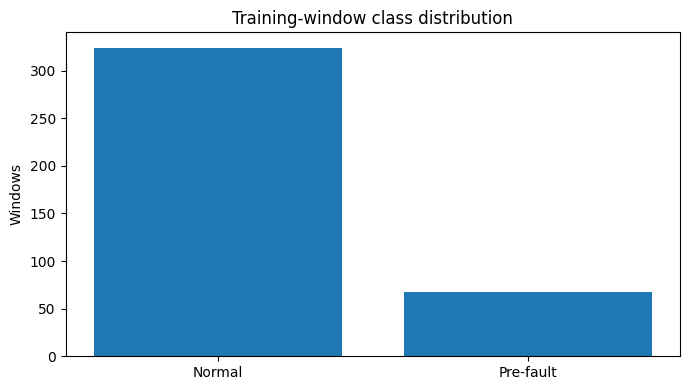

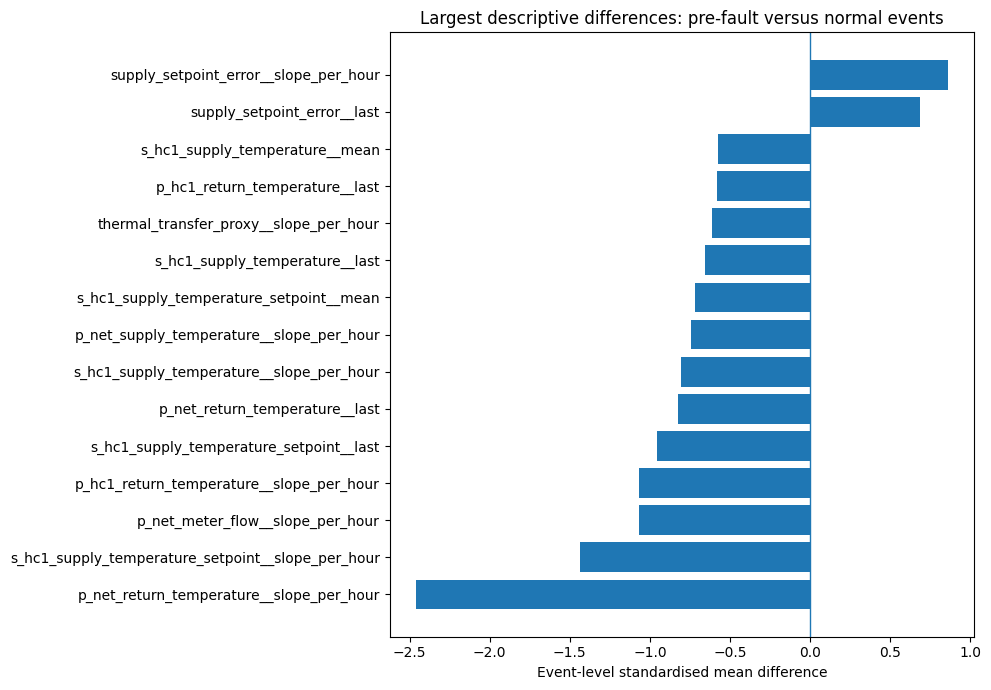

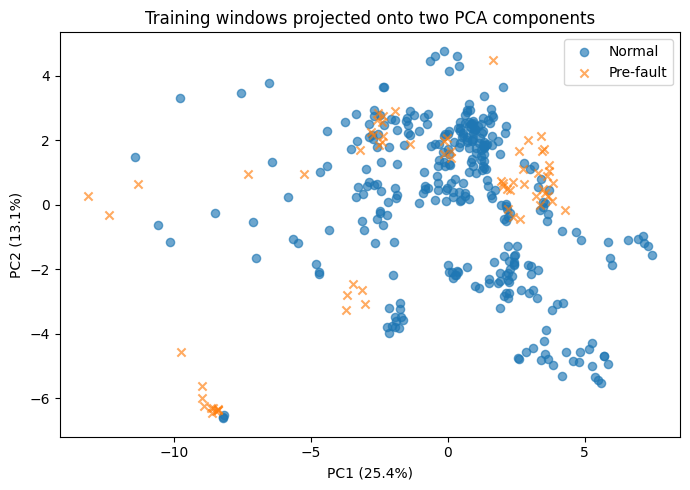

=== PRIMARY FEATURE SET ===
Name: compact_uncorrelated
Features: 49
Quality features included: []

=== TRAINING CLASS STRUCTURE ===
    class  windows  window_fraction  substations  events
   Normal      324            0.829           15      27
Pre-fault       67            0.171            9       9

=== TOP EVENT-LEVEL DESCRIPTIVE DIFFERENCES ===
                                                feature  normal_event_count  prefault_event_count  standardised_mean_difference  absolute_standardised_difference
         stat__p_net_return_temperature__slope_per_hour                  27                     9                        -2.458                             2.458
stat__s_hc1_supply_temperature_setpoint__slope_per_hour                  27                     9                        -1.437                             1.437
                 stat__p_net_meter_flow__slope_per_hour                  27                     9                        -1.068                             1.068


In [ ]:
# Phase 6: Training-only exploratory analysis

from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


# =========================================================
# 1. Paths and locked primary feature set
# =========================================================

FEATURE_PATH = Path(
    "/content/thermoguard_de/processed/"
    "thermoguard_features_24h.csv"
)

FEATURE_SETS_PATH = Path(
    "/content/thermoguard_de/processed/"
    "thermoguard_feature_sets.json"
)

RESULTS_DIR = Path(
    "/content/thermoguard_de/results"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


feature_table = pd.read_csv(
    FEATURE_PATH,
    parse_dates=[
        "window_start",
        "window_end",
        "Report date",
        "Possible anomaly start",
    ]
)

with open(
    FEATURE_SETS_PATH,
    "r",
    encoding="utf-8"
) as file:
    feature_sets = json.load(file)


PRIMARY_FEATURE_SET = "compact_uncorrelated"

primary_features = feature_sets[
    PRIMARY_FEATURE_SET
]

train_data = feature_table[
    feature_table["split"] == "train"
].copy()


# =========================================================
# 2. Protection checks
# =========================================================

if len(train_data) != 391:
    raise ValueError(
        f"Unexpected training rows: {len(train_data)}"
    )

if len(primary_features) != 49:
    raise ValueError(
        "Primary feature-set size has changed: "
        f"{len(primary_features)}"
    )

missing_features = (
    set(primary_features)
    - set(train_data.columns)
)

if missing_features:
    raise ValueError(
        f"Missing primary features: {missing_features}"
    )

quality_features_found = [
    feature
    for feature in primary_features
    if feature.startswith("quality__")
]

if quality_features_found:
    raise ValueError(
        "Quality variables unexpectedly entered "
        f"the primary set: {quality_features_found}"
    )

for feature in primary_features:
    train_data[feature] = pd.to_numeric(
        train_data[feature],
        errors="coerce"
    )


# =========================================================
# 3. Training class structure
# =========================================================

class_structure = (
    train_data
    .groupby("label")
    .agg(
        windows=("label", "size"),
        substations=("substation ID", "nunique"),
        events=("event_uid", "nunique"),
    )
    .reset_index()
)

class_structure["class"] = (
    class_structure["label"]
    .map({
        0: "Normal",
        1: "Pre-fault",
    })
)

class_structure["window_fraction"] = (
    class_structure["windows"]
    / class_structure["windows"].sum()
)


# =========================================================
# 4. Event-level feature aggregation
# =========================================================

# Median aggregation reduces pseudo-replication from multiple
# overlapping windows belonging to the same event.

event_level_features = (
    train_data
    .groupby(
        [
            "event_uid",
            "substation ID",
            "label",
        ],
        as_index=False
    )[primary_features]
    .median()
)

if (
    event_level_features[
        "event_uid"
    ].nunique()
    != 36
):
    raise ValueError(
        "Unexpected number of training events."
    )


# =========================================================
# 5. Event-level descriptive effect sizes
# =========================================================

effect_records = []

for feature in primary_features:

    normal_values = (
        event_level_features.loc[
            event_level_features["label"] == 0,
            feature,
        ]
        .dropna()
        .astype(float)
    )

    fault_values = (
        event_level_features.loc[
            event_level_features["label"] == 1,
            feature,
        ]
        .dropna()
        .astype(float)
    )

    n_normal = len(normal_values)
    n_fault = len(fault_values)

    normal_variance = (
        normal_values.var(ddof=1)
        if n_normal > 1
        else np.nan
    )

    fault_variance = (
        fault_values.var(ddof=1)
        if n_fault > 1
        else np.nan
    )

    denominator_df = (
        n_normal + n_fault - 2
    )

    if (
        denominator_df > 0
        and np.isfinite(normal_variance)
        and np.isfinite(fault_variance)
    ):
        pooled_variance = (
            (
                (n_normal - 1)
                * normal_variance
            )
            + (
                (n_fault - 1)
                * fault_variance
            )
        ) / denominator_df

        pooled_std = np.sqrt(
            pooled_variance
        )
    else:
        pooled_std = np.nan

    if (
        np.isfinite(pooled_std)
        and pooled_std > 0
    ):
        standardised_difference = (
            fault_values.mean()
            - normal_values.mean()
        ) / pooled_std
    else:
        standardised_difference = np.nan

    effect_records.append({
        "feature": feature,
        "normal_event_count": n_normal,
        "prefault_event_count": n_fault,
        "normal_event_mean": (
            normal_values.mean()
        ),
        "prefault_event_mean": (
            fault_values.mean()
        ),
        "normal_event_median": (
            normal_values.median()
        ),
        "prefault_event_median": (
            fault_values.median()
        ),
        "standardised_mean_difference": (
            standardised_difference
        ),
        "absolute_standardised_difference": (
            abs(standardised_difference)
            if np.isfinite(
                standardised_difference
            )
            else np.nan
        ),
    })


effect_table = (
    pd.DataFrame(effect_records)
    .sort_values(
        "absolute_standardised_difference",
        ascending=False
    )
    .reset_index(drop=True)
)


# =========================================================
# 6. Training-only preprocessing for correlation and PCA
# =========================================================

imputer = SimpleImputer(
    strategy="median"
)

scaler = StandardScaler()

X_train_imputed = imputer.fit_transform(
    train_data[primary_features]
)

X_train_scaled = scaler.fit_transform(
    X_train_imputed
)

if not np.isfinite(
    X_train_scaled
).all():
    raise ValueError(
        "Non-finite values remain after preprocessing."
    )


# =========================================================
# 7. Remaining correlation analysis
# =========================================================

scaled_frame = pd.DataFrame(
    X_train_scaled,
    columns=primary_features,
    index=train_data.index
)

correlation_matrix = (
    scaled_frame
    .corr()
    .abs()
)

upper_triangle = correlation_matrix.where(
    np.triu(
        np.ones(
            correlation_matrix.shape
        ),
        k=1
    ).astype(bool)
)

correlation_pairs = (
    upper_triangle
    .stack()
    .rename("absolute_correlation")
    .reset_index()
    .rename(
        columns={
            "level_0": "feature_1",
            "level_1": "feature_2",
        }
    )
    .sort_values(
        "absolute_correlation",
        ascending=False
    )
    .reset_index(drop=True)
)


# =========================================================
# 8. PCA visualisation
# =========================================================

pca = PCA(
    n_components=2,
    random_state=507
)

pca_scores = pca.fit_transform(
    X_train_scaled
)

pca_frame = pd.DataFrame({
    "PC1": pca_scores[:, 0],
    "PC2": pca_scores[:, 1],
    "label": train_data["label"].to_numpy(),
    "event_uid": train_data[
        "event_uid"
    ].to_numpy(),
    "substation ID": train_data[
        "substation ID"
    ].to_numpy(),
})


# =========================================================
# 9. Plot 1 — window and event class counts
# =========================================================

plot_counts = (
    class_structure
    .set_index("class")
)

plt.figure(figsize=(7, 4))

plt.bar(
    plot_counts.index,
    plot_counts["windows"]
)

plt.title(
    "Training-window class distribution"
)

plt.ylabel("Windows")
plt.tight_layout()

CLASS_PLOT_PATH = (
    RESULTS_DIR
    / "training_class_distribution.png"
)

plt.savefig(
    CLASS_PLOT_PATH,
    dpi=160,
    bbox_inches="tight"
)

plt.show()


# =========================================================
# 10. Plot 2 — event-level descriptive separation
# =========================================================

top_effects = (
    effect_table
    .dropna(
        subset=[
            "standardised_mean_difference"
        ]
    )
    .head(15)
    .copy()
)

top_effects["short_feature"] = (
    top_effects["feature"]
    .str.replace(
        "stat__",
        "",
        regex=False
    )
    .str.replace(
        "phys__",
        "",
        regex=False
    )
    .str.replace(
        "meter__",
        "",
        regex=False
    )
)

plot_effects = top_effects.sort_values(
    "standardised_mean_difference"
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_effects["short_feature"],
    plot_effects[
        "standardised_mean_difference"
    ]
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel(
    "Event-level standardised mean difference"
)

plt.title(
    "Largest descriptive differences: "
    "pre-fault versus normal events"
)

plt.tight_layout()

EFFECT_PLOT_PATH = (
    RESULTS_DIR
    / "training_event_effect_sizes.png"
)

plt.savefig(
    EFFECT_PLOT_PATH,
    dpi=160,
    bbox_inches="tight"
)

plt.show()


# =========================================================
# 11. Plot 3 — PCA projection
# =========================================================

plt.figure(figsize=(7, 5))

for label_value, label_name, marker in [
    (0, "Normal", "o"),
    (1, "Pre-fault", "x"),
]:
    subset = pca_frame[
        pca_frame["label"]
        == label_value
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=label_name,
        marker=marker,
        alpha=0.65,
        s=35,
    )

plt.xlabel(
    "PC1 "
    f"({pca.explained_variance_ratio_[0]:.1%})"
)

plt.ylabel(
    "PC2 "
    f"({pca.explained_variance_ratio_[1]:.1%})"
)

plt.title(
    "Training windows projected onto two PCA components"
)

plt.legend()
plt.tight_layout()

PCA_PLOT_PATH = (
    RESULTS_DIR
    / "training_pca_projection.png"
)

plt.savefig(
    PCA_PLOT_PATH,
    dpi=160,
    bbox_inches="tight"
)

plt.show()


# =========================================================
# 12. Save EDA outputs
# =========================================================

CLASS_STRUCTURE_PATH = (
    RESULTS_DIR
    / "training_class_structure.csv"
)

EVENT_FEATURE_PATH = (
    RESULTS_DIR
    / "training_event_level_features.csv"
)

EFFECT_TABLE_PATH = (
    RESULTS_DIR
    / "training_event_effect_sizes.csv"
)

CORRELATION_PAIRS_PATH = (
    RESULTS_DIR
    / "training_primary_feature_correlations.csv"
)

PCA_SCORES_PATH = (
    RESULTS_DIR
    / "training_pca_scores.csv"
)


class_structure.to_csv(
    CLASS_STRUCTURE_PATH,
    index=False
)

event_level_features.to_csv(
    EVENT_FEATURE_PATH,
    index=False
)

effect_table.to_csv(
    EFFECT_TABLE_PATH,
    index=False
)

correlation_pairs.to_csv(
    CORRELATION_PAIRS_PATH,
    index=False
)

pca_frame.to_csv(
    PCA_SCORES_PATH,
    index=False
)


# =========================================================
# 13. Display concise results
# =========================================================

print("=== PRIMARY FEATURE SET ===")
print("Name:", PRIMARY_FEATURE_SET)
print("Features:", len(primary_features))
print(
    "Quality features included:",
    quality_features_found
)


print("\n=== TRAINING CLASS STRUCTURE ===")
print(
    class_structure[
        [
            "class",
            "windows",
            "window_fraction",
            "substations",
            "events",
        ]
    ]
    .round(3)
    .to_string(index=False)
)


print("\n=== TOP EVENT-LEVEL DESCRIPTIVE DIFFERENCES ===")
print(
    effect_table[
        [
            "feature",
            "normal_event_count",
            "prefault_event_count",
            "standardised_mean_difference",
            "absolute_standardised_difference",
        ]
    ]
    .head(15)
    .round(3)
    .to_string(index=False)
)


print("\n=== HIGHEST REMAINING FEATURE CORRELATIONS ===")
print(
    correlation_pairs
    .head(15)
    .round(3)
    .to_string(index=False)
)


print("\n=== PCA SUMMARY ===")
print(
    "PC1 explained variance:",
    round(
        pca.explained_variance_ratio_[0],
        4
    )
)
print(
    "PC2 explained variance:",
    round(
        pca.explained_variance_ratio_[1],
        4
    )
)
print(
    "Combined two-component variance:",
    round(
        pca.explained_variance_ratio_[
            :2
        ].sum(),
        4
    )
)


print("\n=== SAVED EDA OUTPUTS ===")
print(CLASS_STRUCTURE_PATH)
print(EVENT_FEATURE_PATH)
print(EFFECT_TABLE_PATH)
print(CORRELATION_PAIRS_PATH)
print(PCA_SCORES_PATH)
print(CLASS_PLOT_PATH)
print(EFFECT_PLOT_PATH)
print(PCA_PLOT_PATH)


print(
    "\nPHASE 6 TRAINING-ONLY "
    "EXPLORATORY ANALYSIS COMPLETE"
)

## Section 6 — Evaluation framework

Under strong class imbalance, accuracy is misleading: a trivial all-normal classifier scores about 0.87 here while catching no faults. Following event-centred FDD practice (Neumayer *et al.*, 2023; Roelofs *et al.*, 2025), evaluation separates two levels.

**Window-level metrics:** PR-AUC (the primary model-selection metric, informative under imbalance), macro F1, balanced accuracy, pre-fault precision and recall, ROC-AUC and the confusion matrix.

**Event-level operational metrics:** event recall, warning lead time, the number of false-alert windows, and how many documented normal events triggered alerts. Catching a single window within a fault episode is operationally sufficient, whereas repeatedly missing the same event is a field failure. Throughout, windows are correlated observations and only events count as independent.


## Section 7 — Baselines and neural-network methodology

Three reference points anchor the neural work: a majority-class baseline (the imbalance floor), logistic regression (a linear comparison) and a reference MLP (a simple non-linear architecture). The core model is a compact multilayer perceptron (dense 64→32→16→sigmoid). ReLU hidden activations provide stable-gradient non-linearity; the sigmoid output yields a pre-fault score in [0, 1], trained with binary cross-entropy. Optimisation uses Adam (Kingma and Ba, 2015) at a learning rate of 5e-4, with early stopping and learning-rate reduction on validation loss to limit overfitting on a small dataset.

Regularisation combines dropout at 0.30 (Srivastava *et al.*, 2014) and L2 weight decay (1e-4). Imbalance is handled with class and event-class sample weighting, so scarce pre-fault windows contribute proportionally to the loss; a focal-loss variant (Lin *et al.*, 2017) is included as a controlled experiment. To reduce seed sensitivity, the final prediction is the mean score of five networks (seeds 107–507).


In [ ]:
# Phase 7: Majority baseline, logistic regression and reference MLP

from pathlib import Path
import json
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


# =========================================================
# 1. Reproducibility
# =========================================================

SEED = 507

np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass


# =========================================================
# 2. Paths
# =========================================================

FEATURE_PATH = Path(
    "/content/thermoguard_de/processed/"
    "thermoguard_features_24h.csv"
)

FEATURE_SETS_PATH = Path(
    "/content/thermoguard_de/processed/"
    "thermoguard_feature_sets.json"
)

RESULTS_DIR = Path(
    "/content/thermoguard_de/results"
)

MODELS_DIR = Path(
    "/content/thermoguard_de/models"
)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

REGISTRY_PATH = (
    RESULTS_DIR
    / "experiment_registry.csv"
)


# =========================================================
# 3. Load train and validation data only
# =========================================================

feature_table = pd.read_csv(
    FEATURE_PATH
)

with open(
    FEATURE_SETS_PATH,
    "r",
    encoding="utf-8"
) as file:
    feature_sets = json.load(file)

FEATURE_SET_NAME = "compact_uncorrelated"
FEATURE_COLUMNS = feature_sets[FEATURE_SET_NAME]

train_data = feature_table[
    feature_table["split"] == "train"
].copy()

validation_data = feature_table[
    feature_table["split"] == "validation"
].copy()


if len(train_data) != 391:
    raise ValueError(
        f"Unexpected training rows: {len(train_data)}"
    )

if len(validation_data) != 114:
    raise ValueError(
        "Unexpected validation rows: "
        f"{len(validation_data)}"
    )

if len(FEATURE_COLUMNS) != 49:
    raise ValueError(
        "Primary feature-set size changed: "
        f"{len(FEATURE_COLUMNS)}"
    )


X_train_frame = train_data[
    FEATURE_COLUMNS
].apply(
    pd.to_numeric,
    errors="coerce"
)

X_validation_frame = validation_data[
    FEATURE_COLUMNS
].apply(
    pd.to_numeric,
    errors="coerce"
)

y_train = train_data[
    "label"
].astype(int).to_numpy()

y_validation = validation_data[
    "label"
].astype(int).to_numpy()


print("=== DATA PROTECTION CHECK ===")
print("Training rows:", len(y_train))
print("Validation rows:", len(y_validation))
print("Features:", len(FEATURE_COLUMNS))
print(
    "Training positive prevalence:",
    round(float(y_train.mean()), 4)
)
print(
    "Validation positive prevalence:",
    round(float(y_validation.mean()), 4)
)
print("Test data used in this phase: False")


# =========================================================
# 4. Shared metric function
# =========================================================

def calculate_validation_metrics(
    y_true,
    probabilities,
    threshold=0.50
):
    probabilities = np.asarray(
        probabilities,
        dtype=float
    ).reshape(-1)

    predictions = (
        probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1]
    ).ravel()

    return {
        "threshold": float(threshold),
        "accuracy": float(
            accuracy_score(
                y_true,
                predictions
            )
        ),
        "balanced_accuracy": float(
            balanced_accuracy_score(
                y_true,
                predictions
            )
        ),
        "macro_f1": float(
            f1_score(
                y_true,
                predictions,
                average="macro",
                zero_division=0
            )
        ),
        "precision": float(
            precision_score(
                y_true,
                predictions,
                zero_division=0
            )
        ),
        "recall": float(
            recall_score(
                y_true,
                predictions,
                zero_division=0
            )
        ),
        "pr_auc": float(
            average_precision_score(
                y_true,
                probabilities
            )
        ),
        "roc_auc": float(
            roc_auc_score(
                y_true,
                probabilities
            )
        ),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def create_registry_row(
    experiment_id,
    model_name,
    metrics,
    feature_set,
    feature_count,
    trainable_parameters,
    best_epoch,
    training_seconds,
    class_weighting,
    notes
):
    return {
        "experiment_id": experiment_id,
        "model_name": model_name,
        "feature_set": feature_set,
        "feature_count": feature_count,
        "class_weighting": class_weighting,
        "threshold": metrics["threshold"],
        "trainable_parameters": trainable_parameters,
        "best_epoch": best_epoch,
        "training_seconds": training_seconds,
        "validation_accuracy": metrics["accuracy"],
        "validation_balanced_accuracy": (
            metrics["balanced_accuracy"]
        ),
        "validation_macro_f1": metrics["macro_f1"],
        "validation_precision": metrics["precision"],
        "validation_recall": metrics["recall"],
        "validation_pr_auc": metrics["pr_auc"],
        "validation_roc_auc": metrics["roc_auc"],
        "tn": metrics["tn"],
        "fp": metrics["fp"],
        "fn": metrics["fn"],
        "tp": metrics["tp"],
        "notes": notes,
    }


experiment_rows = []


# =========================================================
# 5. EXP00 — Majority-class baseline
# =========================================================

majority_start = time.perf_counter()

# Constant score equal to the training-set prevalence.
# The 0.50 threshold still predicts every window as normal.
majority_probabilities = np.full(
    shape=len(y_validation),
    fill_value=float(y_train.mean())
)

majority_metrics = calculate_validation_metrics(
    y_validation,
    majority_probabilities,
    threshold=0.50
)

majority_seconds = (
    time.perf_counter()
    - majority_start
)

experiment_rows.append(
    create_registry_row(
        experiment_id="EXP00",
        model_name="Majority baseline",
        metrics=majority_metrics,
        feature_set="none",
        feature_count=0,
        trainable_parameters=0,
        best_epoch=np.nan,
        training_seconds=majority_seconds,
        class_weighting="none",
        notes=(
            "Constant training-prevalence score; "
            "all classifications normal at threshold 0.50."
        )
    )
)


# =========================================================
# 6. EXP01 — Logistic-regression baseline
# =========================================================

logistic_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=5000,
            solver="lbfgs",
            random_state=SEED,
            class_weight=None
        )
    ),
])

logistic_start = time.perf_counter()

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    logistic_pipeline.fit(
        X_train_frame,
        y_train
    )

logistic_seconds = (
    time.perf_counter()
    - logistic_start
)

logistic_probabilities = (
    logistic_pipeline
    .predict_proba(
        X_validation_frame
    )[:, 1]
)

logistic_metrics = calculate_validation_metrics(
    y_validation,
    logistic_probabilities,
    threshold=0.50
)

logistic_classifier = (
    logistic_pipeline
    .named_steps["classifier"]
)

logistic_parameter_count = int(
    logistic_classifier.coef_.size
    + logistic_classifier.intercept_.size
)

experiment_rows.append(
    create_registry_row(
        experiment_id="EXP01",
        model_name="Logistic regression",
        metrics=logistic_metrics,
        feature_set=FEATURE_SET_NAME,
        feature_count=len(FEATURE_COLUMNS),
        trainable_parameters=(
            logistic_parameter_count
        ),
        best_epoch=np.nan,
        training_seconds=logistic_seconds,
        class_weighting="none",
        notes=(
            "Linear reference with median imputation "
            "and standard scaling."
        )
    )
)

joblib.dump(
    logistic_pipeline,
    MODELS_DIR
    / "exp01_logistic_pipeline.joblib"
)


# =========================================================
# 7. Fit neural preprocessing on training only
# =========================================================

neural_preprocessor = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "scaler",
        StandardScaler()
    ),
])

X_train = neural_preprocessor.fit_transform(
    X_train_frame
)

X_validation = neural_preprocessor.transform(
    X_validation_frame
)

if not np.isfinite(X_train).all():
    raise ValueError(
        "Non-finite values in processed training data."
    )

if not np.isfinite(X_validation).all():
    raise ValueError(
        "Non-finite values in processed validation data."
    )

joblib.dump(
    neural_preprocessor,
    MODELS_DIR
    / "exp02_reference_mlp_preprocessor.joblib"
)


# =========================================================
# 8. EXP02 — Compact reference MLP
# =========================================================

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)


def build_reference_mlp(input_dimension):
    inputs = tf.keras.Input(
        shape=(input_dimension,),
        name="engineered_features"
    )

    x = tf.keras.layers.Dense(
        32,
        activation="relu",
        kernel_initializer="he_normal",
        name="dense_32"
    )(inputs)

    x = tf.keras.layers.Dense(
        16,
        activation="relu",
        kernel_initializer="he_normal",
        name="dense_16"
    )(x)

    outputs = tf.keras.layers.Dense(
        1,
        activation="sigmoid",
        name="prefault_probability"
    )(x)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="thermoguard_reference_mlp"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=1e-3
        ),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(
                name="accuracy"
            ),
            tf.keras.metrics.Precision(
                name="precision"
            ),
            tf.keras.metrics.Recall(
                name="recall"
            ),
            tf.keras.metrics.AUC(
                curve="PR",
                name="pr_auc"
            ),
            tf.keras.metrics.AUC(
                curve="ROC",
                name="roc_auc"
            ),
        ]
    )

    return model


reference_mlp = build_reference_mlp(
    input_dimension=X_train.shape[1]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_pr_auc",
        mode="max",
        patience=20,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=0
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_pr_auc",
        mode="max",
        factor=0.5,
        patience=8,
        min_lr=1e-5,
        verbose=0
    ),
]

mlp_start = time.perf_counter()

history = reference_mlp.fit(
    X_train,
    y_train,
    validation_data=(
        X_validation,
        y_validation
    ),
    epochs=200,
    batch_size=32,
    callbacks=callbacks,
    verbose=0,
    shuffle=True
)

mlp_seconds = (
    time.perf_counter()
    - mlp_start
)

validation_probabilities = (
    reference_mlp.predict(
        X_validation,
        verbose=0
    )
    .reshape(-1)
)

mlp_metrics = calculate_validation_metrics(
    y_validation,
    validation_probabilities,
    threshold=0.50
)

best_epoch = int(
    np.argmax(
        history.history["val_pr_auc"]
    ) + 1
)

trainable_parameters = int(
    reference_mlp.count_params()
)

experiment_rows.append(
    create_registry_row(
        experiment_id="EXP02",
        model_name="Reference MLP 32-16",
        metrics=mlp_metrics,
        feature_set=FEATURE_SET_NAME,
        feature_count=len(FEATURE_COLUMNS),
        trainable_parameters=(
            trainable_parameters
        ),
        best_epoch=best_epoch,
        training_seconds=mlp_seconds,
        class_weighting="none",
        notes=(
            "ReLU 32-16 architecture, Adam 1e-3, "
            "early stopping on validation PR-AUC."
        )
    )
)

reference_mlp.save(
    MODELS_DIR
    / "exp02_reference_mlp.keras"
)


# =========================================================
# 9. Create and save experiment registry
# =========================================================

current_registry = pd.DataFrame(
    experiment_rows
)

if REGISTRY_PATH.exists():
    previous_registry = pd.read_csv(
        REGISTRY_PATH
    )

    previous_registry = previous_registry[
        ~previous_registry[
            "experiment_id"
        ].isin(
            current_registry[
                "experiment_id"
            ]
        )
    ]

    experiment_registry = pd.concat(
        [
            previous_registry,
            current_registry,
        ],
        ignore_index=True
    )
else:
    experiment_registry = (
        current_registry.copy()
    )

experiment_registry = (
    experiment_registry
    .sort_values("experiment_id")
    .reset_index(drop=True)
)

experiment_registry.to_csv(
    REGISTRY_PATH,
    index=False
)


# =========================================================
# 10. Save training history and validation predictions
# =========================================================

history_frame = pd.DataFrame(
    history.history
)

history_frame["epoch"] = (
    np.arange(len(history_frame)) + 1
)

HISTORY_PATH = (
    RESULTS_DIR
    / "exp02_reference_mlp_history.csv"
)

history_frame.to_csv(
    HISTORY_PATH,
    index=False
)


validation_prediction_table = (
    validation_data[
        [
            "substation ID",
            "event_id",
            "event_type",
            "window_end",
            "label",
        ]
    ]
    .copy()
)

validation_prediction_table[
    "majority_probability"
] = majority_probabilities

validation_prediction_table[
    "logistic_probability"
] = logistic_probabilities

validation_prediction_table[
    "reference_mlp_probability"
] = validation_probabilities

PREDICTION_PATH = (
    RESULTS_DIR
    / "phase7_validation_predictions.csv"
)

validation_prediction_table.to_csv(
    PREDICTION_PATH,
    index=False
)


# =========================================================
# 11. Display results
# =========================================================

display_columns = [
    "experiment_id",
    "model_name",
    "feature_set",
    "feature_count",
    "trainable_parameters",
    "best_epoch",
    "validation_accuracy",
    "validation_balanced_accuracy",
    "validation_macro_f1",
    "validation_precision",
    "validation_recall",
    "validation_pr_auc",
    "validation_roc_auc",
    "tn",
    "fp",
    "fn",
    "tp",
]


print("\n=== VALIDATION EXPERIMENT RESULTS ===")
print(
    experiment_registry[
        display_columns
    ]
    .round(4)
    .to_string(index=False)
)


print("\n=== VALIDATION CONFUSION MATRICES ===")

for experiment_id, model_name, metrics in [
    (
        "EXP00",
        "Majority baseline",
        majority_metrics
    ),
    (
        "EXP01",
        "Logistic regression",
        logistic_metrics
    ),
    (
        "EXP02",
        "Reference MLP",
        mlp_metrics
    ),
]:
    matrix = np.array([
        [
            metrics["tn"],
            metrics["fp"]
        ],
        [
            metrics["fn"],
            metrics["tp"]
        ],
    ])

    print(
        f"\n{experiment_id} — {model_name}"
    )
    print(
        pd.DataFrame(
            matrix,
            index=[
                "Actual normal",
                "Actual pre-fault"
            ],
            columns=[
                "Predicted normal",
                "Predicted pre-fault"
            ]
        ).to_string()
    )


print("\n=== REFERENCE MLP TRAINING ===")
print(
    "Epochs completed:",
    len(history_frame)
)
print(
    "Best validation PR-AUC epoch:",
    best_epoch
)
print(
    "Best recorded validation PR-AUC:",
    round(
        float(
            history_frame[
                "val_pr_auc"
            ].max()
        ),
        4
    )
)
print(
    "Final learning rate:",
    float(
        history_frame[
            "learning_rate"
        ].iloc[-1]
    )
    if "learning_rate"
    in history_frame.columns
    else "Not recorded"
)
print(
    "Trainable parameters:",
    trainable_parameters
)


print("\n=== SAVED PHASE 7 FILES ===")
print(REGISTRY_PATH)
print(HISTORY_PATH)
print(PREDICTION_PATH)
print(
    MODELS_DIR
    / "exp01_logistic_pipeline.joblib"
)
print(
    MODELS_DIR
    / "exp02_reference_mlp.keras"
)
print(
    MODELS_DIR
    / "exp02_reference_mlp_preprocessor.joblib"
)

print(
    "\nPHASE 7 BASELINE AND "
    "REFERENCE-MODEL TRAINING COMPLETE"
)

=== DATA PROTECTION CHECK ===
Training rows: 391
Validation rows: 114
Features: 49
Training positive prevalence: 0.1714
Validation positive prevalence: 0.1316
Test data used in this phase: False

=== VALIDATION EXPERIMENT RESULTS ===
experiment_id          model_name          feature_set  feature_count  trainable_parameters  best_epoch  validation_accuracy  validation_balanced_accuracy  validation_macro_f1  validation_precision  validation_recall  validation_pr_auc  validation_roc_auc  tn  fp  fn  tp
        EXP00   Majority baseline                 none              0                     0         NaN               0.8684                        0.5000               0.4648                0.0000                0.0             0.1316              0.5000  99   0  15   0
        EXP01 Logistic regression compact_uncorrelated             49                    50         NaN               0.6491                        0.4586               0.4553                0.0968                0.2      

## Section 8 — Controlled experimental design

Thirteen configurations (EXP00–EXP12) are produced with a reusable model builder and training routine driven by a single configuration registry, so that architecture, feature set, regularisation, imbalance treatment and loss vary in a controlled way. The configuration table below summarises the design; validation results follow in Section 9.

| ID | Model | Hidden units | Feature set | Regularisation | Imbalance treatment | Loss |
| --- | --- | --- | --- | --- | --- | --- |
| EXP00 | Majority baseline | — | — | — | — | — |
| EXP01 | Logistic regression | — | compact (49) | L2 (default) | none | log loss |
| EXP02 | Reference MLP | 32-16 | compact (49) | none | none | BCE |
| EXP03 | Class-weighted MLP | 32-16 | compact (49) | none | class weights | BCE |
| EXP04 | Event-class-weighted MLP | 32-16 | compact (49) | none | event-class weights | BCE |
| EXP05 | Dropout MLP | 32-16 | compact (49) | dropout 0.30 | none | BCE |
| EXP06 | Batch-norm dropout MLP | 32-16 | compact (49) | dropout + batch norm | none | BCE |
| EXP07 | Shallow weighted MLP | 16 | compact (49) | none | class weights | BCE |
| EXP08 | Deep regularised MLP | 64-32-16 | compact (49) | dropout 0.30 + L2 1e-4 | event-class weights | BCE |
| EXP09 | Physics-only MLP | 32-16 | physics (40) | none | class weights | BCE |
| EXP10 | Statistical-only MLP | 32-16 | statistical (64) | none | class weights | BCE |
| EXP11 | Full engineered MLP | 64-32-16 | all engineered (115) | L2 1e-4 | none | BCE |
| EXP12 | Focal-loss MLP | 32-16 | compact (49) | none | focal weighting | focal |

The cells below report validation event-level and threshold diagnostics, then train the full controlled grid.


=== DATA PROTECTION CHECK ===
Validation rows: 114
Validation positive windows: 15
Validation positive events: 3
Test data used in this phase: False


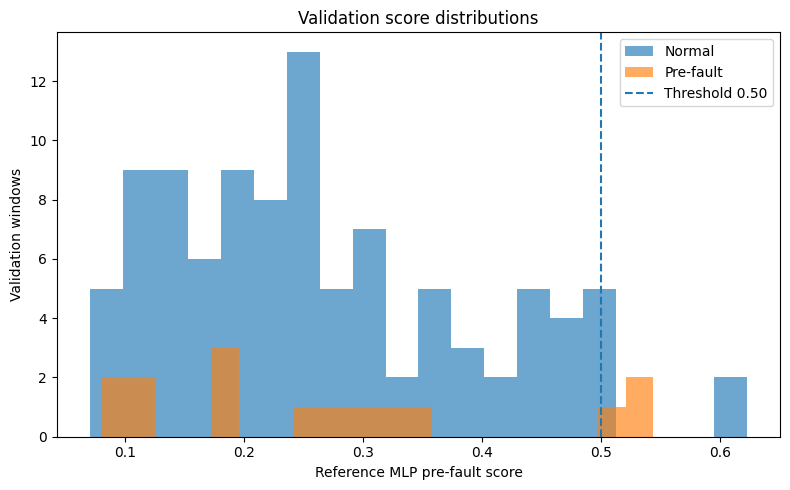

=== VALIDATION PROBABILITY SUMMARY ===
              model     class  count   mean    std  minimum    q25  median    q75  maximum
     EXP00 Majority    Normal     99 0.1714 0.0000   0.1714 0.1714  0.1714 0.1714   0.1714
     EXP00 Majority Pre-fault     15 0.1714 0.0000   0.1714 0.1714  0.1714 0.1714   0.1714
     EXP01 Logistic    Normal     99 0.2913 0.3722   0.0010 0.0081  0.0409 0.6113   0.9981
     EXP01 Logistic Pre-fault     15 0.2001 0.2994   0.0000 0.0017  0.0084 0.2396   0.8703
EXP02 Reference MLP    Normal     99 0.2653 0.1281   0.0703 0.1670  0.2415 0.3622   0.6227
EXP02 Reference MLP Pre-fault     15 0.2696 0.1495   0.0797 0.1506  0.2553 0.3316   0.5438

=== THRESHOLD 0.50 SUMMARY ===
              model  macro_f1  balanced_accuracy  precision  recall  pr_auc  roc_auc  tp  fp  fn  tn  event_recall  detected_fault_events  normal_false_alert_windows  normal_events_alerted  median_warning_hours
     EXP00 Majority    0.4648             0.5000     0.0000     0.0  0.1316   0.5

In [ ]:
# Phase 8: Validation event-level and threshold diagnostics

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)


# =========================================================
# 1. Paths
# =========================================================

FEATURE_PATH = Path(
    "/content/thermoguard_de/processed/"
    "thermoguard_features_24h.csv"
)

PREDICTION_PATH = Path(
    "/content/thermoguard_de/results/"
    "phase7_validation_predictions.csv"
)

RESULTS_DIR = Path(
    "/content/thermoguard_de/results"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# =========================================================
# 2. Load validation predictions and metadata
# =========================================================

feature_table = pd.read_csv(
    FEATURE_PATH,
    parse_dates=[
        "window_start",
        "window_end",
        "Report date",
        "Possible anomaly start",
    ]
)

predictions = pd.read_csv(
    PREDICTION_PATH,
    parse_dates=["window_end"]
)

validation_metadata = feature_table.loc[
    feature_table["split"] == "validation",
    [
        "substation ID",
        "event_id",
        "event_type",
        "window_end",
        "label",
        "problem_category",
        "hours_to_report",
    ],
].copy()


for frame in [
    predictions,
    validation_metadata,
]:
    frame["substation ID"] = pd.to_numeric(
        frame["substation ID"],
        errors="raise"
    ).astype(int)

    frame["event_id"] = pd.to_numeric(
        frame["event_id"],
        errors="raise"
    ).astype(int)

    frame["label"] = pd.to_numeric(
        frame["label"],
        errors="raise"
    ).astype(int)


validation_predictions = predictions.merge(
    validation_metadata,
    on=[
        "substation ID",
        "event_id",
        "event_type",
        "window_end",
        "label",
    ],
    how="left",
    validate="one_to_one"
)


if len(validation_predictions) != 114:
    raise ValueError(
        "Validation prediction row count changed: "
        f"{len(validation_predictions)}"
    )

if validation_predictions[
    "problem_category"
].isna().any():
    raise ValueError(
        "Validation metadata merge failed."
    )


validation_predictions["event_uid"] = (
    validation_predictions["event_type"]
    .astype(str)
    + "_"
    + validation_predictions["event_id"]
    .astype(str)
)


MODEL_COLUMNS = {
    "EXP00 Majority": "majority_probability",
    "EXP01 Logistic": "logistic_probability",
    "EXP02 Reference MLP": (
        "reference_mlp_probability"
    ),
}


print("=== DATA PROTECTION CHECK ===")
print(
    "Validation rows:",
    len(validation_predictions)
)
print(
    "Validation positive windows:",
    int(
        validation_predictions["label"].sum()
    )
)
print(
    "Validation positive events:",
    validation_predictions.loc[
        validation_predictions["label"] == 1,
        "event_uid",
    ].nunique()
)
print("Test data used in this phase: False")


# =========================================================
# 3. Window-level metric function
# =========================================================

def calculate_window_metrics(
    data,
    probability_column,
    threshold
):
    y_true = data["label"].to_numpy()

    probabilities = data[
        probability_column
    ].to_numpy(dtype=float)

    predictions_binary = (
        probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions_binary,
        labels=[0, 1]
    ).ravel()

    return {
        "threshold": float(threshold),
        "accuracy": float(
            accuracy_score(
                y_true,
                predictions_binary
            )
        ),
        "balanced_accuracy": float(
            balanced_accuracy_score(
                y_true,
                predictions_binary
            )
        ),
        "macro_f1": float(
            f1_score(
                y_true,
                predictions_binary,
                average="macro",
                zero_division=0
            )
        ),
        "precision": float(
            precision_score(
                y_true,
                predictions_binary,
                zero_division=0
            )
        ),
        "recall": float(
            recall_score(
                y_true,
                predictions_binary,
                zero_division=0
            )
        ),
        "pr_auc": float(
            average_precision_score(
                y_true,
                probabilities
            )
        ),
        "roc_auc": float(
            roc_auc_score(
                y_true,
                probabilities
            )
        ),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


# =========================================================
# 4. Event-level metric function
# =========================================================

def calculate_event_metrics(
    data,
    probability_column,
    threshold
):
    working = data.copy()

    working["alert"] = (
        working[probability_column]
        >= threshold
    )

    positive_data = working[
        working["label"] == 1
    ]

    normal_data = working[
        working["label"] == 0
    ]

    positive_event_records = []

    for (
        substation_id,
        event_id,
        problem_category
    ), group in positive_data.groupby(
        [
            "substation ID",
            "event_id",
            "problem_category",
        ]
    ):
        alerted_rows = group[
            group["alert"]
        ]

        detected = not alerted_rows.empty

        earliest_warning_hours = (
            float(
                alerted_rows[
                    "hours_to_report"
                ].max()
            )
            if detected
            else np.nan
        )

        positive_event_records.append({
            "substation ID": substation_id,
            "event_id": event_id,
            "problem_category": (
                problem_category
            ),
            "positive_windows": len(group),
            "maximum_probability": float(
                group[
                    probability_column
                ].max()
            ),
            "detected": detected,
            "alerted_positive_windows": int(
                group["alert"].sum()
            ),
            "earliest_warning_hours": (
                earliest_warning_hours
            ),
        })

    positive_events = pd.DataFrame(
        positive_event_records
    )

    normal_event_summary = (
        normal_data
        .groupby(
            [
                "substation ID",
                "event_id",
            ]
        )
        .agg(
            normal_windows=(
                "label",
                "size"
            ),
            false_alert_windows=(
                "alert",
                "sum"
            ),
            maximum_probability=(
                probability_column,
                "max"
            ),
        )
        .reset_index()
    )

    normal_event_summary[
        "event_alerted"
    ] = (
        normal_event_summary[
            "false_alert_windows"
        ] > 0
    )

    detected_events = int(
        positive_events[
            "detected"
        ].sum()
    )

    positive_event_count = len(
        positive_events
    )

    event_recall = (
        detected_events
        / positive_event_count
        if positive_event_count
        else np.nan
    )

    detected_warning_times = (
        positive_events.loc[
            positive_events["detected"],
            "earliest_warning_hours",
        ]
        .dropna()
    )

    return {
        "event_recall": float(
            event_recall
        ),
        "detected_fault_events": (
            detected_events
        ),
        "total_fault_events": (
            positive_event_count
        ),
        "normal_false_alert_windows": int(
            normal_data["alert"].sum()
        ),
        "normal_events_alerted": int(
            normal_event_summary[
                "event_alerted"
            ].sum()
        ),
        "total_normal_events": len(
            normal_event_summary
        ),
        "median_warning_hours": (
            float(
                detected_warning_times.median()
            )
            if not detected_warning_times.empty
            else np.nan
        ),
        "maximum_warning_hours": (
            float(
                detected_warning_times.max()
            )
            if not detected_warning_times.empty
            else np.nan
        ),
        "positive_event_table": (
            positive_events
        ),
        "normal_event_table": (
            normal_event_summary
        ),
    }


# =========================================================
# 5. Probability distributions
# =========================================================

probability_summary_records = []

for model_name, probability_column in (
    MODEL_COLUMNS.items()
):
    for label_value, class_name in [
        (0, "Normal"),
        (1, "Pre-fault"),
    ]:
        values = validation_predictions.loc[
            validation_predictions["label"]
            == label_value,
            probability_column,
        ].astype(float)

        probability_summary_records.append({
            "model": model_name,
            "class": class_name,
            "count": len(values),
            "mean": values.mean(),
            "std": values.std(ddof=0),
            "minimum": values.min(),
            "q25": values.quantile(0.25),
            "median": values.median(),
            "q75": values.quantile(0.75),
            "maximum": values.max(),
        })


probability_summary = pd.DataFrame(
    probability_summary_records
)


# =========================================================
# 6. Event analysis at threshold 0.50
# =========================================================

threshold_050_records = []
event_tables_050 = {}

for model_name, probability_column in (
    MODEL_COLUMNS.items()
):
    window_metrics = (
        calculate_window_metrics(
            validation_predictions,
            probability_column,
            threshold=0.50
        )
    )

    event_metrics = (
        calculate_event_metrics(
            validation_predictions,
            probability_column,
            threshold=0.50
        )
    )

    threshold_050_records.append({
        "model": model_name,
        **{
            key: value
            for key, value
            in window_metrics.items()
        },
        "event_recall": (
            event_metrics["event_recall"]
        ),
        "detected_fault_events": (
            event_metrics[
                "detected_fault_events"
            ]
        ),
        "normal_false_alert_windows": (
            event_metrics[
                "normal_false_alert_windows"
            ]
        ),
        "normal_events_alerted": (
            event_metrics[
                "normal_events_alerted"
            ]
        ),
        "median_warning_hours": (
            event_metrics[
                "median_warning_hours"
            ]
        ),
    })

    event_tables_050[model_name] = (
        event_metrics[
            "positive_event_table"
        ]
    )


threshold_050_summary = pd.DataFrame(
    threshold_050_records
)


# =========================================================
# 7. Validation-only threshold sweep
# =========================================================

thresholds = np.round(
    np.arange(
        0.05,
        0.951,
        0.01
    ),
    2
)

threshold_records = []

for model_name, probability_column in (
    MODEL_COLUMNS.items()
):
    for threshold in thresholds:
        window_metrics = (
            calculate_window_metrics(
                validation_predictions,
                probability_column,
                threshold
            )
        )

        event_metrics = (
            calculate_event_metrics(
                validation_predictions,
                probability_column,
                threshold
            )
        )

        threshold_records.append({
            "model": model_name,
            **window_metrics,
            "event_recall": (
                event_metrics[
                    "event_recall"
                ]
            ),
            "detected_fault_events": (
                event_metrics[
                    "detected_fault_events"
                ]
            ),
            "normal_false_alert_windows": (
                event_metrics[
                    "normal_false_alert_windows"
                ]
            ),
            "normal_events_alerted": (
                event_metrics[
                    "normal_events_alerted"
                ]
            ),
            "median_warning_hours": (
                event_metrics[
                    "median_warning_hours"
                ]
            ),
        })


threshold_sweep = pd.DataFrame(
    threshold_records
)


# =========================================================
# 8. Best validation threshold summaries
# =========================================================

best_threshold_records = []

for model_name in MODEL_COLUMNS:

    model_thresholds = threshold_sweep[
        threshold_sweep["model"]
        == model_name
    ].copy()

    best_macro_row = (
        model_thresholds
        .sort_values(
            [
                "macro_f1",
                "event_recall",
                "normal_false_alert_windows",
            ],
            ascending=[
                False,
                False,
                True,
            ]
        )
        .iloc[0]
    )

    best_balanced_row = (
        model_thresholds
        .sort_values(
            [
                "balanced_accuracy",
                "event_recall",
                "normal_false_alert_windows",
            ],
            ascending=[
                False,
                False,
                True,
            ]
        )
        .iloc[0]
    )

    best_threshold_records.extend([
        {
            "model": model_name,
            "selection_rule": (
                "Maximum macro F1"
            ),
            **best_macro_row.to_dict(),
        },
        {
            "model": model_name,
            "selection_rule": (
                "Maximum balanced accuracy"
            ),
            **best_balanced_row.to_dict(),
        },
    ])


best_thresholds = pd.DataFrame(
    best_threshold_records
)


# =========================================================
# 9. Reference MLP threshold candidates
# =========================================================

reference_candidates = (
    threshold_sweep[
        threshold_sweep["model"]
        == "EXP02 Reference MLP"
    ]
    .sort_values(
        [
            "macro_f1",
            "event_recall",
            "normal_false_alert_windows",
        ],
        ascending=[
            False,
            False,
            True,
        ]
    )
    .head(12)
)


# =========================================================
# 10. Probability-distribution plot
# =========================================================

normal_probabilities = (
    validation_predictions.loc[
        validation_predictions["label"]
        == 0,
        "reference_mlp_probability",
    ]
)

fault_probabilities = (
    validation_predictions.loc[
        validation_predictions["label"]
        == 1,
        "reference_mlp_probability",
    ]
)

plt.figure(figsize=(8, 5))

plt.hist(
    normal_probabilities,
    bins=20,
    alpha=0.65,
    label="Normal"
)

plt.hist(
    fault_probabilities,
    bins=20,
    alpha=0.65,
    label="Pre-fault"
)

plt.axvline(
    0.50,
    linestyle="--",
    label="Threshold 0.50"
)

plt.xlabel(
    "Reference MLP pre-fault score"
)

plt.ylabel("Validation windows")

plt.title(
    "Validation score distributions"
)

plt.legend()
plt.tight_layout()

PLOT_PATH = (
    RESULTS_DIR
    / "phase8_validation_score_distribution.png"
)

plt.savefig(
    PLOT_PATH,
    dpi=160,
    bbox_inches="tight"
)

plt.show()


# =========================================================
# 11. Save diagnostics
# =========================================================

PROBABILITY_SUMMARY_PATH = (
    RESULTS_DIR
    / "phase8_probability_summary.csv"
)

THRESHOLD_050_PATH = (
    RESULTS_DIR
    / "phase8_threshold_050_summary.csv"
)

THRESHOLD_SWEEP_PATH = (
    RESULTS_DIR
    / "phase8_threshold_sweep.csv"
)

BEST_THRESHOLDS_PATH = (
    RESULTS_DIR
    / "phase8_best_thresholds.csv"
)

EVENT_DETAILS_PATH = (
    RESULTS_DIR
    / "phase8_reference_mlp_event_details_050.csv"
)


probability_summary.to_csv(
    PROBABILITY_SUMMARY_PATH,
    index=False
)

threshold_050_summary.to_csv(
    THRESHOLD_050_PATH,
    index=False
)

threshold_sweep.to_csv(
    THRESHOLD_SWEEP_PATH,
    index=False
)

best_thresholds.to_csv(
    BEST_THRESHOLDS_PATH,
    index=False
)

event_tables_050[
    "EXP02 Reference MLP"
].to_csv(
    EVENT_DETAILS_PATH,
    index=False
)


# =========================================================
# 12. Display results
# =========================================================

print("=== VALIDATION PROBABILITY SUMMARY ===")
print(
    probability_summary
    .round(4)
    .to_string(index=False)
)


print("\n=== THRESHOLD 0.50 SUMMARY ===")

threshold_display_columns = [
    "model",
    "macro_f1",
    "balanced_accuracy",
    "precision",
    "recall",
    "pr_auc",
    "roc_auc",
    "tp",
    "fp",
    "fn",
    "tn",
    "event_recall",
    "detected_fault_events",
    "normal_false_alert_windows",
    "normal_events_alerted",
    "median_warning_hours",
]

print(
    threshold_050_summary[
        threshold_display_columns
    ]
    .round(4)
    .to_string(index=False)
)


print(
    "\n=== REFERENCE MLP EVENT DETAILS "
    "AT THRESHOLD 0.50 ==="
)

print(
    event_tables_050[
        "EXP02 Reference MLP"
    ]
    .round(4)
    .to_string(index=False)
)


print(
    "\n=== BEST VALIDATION THRESHOLDS "
    "BY RULE ==="
)

best_display_columns = [
    "model",
    "selection_rule",
    "threshold",
    "macro_f1",
    "balanced_accuracy",
    "precision",
    "recall",
    "event_recall",
    "detected_fault_events",
    "normal_false_alert_windows",
    "normal_events_alerted",
    "median_warning_hours",
]

print(
    best_thresholds[
        best_display_columns
    ]
    .round(4)
    .to_string(index=False)
)


print(
    "\n=== TOP REFERENCE MLP "
    "THRESHOLD CANDIDATES ==="
)

print(
    reference_candidates[
        [
            "threshold",
            "macro_f1",
            "balanced_accuracy",
            "precision",
            "recall",
            "tp",
            "fp",
            "fn",
            "event_recall",
            "detected_fault_events",
            "normal_false_alert_windows",
            "normal_events_alerted",
            "median_warning_hours",
        ]
    ]
    .round(4)
    .to_string(index=False)
)


print("\n=== SAVED PHASE 8 FILES ===")
print(PROBABILITY_SUMMARY_PATH)
print(THRESHOLD_050_PATH)
print(THRESHOLD_SWEEP_PATH)
print(BEST_THRESHOLDS_PATH)
print(EVENT_DETAILS_PATH)
print(PLOT_PATH)

print(
    "\nPHASE 8 VALIDATION EVENT AND "
    "THRESHOLD DIAGNOSTICS COMPLETE"
)

In [ ]:
# Phase 9: Controlled neural-network experiment grid

from pathlib import Path
import json
import time

import joblib
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight


# =========================================================
# 1. Reproducibility and paths
# =========================================================

SEED = 507

np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass


FEATURE_PATH = Path(
    "/content/thermoguard_de/processed/"
    "thermoguard_features_24h.csv"
)

FEATURE_SETS_PATH = Path(
    "/content/thermoguard_de/processed/"
    "thermoguard_feature_sets.json"
)

RESULTS_DIR = Path(
    "/content/thermoguard_de/results"
)

MODELS_DIR = Path(
    "/content/thermoguard_de/models"
)

REGISTRY_PATH = (
    RESULTS_DIR
    / "experiment_registry.csv"
)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)


# =========================================================
# 2. Load train and validation data only
# =========================================================

feature_table = pd.read_csv(
    FEATURE_PATH,
    parse_dates=[
        "window_start",
        "window_end",
        "Report date",
        "Possible anomaly start",
    ]
)

with open(
    FEATURE_SETS_PATH,
    "r",
    encoding="utf-8"
) as file:
    feature_sets = json.load(file)


train_data = feature_table[
    feature_table["split"] == "train"
].copy()

validation_data = feature_table[
    feature_table["split"] == "validation"
].copy()


if len(train_data) != 391:
    raise ValueError(
        f"Unexpected training rows: {len(train_data)}"
    )

if len(validation_data) != 114:
    raise ValueError(
        "Unexpected validation rows: "
        f"{len(validation_data)}"
    )


y_train = (
    train_data["label"]
    .astype(int)
    .to_numpy()
)

y_validation = (
    validation_data["label"]
    .astype(int)
    .to_numpy()
)


print("=== DATA PROTECTION CHECK ===")
print("Training rows:", len(train_data))
print("Validation rows:", len(validation_data))
print(
    "Training fault events:",
    train_data.loc[
        train_data["label"] == 1,
        "event_uid",
    ].nunique()
)
print(
    "Validation fault events:",
    validation_data.loc[
        validation_data["label"] == 1,
        "event_uid",
    ].nunique()
)
print("Test rows accessed:", 0)


# =========================================================
# 3. Window-level metrics
# =========================================================

def calculate_metrics(
    y_true,
    probabilities,
    threshold=0.50
):
    probabilities = np.asarray(
        probabilities,
        dtype=float
    ).reshape(-1)

    predicted = (
        probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predicted,
        labels=[0, 1]
    ).ravel()

    return {
        "threshold": float(threshold),
        "validation_accuracy": float(
            accuracy_score(y_true, predicted)
        ),
        "validation_balanced_accuracy": float(
            balanced_accuracy_score(
                y_true,
                predicted
            )
        ),
        "validation_macro_f1": float(
            f1_score(
                y_true,
                predicted,
                average="macro",
                zero_division=0
            )
        ),
        "validation_precision": float(
            precision_score(
                y_true,
                predicted,
                zero_division=0
            )
        ),
        "validation_recall": float(
            recall_score(
                y_true,
                predicted,
                zero_division=0
            )
        ),
        "validation_pr_auc": float(
            average_precision_score(
                y_true,
                probabilities
            )
        ),
        "validation_roc_auc": float(
            roc_auc_score(
                y_true,
                probabilities
            )
        ),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


# =========================================================
# 4. Event-level validation metrics
# =========================================================

def calculate_event_metrics(
    metadata,
    probabilities,
    threshold=0.50
):
    working = metadata[
        [
            "substation ID",
            "event_id",
            "event_uid",
            "event_type",
            "problem_category",
            "label",
            "hours_to_report",
        ]
    ].copy()

    working["probability"] = np.asarray(
        probabilities,
        dtype=float
    )

    working["alert"] = (
        working["probability"] >= threshold
    )

    positive = working[
        working["label"] == 1
    ].copy()

    normal = working[
        working["label"] == 0
    ].copy()

    positive_events = (
        positive
        .groupby(
            [
                "substation ID",
                "event_id",
                "problem_category",
            ]
        )
        .agg(
            positive_windows=(
                "label",
                "size"
            ),
            maximum_probability=(
                "probability",
                "max"
            ),
            alerted_windows=(
                "alert",
                "sum"
            ),
        )
        .reset_index()
    )

    positive_events["detected"] = (
        positive_events["alerted_windows"] > 0
    )

    warning_records = []

    for (
        substation_id,
        event_id
    ), group in positive.groupby(
        [
            "substation ID",
            "event_id",
        ]
    ):
        alerted = group[group["alert"]]

        warning_records.append({
            "substation ID": substation_id,
            "event_id": event_id,
            "earliest_warning_hours": (
                float(
                    alerted[
                        "hours_to_report"
                    ].max()
                )
                if not alerted.empty
                else np.nan
            ),
        })

    warning_table = pd.DataFrame(
        warning_records
    )

    positive_events = positive_events.merge(
        warning_table,
        on=[
            "substation ID",
            "event_id",
        ],
        how="left"
    )

    detected_count = int(
        positive_events["detected"].sum()
    )

    total_positive_events = len(
        positive_events
    )

    warning_values = (
        positive_events.loc[
            positive_events["detected"],
            "earliest_warning_hours",
        ]
        .dropna()
    )

    normal_event_alerts = (
        normal
        .groupby("event_uid")["alert"]
        .any()
    )

    return {
        "validation_event_recall": (
            detected_count
            / total_positive_events
            if total_positive_events
            else np.nan
        ),
        "detected_fault_events": detected_count,
        "total_fault_events": total_positive_events,
        "normal_false_alert_windows": int(
            normal["alert"].sum()
        ),
        "normal_events_alerted": int(
            normal_event_alerts.sum()
        ),
        "total_normal_events": int(
            normal["event_uid"].nunique()
        ),
        "median_warning_hours": (
            float(warning_values.median())
            if not warning_values.empty
            else np.nan
        ),
    }


# =========================================================
# 5. Training-weight strategies
# =========================================================

classes = np.array([0, 1])

balanced_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

BALANCED_CLASS_WEIGHT = {
    int(class_label): float(weight)
    for class_label, weight
    in zip(classes, balanced_values)
}


def create_event_class_weights(data):
    """
    Give every event equal influence and then equalise the
    total contribution of normal and pre-fault classes.
    """

    event_sizes = (
        data.groupby("event_uid")
        .size()
        .to_dict()
    )

    weights = (
        data["event_uid"]
        .map(
            lambda event:
            1.0 / event_sizes[event]
        )
        .astype(float)
    )

    class_totals = (
        pd.DataFrame({
            "label": data["label"].to_numpy(),
            "weight": weights.to_numpy(),
        })
        .groupby("label")["weight"]
        .sum()
        .to_dict()
    )

    class_scale = {
        class_label: (
            1.0 / class_total
        )
        for class_label, class_total
        in class_totals.items()
    }

    weights = (
        weights
        * data["label"].map(class_scale)
    )

    # Normalise mean weight to 1 for training stability.
    weights = weights / weights.mean()

    return weights.to_numpy(dtype=float)


EVENT_CLASS_SAMPLE_WEIGHT = (
    create_event_class_weights(train_data)
)


print("\n=== TRAINING WEIGHTS ===")
print(
    "Balanced class weights:",
    BALANCED_CLASS_WEIGHT
)
print(
    "Event-class weight mean:",
    round(
        float(
            EVENT_CLASS_SAMPLE_WEIGHT.mean()
        ),
        4
    )
)
print(
    "Event-class weight minimum:",
    round(
        float(
            EVENT_CLASS_SAMPLE_WEIGHT.min()
        ),
        4
    )
)
print(
    "Event-class weight maximum:",
    round(
        float(
            EVENT_CLASS_SAMPLE_WEIGHT.max()
        ),
        4
    )
)


# =========================================================
# 6. Candidate experiment configurations
# =========================================================

experiment_configs = [
    {
        "experiment_id": "EXP03",
        "model_name": "Class-weighted MLP 32-16",
        "feature_set": "compact_uncorrelated",
        "hidden_units": (32, 16),
        "dropout": 0.0,
        "batch_normalisation": False,
        "l2": 0.0,
        "learning_rate": 1e-3,
        "loss": "binary_crossentropy",
        "weight_mode": "class",
        "notes": (
            "Reference architecture with balanced "
            "class weights."
        ),
    },
    {
        "experiment_id": "EXP04",
        "model_name": "Event-class weighted MLP",
        "feature_set": "compact_uncorrelated",
        "hidden_units": (32, 16),
        "dropout": 0.0,
        "batch_normalisation": False,
        "l2": 0.0,
        "learning_rate": 1e-3,
        "loss": "binary_crossentropy",
        "weight_mode": "event_class",
        "notes": (
            "Equalises event influence and class totals."
        ),
    },
    {
        "experiment_id": "EXP05",
        "model_name": "Dropout MLP",
        "feature_set": "compact_uncorrelated",
        "hidden_units": (32, 16),
        "dropout": 0.30,
        "batch_normalisation": False,
        "l2": 0.0,
        "learning_rate": 1e-3,
        "loss": "binary_crossentropy",
        "weight_mode": "class",
        "notes": (
            "Balanced class weights with 30% dropout."
        ),
    },
    {
        "experiment_id": "EXP06",
        "model_name": "BatchNorm dropout MLP",
        "feature_set": "compact_uncorrelated",
        "hidden_units": (32, 16),
        "dropout": 0.25,
        "batch_normalisation": True,
        "l2": 0.0,
        "learning_rate": 1e-3,
        "loss": "binary_crossentropy",
        "weight_mode": "class",
        "notes": (
            "Batch normalisation, dropout and "
            "balanced class weights."
        ),
    },
    {
        "experiment_id": "EXP07",
        "model_name": "Shallow weighted MLP",
        "feature_set": "compact_uncorrelated",
        "hidden_units": (16,),
        "dropout": 0.0,
        "batch_normalisation": False,
        "l2": 0.0,
        "learning_rate": 1e-3,
        "loss": "binary_crossentropy",
        "weight_mode": "class",
        "notes": (
            "Single hidden layer tests reduced capacity."
        ),
    },
    {
        "experiment_id": "EXP08",
        "model_name": "Deep regularised MLP",
        "feature_set": "compact_uncorrelated",
        "hidden_units": (64, 32, 16),
        "dropout": 0.30,
        "batch_normalisation": False,
        "l2": 1e-4,
        "learning_rate": 5e-4,
        "loss": "binary_crossentropy",
        "weight_mode": "event_class",
        "notes": (
            "Deeper network with L2, dropout and "
            "event-class weighting."
        ),
    },
    {
        "experiment_id": "EXP09",
        "model_name": "Physics-only weighted MLP",
        "feature_set": "physics_only",
        "hidden_units": (32, 16),
        "dropout": 0.20,
        "batch_normalisation": False,
        "l2": 1e-4,
        "learning_rate": 1e-3,
        "loss": "binary_crossentropy",
        "weight_mode": "class",
        "notes": (
            "Tests physics-informed features without "
            "generic sensor statistics."
        ),
    },
    {
        "experiment_id": "EXP10",
        "model_name": "Statistical weighted MLP",
        "feature_set": "basic_statistical",
        "hidden_units": (32, 16),
        "dropout": 0.20,
        "batch_normalisation": False,
        "l2": 1e-4,
        "learning_rate": 1e-3,
        "loss": "binary_crossentropy",
        "weight_mode": "class",
        "notes": (
            "Tests generic statistical features without "
            "physics-derived features."
        ),
    },
    {
        "experiment_id": "EXP11",
        "model_name": "Full engineered regularised MLP",
        "feature_set": "all_engineered_no_quality",
        "hidden_units": (64, 32),
        "dropout": 0.30,
        "batch_normalisation": False,
        "l2": 1e-4,
        "learning_rate": 5e-4,
        "loss": "binary_crossentropy",
        "weight_mode": "event_class",
        "notes": (
            "Uses all non-quality engineered features "
            "with regularisation."
        ),
    },
    {
        "experiment_id": "EXP12",
        "model_name": "Focal-loss MLP",
        "feature_set": "compact_uncorrelated",
        "hidden_units": (32, 16),
        "dropout": 0.20,
        "batch_normalisation": False,
        "l2": 1e-4,
        "learning_rate": 1e-3,
        "loss": "focal",
        "weight_mode": "none",
        "notes": (
            "Built-in focal loss with class balancing, "
            "alpha 0.75 and gamma 2."
        ),
    },
]


# =========================================================
# 7. Model builder
# =========================================================

def build_mlp(
    input_dimension,
    hidden_units,
    dropout,
    batch_normalisation,
    l2_strength,
    learning_rate,
    loss_name
):
    regularizer = (
        tf.keras.regularizers.l2(
            l2_strength
        )
        if l2_strength > 0
        else None
    )

    inputs = tf.keras.Input(
        shape=(input_dimension,),
        name="engineered_features"
    )

    x = inputs

    for layer_number, units in enumerate(
        hidden_units,
        start=1
    ):
        x = tf.keras.layers.Dense(
            units,
            use_bias=not batch_normalisation,
            kernel_initializer="he_normal",
            kernel_regularizer=regularizer,
            name=f"dense_{layer_number}_{units}",
        )(x)

        if batch_normalisation:
            x = tf.keras.layers.BatchNormalization(
                name=f"batch_norm_{layer_number}"
            )(x)

        x = tf.keras.layers.Activation(
            "relu",
            name=f"relu_{layer_number}"
        )(x)

        if dropout > 0:
            x = tf.keras.layers.Dropout(
                dropout,
                seed=SEED,
                name=f"dropout_{layer_number}",
            )(x)

    outputs = tf.keras.layers.Dense(
        1,
        activation="sigmoid",
        name="prefault_score"
    )(x)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs
    )

    if loss_name == "focal":
        loss_function = (
            tf.keras.losses.BinaryFocalCrossentropy(
                apply_class_balancing=True,
                alpha=0.75,
                gamma=2.0,
            )
        )
    else:
        loss_function = "binary_crossentropy"

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss=loss_function,
        metrics=[
            tf.keras.metrics.BinaryAccuracy(
                name="accuracy"
            ),
            tf.keras.metrics.Precision(
                name="precision"
            ),
            tf.keras.metrics.Recall(
                name="recall"
            ),
            tf.keras.metrics.AUC(
                curve="PR",
                name="pr_auc"
            ),
            tf.keras.metrics.AUC(
                curve="ROC",
                name="roc_auc"
            ),
        ]
    )

    return model


# =========================================================
# 8. Run controlled experiments
# =========================================================

experiment_rows = []

validation_prediction_table = (
    validation_data[
        [
            "substation ID",
            "event_id",
            "event_uid",
            "event_type",
            "problem_category",
            "window_end",
            "hours_to_report",
            "label",
        ]
    ]
    .copy()
    .reset_index(drop=True)
)


for config in experiment_configs:

    experiment_id = config["experiment_id"]
    feature_set_name = config["feature_set"]
    feature_columns = feature_sets[
        feature_set_name
    ]

    print(
        f"Training {experiment_id}: "
        f"{config['model_name']}"
    )

    X_train_frame = (
        train_data[feature_columns]
        .apply(
            pd.to_numeric,
            errors="coerce"
        )
    )

    X_validation_frame = (
        validation_data[feature_columns]
        .apply(
            pd.to_numeric,
            errors="coerce"
        )
    )

    preprocessor = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        ),
    ])

    X_train = preprocessor.fit_transform(
        X_train_frame
    )

    X_validation = preprocessor.transform(
        X_validation_frame
    )

    if not np.isfinite(X_train).all():
        raise ValueError(
            f"Non-finite training matrix: "
            f"{experiment_id}"
        )

    if not np.isfinite(X_validation).all():
        raise ValueError(
            f"Non-finite validation matrix: "
            f"{experiment_id}"
        )

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)

    model = build_mlp(
        input_dimension=X_train.shape[1],
        hidden_units=config["hidden_units"],
        dropout=config["dropout"],
        batch_normalisation=(
            config["batch_normalisation"]
        ),
        l2_strength=config["l2"],
        learning_rate=config[
            "learning_rate"
        ],
        loss_name=config["loss"],
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_pr_auc",
            mode="max",
            patience=25,
            min_delta=1e-4,
            restore_best_weights=True,
            verbose=0,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_pr_auc",
            mode="max",
            factor=0.5,
            patience=10,
            min_lr=1e-5,
            verbose=0,
        ),
    ]

    fit_arguments = {
        "x": X_train,
        "y": y_train,
        "validation_data": (
            X_validation,
            y_validation
        ),
        "epochs": 250,
        "batch_size": 32,
        "callbacks": callbacks,
        "verbose": 0,
        "shuffle": True,
    }

    if config["weight_mode"] == "class":
        fit_arguments[
            "class_weight"
        ] = BALANCED_CLASS_WEIGHT

    elif (
        config["weight_mode"]
        == "event_class"
    ):
        fit_arguments[
            "sample_weight"
        ] = EVENT_CLASS_SAMPLE_WEIGHT

    training_start = time.perf_counter()

    history = model.fit(
        **fit_arguments
    )

    training_seconds = (
        time.perf_counter()
        - training_start
    )

    probabilities = (
        model.predict(
            X_validation,
            verbose=0
        )
        .reshape(-1)
    )

    window_metrics = calculate_metrics(
        y_validation,
        probabilities,
        threshold=0.50
    )

    event_metrics = calculate_event_metrics(
        validation_data,
        probabilities,
        threshold=0.50
    )

    best_epoch = int(
        np.argmax(
            history.history["val_pr_auc"]
        ) + 1
    )

    history_frame = pd.DataFrame(
        history.history
    )

    history_frame["epoch"] = (
        np.arange(
            1,
            len(history_frame) + 1
        )
    )

    history_path = (
        RESULTS_DIR
        / f"{experiment_id.lower()}_history.csv"
    )

    history_frame.to_csv(
        history_path,
        index=False
    )

    model_path = (
        MODELS_DIR
        / f"{experiment_id.lower()}_model.keras"
    )

    preprocessor_path = (
        MODELS_DIR
        / (
            f"{experiment_id.lower()}"
            "_preprocessor.joblib"
        )
    )

    model.save(model_path)

    joblib.dump(
        preprocessor,
        preprocessor_path
    )

    validation_prediction_table[
        f"{experiment_id}_probability"
    ] = probabilities

    experiment_rows.append({
        "experiment_id": experiment_id,
        "model_name": config["model_name"],
        "feature_set": feature_set_name,
        "feature_count": len(
            feature_columns
        ),
        "hidden_units": str(
            config["hidden_units"]
        ),
        "dropout": config["dropout"],
        "batch_normalisation": (
            config[
                "batch_normalisation"
            ]
        ),
        "l2_strength": config["l2"],
        "learning_rate": (
            config["learning_rate"]
        ),
        "loss": config["loss"],
        "class_weighting": (
            config["weight_mode"]
        ),
        "threshold": 0.50,
        "trainable_parameters": int(
            model.count_params()
        ),
        "best_epoch": best_epoch,
        "epochs_completed": len(
            history_frame
        ),
        "training_seconds": (
            training_seconds
        ),
        **window_metrics,
        **event_metrics,
        "notes": config["notes"],
    })


# =========================================================
# 9. Update experiment registry
# =========================================================

new_registry_rows = pd.DataFrame(
    experiment_rows
)

if REGISTRY_PATH.exists():
    existing_registry = pd.read_csv(
        REGISTRY_PATH
    )

    existing_registry = existing_registry[
        ~existing_registry[
            "experiment_id"
        ].isin(
            new_registry_rows[
                "experiment_id"
            ]
        )
    ]

    experiment_registry = pd.concat(
        [
            existing_registry,
            new_registry_rows,
        ],
        ignore_index=True,
        sort=False,
    )
else:
    experiment_registry = (
        new_registry_rows.copy()
    )


experiment_registry = (
    experiment_registry
    .sort_values("experiment_id")
    .reset_index(drop=True)
)

experiment_registry.to_csv(
    REGISTRY_PATH,
    index=False
)


PREDICTION_OUTPUT_PATH = (
    RESULTS_DIR
    / "phase9_validation_predictions.csv"
)

validation_prediction_table.to_csv(
    PREDICTION_OUTPUT_PATH,
    index=False
)


CONFIG_PATH = (
    RESULTS_DIR
    / "phase9_experiment_configurations.csv"
)

pd.DataFrame(
    experiment_configs
).to_csv(
    CONFIG_PATH,
    index=False
)


# =========================================================
# 10. Validation ranking
# =========================================================

neural_registry = experiment_registry[
    experiment_registry[
        "experiment_id"
    ].isin(
        [
            "EXP02",
            "EXP03",
            "EXP04",
            "EXP05",
            "EXP06",
            "EXP07",
            "EXP08",
            "EXP09",
            "EXP10",
            "EXP11",
            "EXP12",
        ]
    )
].copy()


neural_ranking = (
    neural_registry
    .sort_values(
        [
            "validation_pr_auc",
            "validation_event_recall",
            "validation_macro_f1",
            "normal_false_alert_windows",
        ],
        ascending=[
            False,
            False,
            False,
            True,
        ]
    )
)


# =========================================================
# 11. Display results
# =========================================================

display_columns = [
    "experiment_id",
    "model_name",
    "feature_set",
    "feature_count",
    "trainable_parameters",
    "best_epoch",
    "validation_macro_f1",
    "validation_balanced_accuracy",
    "validation_precision",
    "validation_recall",
    "validation_pr_auc",
    "validation_roc_auc",
    "tp",
    "fp",
    "fn",
    "tn",
    "validation_event_recall",
    "detected_fault_events",
    "normal_false_alert_windows",
    "normal_events_alerted",
    "median_warning_hours",
]


print(
    "\n=== CONTROLLED EXPERIMENT RESULTS ==="
)

print(
    new_registry_rows[
        display_columns
    ]
    .round(4)
    .to_string(index=False)
)


print(
    "\n=== NEURAL VALIDATION RANKING ==="
)

print(
    neural_ranking[
        display_columns
    ]
    .round(4)
    .to_string(index=False)
)


print(
    "\n=== EXPERIMENT TRAINING SUMMARY ==="
)

print(
    new_registry_rows[
        [
            "experiment_id",
            "feature_set",
            "hidden_units",
            "dropout",
            "batch_normalisation",
            "l2_strength",
            "loss",
            "class_weighting",
            "epochs_completed",
            "best_epoch",
            "training_seconds",
        ]
    ]
    .round(3)
    .to_string(index=False)
)


print(
    "\n=== TEST PROTECTION CHECK ==="
)
print("Test predictions generated:", False)
print("Test threshold selected:", False)
print("Test model selected:", False)


print(
    "\n=== SAVED PHASE 9 FILES ==="
)
print(REGISTRY_PATH)
print(PREDICTION_OUTPUT_PATH)
print(CONFIG_PATH)


print(
    "\nPHASE 9 CONTROLLED "
    "NEURAL EXPERIMENTS COMPLETE"
)

=== DATA PROTECTION CHECK ===
Training rows: 391
Validation rows: 114
Training fault events: 9
Validation fault events: 3
Test rows accessed: 0

=== TRAINING WEIGHTS ===
Balanced class weights: {0: 0.6033950617283951, 1: 2.917910447761194}
Event-class weight mean: 1.0
Event-class weight minimum: 0.6034
Event-class weight maximum: 21.7222
Training EXP03: Class-weighted MLP 32-16
Training EXP04: Event-class weighted MLP


Training EXP05: Dropout MLP
Training EXP06: BatchNorm dropout MLP
Training EXP07: Shallow weighted MLP
Training EXP08: Deep regularised MLP
Training EXP09: Physics-only weighted MLP
Training EXP10: Statistical weighted MLP
Training EXP11: Full engineered regularised MLP
Training EXP12: Focal-loss MLP

=== CONTROLLED EXPERIMENT RESULTS ===
experiment_id                      model_name               feature_set  feature_count  trainable_parameters  best_epoch  validation_macro_f1  validation_balanced_accuracy  validation_precision  validation_recall  validation_pr_auc  validation_roc_auc  tp  fp  fn  tn  validation_event_recall  detected_fault_events  normal_false_alert_windows  normal_events_alerted  median_warning_hours
        EXP03        Class-weighted MLP 32-16      compact_uncorrelated             49                  2145          13               0.4019                        0.4162                0.0851             0.2667             0.1301              0.3461   4  43  11  56   

## Section 9 — Validation results and final model selection

The single-seed validation results for all thirteen configurations are consolidated below (primary metric PR-AUC, with pre-fault recall and event recall alongside macro F1 and balanced accuracy).

| ID | Model | Macro F1 | Balanced acc. | PR-AUC | Recall | Event recall |
| --- | --- | --- | --- | --- | --- | --- |
| EXP00 | Majority baseline | 0.465 | 0.500 | 0.132 | 0.00 | 0.00 |
| EXP01 | Logistic regression | 0.455 | 0.459 | 0.109 | 0.20 | 0.33 |
| EXP02 | Reference MLP | 0.607 | 0.585 | 0.206 | 0.20 | 0.33 |
| EXP03 | Class-weighted MLP | 0.402 | 0.416 | 0.130 | 0.27 | 0.67 |
| EXP04 | Event-class-weighted MLP | 0.345 | 0.402 | 0.210 | 0.40 | 1.00 |
| EXP05 | Dropout MLP | 0.360 | 0.358 | 0.190 | 0.20 | 0.33 |
| EXP06 | Batch-norm dropout MLP | 0.392 | 0.406 | 0.228 | 0.27 | 0.67 |
| EXP07 | Shallow weighted MLP | 0.679 | 0.706 | 0.595 | 0.53 | 1.00 |
| EXP08 | Deep regularised MLP | 0.490 | 0.570 | 0.391 | 0.53 | 0.67 |
| EXP09 | Physics-only MLP | 0.175 | 0.412 | 0.099 | 0.73 | 1.00 |
| EXP10 | Statistical-only MLP | 0.218 | 0.550 | 0.242 | 1.00 | 1.00 |
| EXP11 | Full engineered MLP | 0.496 | 0.496 | 0.189 | 0.13 | 0.33 |
| EXP12 | Focal-loss MLP | 0.432 | 0.433 | 0.157 | 0.20 | 0.33 |

On a single seed, EXP07 is strongest (PR-AUC 0.595), but a single favourable seed is not evidence of robustness, so the three strongest candidates — EXP02, EXP07 and EXP08 — were re-trained across five seeds.

| Candidate | PR-AUC mean | PR-AUC std | PR-AUC min | Macro F1 mean (std) | Balanced acc. mean |
| --- | --- | --- | --- | --- | --- |
| EXP08 deep regularised | 0.420 | 0.111 | 0.310 | 0.490 (0.065) | 0.558 |
| EXP07 shallow weighted | 0.327 | 0.169 | 0.157 | 0.480 (0.134) | 0.515 |
| EXP02 reference | 0.285 | 0.212 | — | — | — |

Across seeds the picture reverses: EXP07 collapses to a mean PR-AUC of 0.327 (std 0.169, floor 0.157), whereas EXP08 achieves the highest mean PR-AUC (0.420) with the lowest variability (std 0.111), the highest floor (0.310) and a more stable macro F1 (std 0.065 versus 0.134). Selection was therefore based on robustness rather than the single best run, and the five-seed EXP08 ensemble was locked before any test labels were viewed.


In [ ]:
# Phase 10: Multi-seed robustness analysis of shortlisted neural models

from pathlib import Path
import json
import time

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight


# =========================================================
# 1. Paths and protected data
# =========================================================

FEATURE_PATH = Path(
    "/content/thermoguard_de/processed/"
    "thermoguard_features_24h.csv"
)

FEATURE_SETS_PATH = Path(
    "/content/thermoguard_de/processed/"
    "thermoguard_feature_sets.json"
)

RESULTS_DIR = Path(
    "/content/thermoguard_de/results"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


feature_table = pd.read_csv(
    FEATURE_PATH
)

with open(
    FEATURE_SETS_PATH,
    "r",
    encoding="utf-8"
) as file:
    feature_sets = json.load(file)


train_data = feature_table[
    feature_table["split"] == "train"
].copy()

validation_data = feature_table[
    feature_table["split"] == "validation"
].copy()


if len(train_data) != 391:
    raise ValueError(
        f"Unexpected training rows: {len(train_data)}"
    )

if len(validation_data) != 114:
    raise ValueError(
        f"Unexpected validation rows: {len(validation_data)}"
    )


y_train = (
    train_data["label"]
    .astype(int)
    .to_numpy()
)

y_validation = (
    validation_data["label"]
    .astype(int)
    .to_numpy()
)


print("=== DATA PROTECTION CHECK ===")
print("Training rows:", len(train_data))
print("Validation rows:", len(validation_data))
print("Validation fault events:", 3)
print("Test rows accessed:", 0)


# =========================================================
# 2. Weighting strategies
# =========================================================

classes = np.array([0, 1])

balanced_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

BALANCED_CLASS_WEIGHT = {
    int(label): float(weight)
    for label, weight
    in zip(classes, balanced_weights)
}


def create_event_class_weights(data):
    event_sizes = (
        data.groupby("event_uid")
        .size()
        .to_dict()
    )

    weights = (
        data["event_uid"]
        .map(
            lambda event_uid:
            1.0 / event_sizes[event_uid]
        )
        .astype(float)
    )

    class_totals = (
        pd.DataFrame({
            "label": data["label"].to_numpy(),
            "weight": weights.to_numpy(),
        })
        .groupby("label")["weight"]
        .sum()
        .to_dict()
    )

    class_scaling = {
        label: 1.0 / total
        for label, total
        in class_totals.items()
    }

    weights = (
        weights
        * data["label"].map(class_scaling)
    )

    return (
        weights / weights.mean()
    ).to_numpy(dtype=float)


EVENT_CLASS_SAMPLE_WEIGHT = (
    create_event_class_weights(train_data)
)


# =========================================================
# 3. Shortlisted configurations
# =========================================================

CANDIDATE_CONFIGS = [
    {
        "candidate": "EXP02_reference",
        "model_name": "Reference MLP 32-16",
        "feature_set": "compact_uncorrelated",
        "hidden_units": (32, 16),
        "dropout": 0.0,
        "l2": 0.0,
        "learning_rate": 1e-3,
        "weight_mode": "none",
        "maximum_epochs": 200,
        "early_stopping_patience": 20,
        "lr_patience": 8,
    },
    {
        "candidate": "EXP07_shallow_weighted",
        "model_name": "Shallow weighted MLP",
        "feature_set": "compact_uncorrelated",
        "hidden_units": (16,),
        "dropout": 0.0,
        "l2": 0.0,
        "learning_rate": 1e-3,
        "weight_mode": "class",
        "maximum_epochs": 250,
        "early_stopping_patience": 25,
        "lr_patience": 10,
    },
    {
        "candidate": "EXP08_deep_regularised",
        "model_name": "Deep regularised MLP",
        "feature_set": "compact_uncorrelated",
        "hidden_units": (64, 32, 16),
        "dropout": 0.30,
        "l2": 1e-4,
        "learning_rate": 5e-4,
        "weight_mode": "event_class",
        "maximum_epochs": 250,
        "early_stopping_patience": 25,
        "lr_patience": 10,
    },
]

SEEDS = [107, 207, 307, 407, 507]


# =========================================================
# 4. Shared preprocessing
# =========================================================

processed_feature_sets = {}

for feature_set_name in {
    config["feature_set"]
    for config in CANDIDATE_CONFIGS
}:
    columns = feature_sets[feature_set_name]

    X_train_frame = (
        train_data[columns]
        .apply(
            pd.to_numeric,
            errors="coerce"
        )
    )

    X_validation_frame = (
        validation_data[columns]
        .apply(
            pd.to_numeric,
            errors="coerce"
        )
    )

    preprocessor = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        ),
    ])

    X_train_processed = (
        preprocessor.fit_transform(
            X_train_frame
        )
    )

    X_validation_processed = (
        preprocessor.transform(
            X_validation_frame
        )
    )

    if not np.isfinite(
        X_train_processed
    ).all():
        raise ValueError(
            f"Invalid training values: {feature_set_name}"
        )

    if not np.isfinite(
        X_validation_processed
    ).all():
        raise ValueError(
            f"Invalid validation values: {feature_set_name}"
        )

    processed_feature_sets[
        feature_set_name
    ] = {
        "columns": columns,
        "X_train": X_train_processed,
        "X_validation": X_validation_processed,
    }


# =========================================================
# 5. Model builder
# =========================================================

def build_candidate_model(
    input_dimension,
    hidden_units,
    dropout,
    l2_strength,
    learning_rate,
    seed
):
    regularizer = (
        tf.keras.regularizers.l2(
            l2_strength
        )
        if l2_strength > 0
        else None
    )

    inputs = tf.keras.Input(
        shape=(input_dimension,),
        name="engineered_features"
    )

    x = inputs

    for layer_number, units in enumerate(
        hidden_units,
        start=1
    ):
        x = tf.keras.layers.Dense(
            units,
            activation="relu",
            kernel_initializer="he_normal",
            kernel_regularizer=regularizer,
            name=f"dense_{layer_number}_{units}",
        )(x)

        if dropout > 0:
            x = tf.keras.layers.Dropout(
                dropout,
                seed=seed,
                name=f"dropout_{layer_number}",
            )(x)

    outputs = tf.keras.layers.Dense(
        1,
        activation="sigmoid",
        name="prefault_score"
    )(x)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(
                curve="PR",
                name="pr_auc"
            ),
            tf.keras.metrics.AUC(
                curve="ROC",
                name="roc_auc"
            ),
        ]
    )

    return model


# =========================================================
# 6. Metric functions
# =========================================================

def calculate_window_metrics(
    probabilities,
    threshold=0.50
):
    probabilities = np.asarray(
        probabilities,
        dtype=float
    ).reshape(-1)

    predicted = (
        probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_validation,
        predicted,
        labels=[0, 1]
    ).ravel()

    return {
        "macro_f1": float(
            f1_score(
                y_validation,
                predicted,
                average="macro",
                zero_division=0
            )
        ),
        "balanced_accuracy": float(
            balanced_accuracy_score(
                y_validation,
                predicted
            )
        ),
        "precision": float(
            precision_score(
                y_validation,
                predicted,
                zero_division=0
            )
        ),
        "recall": float(
            recall_score(
                y_validation,
                predicted,
                zero_division=0
            )
        ),
        "pr_auc": float(
            average_precision_score(
                y_validation,
                probabilities
            )
        ),
        "roc_auc": float(
            roc_auc_score(
                y_validation,
                probabilities
            )
        ),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def calculate_event_metrics(
    probabilities,
    threshold=0.50
):
    working = validation_data[
        [
            "event_uid",
            "label",
            "hours_to_report",
        ]
    ].copy()

    working["probability"] = np.asarray(
        probabilities,
        dtype=float
    )

    working["alert"] = (
        working["probability"]
        >= threshold
    )

    positive = working[
        working["label"] == 1
    ]

    normal = working[
        working["label"] == 0
    ]

    positive_events = (
        positive
        .groupby("event_uid")
        .agg(
            detected=("alert", "any"),
            alerted_windows=("alert", "sum"),
            maximum_probability=(
                "probability",
                "max"
            ),
        )
    )

    detected_events = int(
        positive_events[
            "detected"
        ].sum()
    )

    normal_events_alerted = int(
        normal
        .groupby("event_uid")["alert"]
        .any()
        .sum()
    )

    warning_times = []

    for _, group in positive.groupby(
        "event_uid"
    ):
        alerted = group[
            group["alert"]
        ]

        if not alerted.empty:
            warning_times.append(
                float(
                    alerted[
                        "hours_to_report"
                    ].max()
                )
            )

    return {
        "event_recall": (
            detected_events
            / len(positive_events)
        ),
        "detected_fault_events": (
            detected_events
        ),
        "normal_false_alert_windows": int(
            normal["alert"].sum()
        ),
        "normal_events_alerted": (
            normal_events_alerted
        ),
        "median_warning_hours": (
            float(np.median(warning_times))
            if warning_times
            else np.nan
        ),
    }


# =========================================================
# 7. Run all candidate-seed combinations
# =========================================================

seed_results = []

prediction_table = (
    validation_data[
        [
            "substation ID",
            "event_id",
            "event_uid",
            "event_type",
            "problem_category",
            "window_end",
            "hours_to_report",
            "label",
        ]
    ]
    .copy()
    .reset_index(drop=True)
)


for config in CANDIDATE_CONFIGS:

    feature_data = processed_feature_sets[
        config["feature_set"]
    ]

    X_train = feature_data["X_train"]
    X_validation = feature_data[
        "X_validation"
    ]

    for seed in SEEDS:

        print(
            f"Training {config['candidate']} "
            f"with seed {seed}"
        )

        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(seed)

        model = build_candidate_model(
            input_dimension=X_train.shape[1],
            hidden_units=config["hidden_units"],
            dropout=config["dropout"],
            l2_strength=config["l2"],
            learning_rate=config[
                "learning_rate"
            ],
            seed=seed,
        )

        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor="val_pr_auc",
                mode="max",
                patience=config[
                    "early_stopping_patience"
                ],
                min_delta=1e-4,
                restore_best_weights=True,
                verbose=0,
            ),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor="val_pr_auc",
                mode="max",
                factor=0.5,
                patience=config[
                    "lr_patience"
                ],
                min_lr=1e-5,
                verbose=0,
            ),
        ]

        fit_arguments = {
            "x": X_train,
            "y": y_train,
            "validation_data": (
                X_validation,
                y_validation
            ),
            "epochs": config[
                "maximum_epochs"
            ],
            "batch_size": 32,
            "callbacks": callbacks,
            "verbose": 0,
            "shuffle": True,
        }

        if config["weight_mode"] == "class":
            fit_arguments[
                "class_weight"
            ] = BALANCED_CLASS_WEIGHT

        elif (
            config["weight_mode"]
            == "event_class"
        ):
            fit_arguments[
                "sample_weight"
            ] = EVENT_CLASS_SAMPLE_WEIGHT

        start_time = time.perf_counter()

        history = model.fit(
            **fit_arguments
        )

        training_seconds = (
            time.perf_counter()
            - start_time
        )

        probabilities = (
            model(
                X_validation,
                training=False
            )
            .numpy()
            .reshape(-1)
        )

        window_metrics = (
            calculate_window_metrics(
                probabilities,
                threshold=0.50
            )
        )

        event_metrics = (
            calculate_event_metrics(
                probabilities,
                threshold=0.50
            )
        )

        best_epoch = int(
            np.argmax(
                history.history[
                    "val_pr_auc"
                ]
            ) + 1
        )

        seed_results.append({
            "candidate": config["candidate"],
            "model_name": config["model_name"],
            "seed": seed,
            "feature_set": config["feature_set"],
            "feature_count": len(
                feature_data["columns"]
            ),
            "trainable_parameters": int(
                model.count_params()
            ),
            "best_epoch": best_epoch,
            "epochs_completed": len(
                history.history["loss"]
            ),
            "training_seconds": (
                training_seconds
            ),
            **window_metrics,
            **event_metrics,
        })

        prediction_table[
            (
                f"{config['candidate']}"
                f"_seed_{seed}"
            )
        ] = probabilities


seed_results = pd.DataFrame(
    seed_results
)


# =========================================================
# 8. Aggregate robustness summary
# =========================================================

robustness_summary = (
    seed_results
    .groupby(
        [
            "candidate",
            "model_name",
            "feature_set",
            "feature_count",
            "trainable_parameters",
        ],
        as_index=False
    )
    .agg(
        runs=("seed", "count"),
        pr_auc_mean=("pr_auc", "mean"),
        pr_auc_std=("pr_auc", "std"),
        pr_auc_min=("pr_auc", "min"),
        pr_auc_max=("pr_auc", "max"),
        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_std=("macro_f1", "std"),
        balanced_accuracy_mean=(
            "balanced_accuracy",
            "mean"
        ),
        balanced_accuracy_std=(
            "balanced_accuracy",
            "std"
        ),
        precision_mean=("precision", "mean"),
        recall_mean=("recall", "mean"),
        event_recall_mean=(
            "event_recall",
            "mean"
        ),
        event_recall_std=(
            "event_recall",
            "std"
        ),
        all_events_detected_rate=(
            "detected_fault_events",
            lambda values:
            float((values == 3).mean())
        ),
        false_alert_windows_mean=(
            "normal_false_alert_windows",
            "mean"
        ),
        false_alert_windows_std=(
            "normal_false_alert_windows",
            "std"
        ),
        normal_events_alerted_mean=(
            "normal_events_alerted",
            "mean"
        ),
        median_best_epoch=(
            "best_epoch",
            "median"
        ),
        mean_training_seconds=(
            "training_seconds",
            "mean"
        ),
    )
)


robustness_ranking = (
    robustness_summary
    .sort_values(
        [
            "pr_auc_mean",
            "event_recall_mean",
            "macro_f1_mean",
            "false_alert_windows_mean",
        ],
        ascending=[
            False,
            False,
            False,
            True,
        ]
    )
    .reset_index(drop=True)
)


# =========================================================
# 9. Identify representative seed per candidate
# =========================================================

representative_records = []

for candidate, group in seed_results.groupby(
    "candidate"
):
    median_pr_auc = group[
        "pr_auc"
    ].median()

    selected = (
        group.assign(
            distance_from_median=(
                group["pr_auc"]
                - median_pr_auc
            ).abs()
        )
        .sort_values(
            [
                "distance_from_median",
                "macro_f1",
                "normal_false_alert_windows",
            ],
            ascending=[
                True,
                False,
                True,
            ]
        )
        .iloc[0]
    )

    representative_records.append({
        "candidate": candidate,
        "representative_seed": int(
            selected["seed"]
        ),
        "representative_pr_auc": float(
            selected["pr_auc"]
        ),
        "representative_macro_f1": float(
            selected["macro_f1"]
        ),
        "representative_event_recall": float(
            selected["event_recall"]
        ),
        "representative_false_alert_windows": int(
            selected[
                "normal_false_alert_windows"
            ]
        ),
    })


representative_seeds = pd.DataFrame(
    representative_records
)


# =========================================================
# 10. Save results
# =========================================================

SEED_RESULTS_PATH = (
    RESULTS_DIR
    / "phase10_multiseed_results.csv"
)

SUMMARY_PATH = (
    RESULTS_DIR
    / "phase10_robustness_summary.csv"
)

PREDICTIONS_PATH = (
    RESULTS_DIR
    / "phase10_multiseed_validation_predictions.csv"
)

REPRESENTATIVE_PATH = (
    RESULTS_DIR
    / "phase10_representative_seeds.csv"
)


seed_results.to_csv(
    SEED_RESULTS_PATH,
    index=False
)

robustness_summary.to_csv(
    SUMMARY_PATH,
    index=False
)

prediction_table.to_csv(
    PREDICTIONS_PATH,
    index=False
)

representative_seeds.to_csv(
    REPRESENTATIVE_PATH,
    index=False
)


# =========================================================
# 11. Display results
# =========================================================

print("\n=== SEED-LEVEL RESULTS ===")

seed_display_columns = [
    "candidate",
    "seed",
    "pr_auc",
    "roc_auc",
    "macro_f1",
    "balanced_accuracy",
    "precision",
    "recall",
    "event_recall",
    "detected_fault_events",
    "normal_false_alert_windows",
    "normal_events_alerted",
    "best_epoch",
]

print(
    seed_results[
        seed_display_columns
    ]
    .sort_values(
        ["candidate", "seed"]
    )
    .round(4)
    .to_string(index=False)
)


print("\n=== ROBUSTNESS SUMMARY ===")

print(
    robustness_ranking
    .round(4)
    .to_string(index=False)
)


print(
    "\n=== REPRESENTATIVE SEEDS ==="
)

print(
    representative_seeds
    .sort_values("candidate")
    .round(4)
    .to_string(index=False)
)


print(
    "\n=== SEED 507 REPRODUCIBILITY CHECK ==="
)

print(
    seed_results[
        seed_results["seed"] == 507
    ][
        [
            "candidate",
            "pr_auc",
            "macro_f1",
            "balanced_accuracy",
            "precision",
            "recall",
            "event_recall",
            "normal_false_alert_windows",
        ]
    ]
    .round(4)
    .to_string(index=False)
)


print("\n=== TEST PROTECTION CHECK ===")
print("Test rows accessed:", 0)
print("Test predictions generated:", False)
print("Final model selected:", False)
print("Final threshold selected:", False)


print("\n=== SAVED PHASE 10 FILES ===")
print(SEED_RESULTS_PATH)
print(SUMMARY_PATH)
print(PREDICTIONS_PATH)
print(REPRESENTATIVE_PATH)


print(
    "\nPHASE 10 MULTI-SEED "
    "ROBUSTNESS ANALYSIS COMPLETE"
)


=== DATA PROTECTION CHECK ===
Training rows: 391
Validation rows: 114
Validation fault events: 3
Test rows accessed: 0
Training EXP02_reference with seed 107
Training EXP02_reference with seed 207
Training EXP02_reference with seed 307
Training EXP02_reference with seed 407
Training EXP02_reference with seed 507
Training EXP07_shallow_weighted with seed 107
Training EXP07_shallow_weighted with seed 207
Training EXP07_shallow_weighted with seed 307
Training EXP07_shallow_weighted with seed 407
Training EXP07_shallow_weighted with seed 507
Training EXP08_deep_regularised with seed 107
Training EXP08_deep_regularised with seed 207
Training EXP08_deep_regularised with seed 307
Training EXP08_deep_regularised with seed 407
Training EXP08_deep_regularised with seed 507

=== SEED-LEVEL RESULTS ===
             candidate  seed  pr_auc  roc_auc  macro_f1  balanced_accuracy  precision  recall  event_recall  detected_fault_events  normal_false_alert_windows  normal_events_alerted  best_epoch
    

In [ ]:
# Phase 11: Multi-seed ensemble and persistent-alert diagnostics

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)


# =========================================================
# 1. Paths and validation predictions
# =========================================================

PREDICTION_PATH = Path(
    "/content/thermoguard_de/results/"
    "phase10_multiseed_validation_predictions.csv"
)

RESULTS_DIR = Path(
    "/content/thermoguard_de/results"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


validation_predictions = pd.read_csv(
    PREDICTION_PATH,
    parse_dates=["window_end"]
)


if len(validation_predictions) != 114:
    raise ValueError(
        "Validation row count changed: "
        f"{len(validation_predictions)}"
    )


required_metadata = {
    "substation ID",
    "event_id",
    "event_uid",
    "event_type",
    "problem_category",
    "window_end",
    "hours_to_report",
    "label",
}

missing_metadata = (
    required_metadata
    - set(validation_predictions.columns)
)

if missing_metadata:
    raise ValueError(
        f"Missing validation metadata: {missing_metadata}"
    )


print("=== DATA PROTECTION CHECK ===")
print("Validation rows:", len(validation_predictions))
print(
    "Validation fault events:",
    validation_predictions.loc[
        validation_predictions["label"] == 1,
        "event_uid",
    ].nunique()
)
print("Test rows accessed:", 0)


# =========================================================
# 2. Candidate seed columns and ensemble scores
# =========================================================

CANDIDATES = {
    "EXP02_ensemble": "EXP02_reference",
    "EXP07_ensemble": "EXP07_shallow_weighted",
    "EXP08_ensemble": "EXP08_deep_regularised",
}

SEEDS = [107, 207, 307, 407, 507]

ensemble_columns = {}


for ensemble_name, column_prefix in CANDIDATES.items():

    seed_columns = [
        f"{column_prefix}_seed_{seed}"
        for seed in SEEDS
    ]

    missing_seed_columns = [
        column
        for column in seed_columns
        if column not in validation_predictions.columns
    ]

    if missing_seed_columns:
        raise ValueError(
            f"Missing seed predictions for {ensemble_name}: "
            f"{missing_seed_columns}"
        )

    probability_column = (
        f"{ensemble_name}_probability"
    )

    uncertainty_column = (
        f"{ensemble_name}_seed_std"
    )

    validation_predictions[
        probability_column
    ] = (
        validation_predictions[
            seed_columns
        ]
        .mean(axis=1)
    )

    validation_predictions[
        uncertainty_column
    ] = (
        validation_predictions[
            seed_columns
        ]
        .std(axis=1, ddof=0)
    )

    ensemble_columns[
        ensemble_name
    ] = probability_column


# =========================================================
# 3. Alert-rule function
# =========================================================

def apply_alert_rule(
    data,
    probability_column,
    threshold,
    alert_rule
):
    working = (
        data
        .sort_values(
            ["event_uid", "window_end"]
        )
        .copy()
    )

    working["raw_alert"] = (
        working[probability_column]
        >= threshold
    )

    if alert_rule == "single_window":

        working["alert"] = (
            working["raw_alert"]
        )

    elif alert_rule == "two_consecutive":

        previous_alert = (
            working
            .groupby("event_uid")[
                "raw_alert"
            ]
            .shift(1)
            .fillna(False)
            .astype(bool)
        )

        working["alert"] = (
            working["raw_alert"]
            & previous_alert
        )

    else:
        raise ValueError(
            f"Unknown alert rule: {alert_rule}"
        )

    return working


# =========================================================
# 4. Window and event metrics
# =========================================================

def calculate_metrics(
    working,
    probability_column,
    threshold,
    alert_rule
):
    y_true = (
        working["label"]
        .astype(int)
        .to_numpy()
    )

    probabilities = (
        working[probability_column]
        .astype(float)
        .to_numpy()
    )

    predictions = (
        working["alert"]
        .astype(int)
        .to_numpy()
    )

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1]
    ).ravel()

    positive = working[
        working["label"] == 1
    ].copy()

    normal = working[
        working["label"] == 0
    ].copy()

    positive_event_summary = (
        positive
        .groupby("event_uid")
        .agg(
            detected=("alert", "any"),
            alerted_windows=("alert", "sum"),
            maximum_probability=(
                probability_column,
                "max"
            ),
        )
    )

    detected_events = int(
        positive_event_summary[
            "detected"
        ].sum()
    )

    total_fault_events = len(
        positive_event_summary
    )

    warning_times = []

    for _, event_data in positive.groupby(
        "event_uid"
    ):
        alerted = event_data[
            event_data["alert"]
        ]

        if not alerted.empty:
            warning_times.append(
                float(
                    alerted[
                        "hours_to_report"
                    ].max()
                )
            )

    normal_event_alerts = (
        normal
        .groupby("event_uid")["alert"]
        .any()
    )

    return {
        "threshold": float(threshold),
        "alert_rule": alert_rule,
        "accuracy": float(
            accuracy_score(
                y_true,
                predictions
            )
        ),
        "balanced_accuracy": float(
            balanced_accuracy_score(
                y_true,
                predictions
            )
        ),
        "macro_f1": float(
            f1_score(
                y_true,
                predictions,
                average="macro",
                zero_division=0
            )
        ),
        "precision": float(
            precision_score(
                y_true,
                predictions,
                zero_division=0
            )
        ),
        "recall": float(
            recall_score(
                y_true,
                predictions,
                zero_division=0
            )
        ),
        "pr_auc": float(
            average_precision_score(
                y_true,
                probabilities
            )
        ),
        "roc_auc": float(
            roc_auc_score(
                y_true,
                probabilities
            )
        ),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "event_recall": (
            detected_events
            / total_fault_events
            if total_fault_events
            else np.nan
        ),
        "detected_fault_events": (
            detected_events
        ),
        "total_fault_events": (
            total_fault_events
        ),
        "normal_false_alert_windows": int(
            normal["alert"].sum()
        ),
        "normal_events_alerted": int(
            normal_event_alerts.sum()
        ),
        "total_normal_events": int(
            normal["event_uid"].nunique()
        ),
        "median_warning_hours": (
            float(np.median(warning_times))
            if warning_times
            else np.nan
        ),
    }


# =========================================================
# 5. Ensemble results at threshold 0.50
# =========================================================

threshold_050_records = []

for ensemble_name, probability_column in (
    ensemble_columns.items()
):
    for alert_rule in [
        "single_window",
        "two_consecutive",
    ]:

        working = apply_alert_rule(
            validation_predictions,
            probability_column,
            threshold=0.50,
            alert_rule=alert_rule,
        )

        metrics = calculate_metrics(
            working,
            probability_column,
            threshold=0.50,
            alert_rule=alert_rule,
        )

        threshold_050_records.append({
            "candidate": ensemble_name,
            **metrics,
        })


threshold_050_summary = pd.DataFrame(
    threshold_050_records
)


# =========================================================
# 6. Validation-only threshold sweep
# =========================================================

thresholds = np.round(
    np.arange(0.05, 0.951, 0.01),
    2
)

sweep_records = []


for ensemble_name, probability_column in (
    ensemble_columns.items()
):
    for alert_rule in [
        "single_window",
        "two_consecutive",
    ]:
        for threshold in thresholds:

            working = apply_alert_rule(
                validation_predictions,
                probability_column,
                threshold,
                alert_rule,
            )

            metrics = calculate_metrics(
                working,
                probability_column,
                threshold,
                alert_rule,
            )

            sweep_records.append({
                "candidate": ensemble_name,
                **metrics,
            })


threshold_sweep = pd.DataFrame(
    sweep_records
)


# =========================================================
# 7. Best macro-F1 operating point per model and rule
# =========================================================

best_macro_records = []

for (
    candidate,
    alert_rule
), group in threshold_sweep.groupby(
    ["candidate", "alert_rule"]
):

    selected = (
        group
        .sort_values(
            [
                "macro_f1",
                "event_recall",
                "normal_false_alert_windows",
                "threshold",
            ],
            ascending=[
                False,
                False,
                True,
                False,
            ]
        )
        .iloc[0]
    )

    best_macro_records.append(
        selected.to_dict()
    )


best_macro_points = pd.DataFrame(
    best_macro_records
)


# =========================================================
# 8. Full-event-recall operating points
# =========================================================

full_event_recall_points = (
    threshold_sweep[
        threshold_sweep[
            "event_recall"
        ] == 1.0
    ]
    .sort_values(
        [
            "normal_events_alerted",
            "normal_false_alert_windows",
            "macro_f1",
            "balanced_accuracy",
            "threshold",
        ],
        ascending=[
            True,
            True,
            False,
            False,
            False,
        ]
    )
    .reset_index(drop=True)
)


# =========================================================
# 9. Seed-disagreement summary
# =========================================================

uncertainty_records = []

for ensemble_name in CANDIDATES:

    uncertainty_column = (
        f"{ensemble_name}_seed_std"
    )

    for label, class_name in [
        (0, "Normal"),
        (1, "Pre-fault"),
    ]:

        values = validation_predictions.loc[
            validation_predictions["label"]
            == label,
            uncertainty_column,
        ]

        uncertainty_records.append({
            "candidate": ensemble_name,
            "class": class_name,
            "mean_seed_std": float(
                values.mean()
            ),
            "median_seed_std": float(
                values.median()
            ),
            "maximum_seed_std": float(
                values.max()
            ),
        })


uncertainty_summary = pd.DataFrame(
    uncertainty_records
)


# =========================================================
# 10. Save outputs
# =========================================================

ENSEMBLE_PREDICTIONS_PATH = (
    RESULTS_DIR
    / "phase11_ensemble_validation_predictions.csv"
)

THRESHOLD_050_PATH = (
    RESULTS_DIR
    / "phase11_threshold_050_summary.csv"
)

THRESHOLD_SWEEP_PATH = (
    RESULTS_DIR
    / "phase11_ensemble_threshold_sweep.csv"
)

BEST_MACRO_PATH = (
    RESULTS_DIR
    / "phase11_best_macro_points.csv"
)

FULL_RECALL_PATH = (
    RESULTS_DIR
    / "phase11_full_event_recall_points.csv"
)

UNCERTAINTY_PATH = (
    RESULTS_DIR
    / "phase11_seed_uncertainty_summary.csv"
)


validation_predictions.to_csv(
    ENSEMBLE_PREDICTIONS_PATH,
    index=False
)

threshold_050_summary.to_csv(
    THRESHOLD_050_PATH,
    index=False
)

threshold_sweep.to_csv(
    THRESHOLD_SWEEP_PATH,
    index=False
)

best_macro_points.to_csv(
    BEST_MACRO_PATH,
    index=False
)

full_event_recall_points.to_csv(
    FULL_RECALL_PATH,
    index=False
)

uncertainty_summary.to_csv(
    UNCERTAINTY_PATH,
    index=False
)


# =========================================================
# 11. Display results
# =========================================================

display_columns = [
    "candidate",
    "alert_rule",
    "threshold",
    "macro_f1",
    "balanced_accuracy",
    "precision",
    "recall",
    "pr_auc",
    "roc_auc",
    "tp",
    "fp",
    "fn",
    "tn",
    "event_recall",
    "detected_fault_events",
    "normal_false_alert_windows",
    "normal_events_alerted",
    "median_warning_hours",
]


print("\n=== ENSEMBLE RESULTS AT THRESHOLD 0.50 ===")

print(
    threshold_050_summary[
        display_columns
    ]
    .round(4)
    .to_string(index=False)
)


print(
    "\n=== BEST MACRO-F1 POINT PER "
    "ENSEMBLE AND ALERT RULE ==="
)

print(
    best_macro_points[
        display_columns
    ]
    .sort_values(
        [
            "macro_f1",
            "event_recall",
        ],
        ascending=False
    )
    .round(4)
    .to_string(index=False)
)


print(
    "\n=== TOP FULL-EVENT-RECALL "
    "OPERATING POINTS ==="
)

if full_event_recall_points.empty:
    print(
        "No ensemble/rule/threshold combination "
        "detected all validation fault events."
    )
else:
    print(
        full_event_recall_points[
            display_columns
        ]
        .head(20)
        .round(4)
        .to_string(index=False)
    )


print(
    "\n=== SEED-DISAGREEMENT SUMMARY ==="
)

print(
    uncertainty_summary
    .sort_values(
        ["candidate", "class"]
    )
    .round(4)
    .to_string(index=False)
)


print("\n=== TEST PROTECTION CHECK ===")
print("Test rows accessed:", 0)
print("Test predictions generated:", False)
print("Final architecture locked:", False)
print("Final threshold locked:", False)


print("\n=== SAVED PHASE 11 FILES ===")
print(ENSEMBLE_PREDICTIONS_PATH)
print(THRESHOLD_050_PATH)
print(THRESHOLD_SWEEP_PATH)
print(BEST_MACRO_PATH)
print(FULL_RECALL_PATH)
print(UNCERTAINTY_PATH)


print(
    "\nPHASE 11 ENSEMBLE AND "
    "PERSISTENT-ALERT ANALYSIS COMPLETE"
)

=== DATA PROTECTION CHECK ===
Validation rows: 114
Validation fault events: 3
Test rows accessed: 0


/tmp/ipykernel_2524/225812819.py:188: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/tmp/ipykernel_2524/225812819.py:188: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/tmp/ipykernel_2524/225812819.py:188: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/tmp/ipykernel_2524/225812819.py:188: Futur


=== ENSEMBLE RESULTS AT THRESHOLD 0.50 ===
     candidate      alert_rule  threshold  macro_f1  balanced_accuracy  precision  recall  pr_auc  roc_auc  tp  fp  fn  tn  event_recall  detected_fault_events  normal_false_alert_windows  normal_events_alerted  median_warning_hours
EXP02_ensemble   single_window        0.5    0.4648             0.5000     0.0000  0.0000  0.2218   0.5266   0   0  15  99        0.0000                      0                           0                      0                   NaN
EXP02_ensemble two_consecutive        0.5    0.4648             0.5000     0.0000  0.0000  0.2218   0.5266   0   0  15  99        0.0000                      0                           0                      0                   NaN
EXP07_ensemble   single_window        0.5    0.5133             0.5535     0.1714  0.4000  0.2043   0.5811   6  29   9  70        0.6667                      2                          29                      3               21.3643
EXP07_ensemble two_conse

/tmp/ipykernel_2524/225812819.py:188: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/tmp/ipykernel_2524/225812819.py:188: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/tmp/ipykernel_2524/225812819.py:188: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/tmp/ipykernel_2524/225812819.py:188: Futur

## Section 10 — Validation threshold and alert rule

Using validation data only, a single-window alert threshold of 0.51 was selected from the ensemble diagnostics above: it detected all three validation fault events while reducing false alerts relative to 0.50. A two-consecutive-window rule was considered but rejected in favour of the simpler, more sensitive single-window rule. The threshold and rule were fixed before any test assessment; only the final operating point is reported, not the full sweep.


## Section 11 — Final unseen-test assessment

The locked five-seed EXP08 ensemble was evaluated once on the held-out substations. Results are reported exactly as computed, with no post-test threshold tuning or model modification (validation reproduction differed by less than 1e-7).

- **Window level:** accuracy 0.6271, balanced accuracy 0.5067 (near random), macro F1 0.4849, pre-fault precision 0.1579, recall 0.3333, PR-AUC 0.3434 (above the positive-prevalence baseline of 0.153) and ROC-AUC 0.5467; confusion matrix TN 68 / FP 32 / FN 12 / TP 6.
- **Event level:** two of three independent faults detected — substation 24 (leakage) in 5 of 8 windows with about 36.8 hours of warning, and substation 13 (no DHW) in 1 of 6 with about 7 hours; the no-heat event at substation 21 was missed. Median warning was about 21.9 hours.
- **Normal events:** all four documented normal test events produced alerts, with 32 false-alert windows in total.

Generalisation to unseen substations is therefore limited, and the model is not described as successful, highly accurate or production-ready.


=== FINAL LOCK CHECK ===
Candidate: EXP08_five_seed_ensemble
Features: 49
Hidden units: (64, 32, 16)
Dropout: 0.3
L2: 0.0001
Learning rate: 0.0005
Seeds: [107, 207, 307, 407, 507]
Alert rule: single_window
Threshold: 0.51
Test groups: [np.int64(1), np.int64(13), np.int64(14), np.int64(21), np.int64(23), np.int64(24)]
Training locked model with seed 107
Training locked model with seed 207
Training locked model with seed 307
Training locked model with seed 407
Training locked model with seed 507

=== VALIDATION REPRODUCIBILITY ===
Maximum absolute ensemble difference: 6.871072388836552e-08


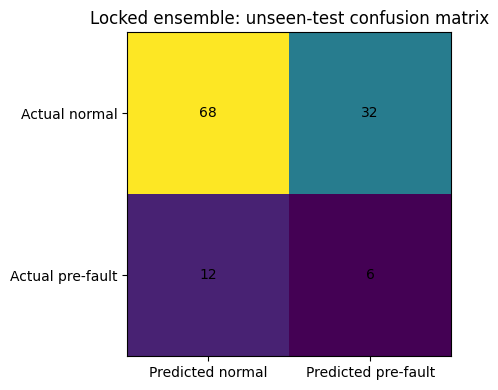


=== FINAL UNSEEN-TEST METRICS ===
               candidate  threshold    alert_rule  accuracy  balanced_accuracy  macro_f1  precision  recall  pr_auc  roc_auc  tn  fp  fn  tp
EXP08_five_seed_ensemble       0.51 single_window    0.6271             0.5067    0.4849     0.1579  0.3333  0.3434   0.5467  68  32  12   6

=== FINAL CONFUSION MATRIX ===
                  Predicted normal  Predicted pre-fault
Actual normal                   68                   32
Actual pre-fault                12                    6

=== CLASSIFICATION REPORT ===
              precision  recall  f1-score   support
normal           0.8500  0.6800    0.7556  100.0000
pre-fault        0.1579  0.3333    0.2143   18.0000
accuracy         0.6271  0.6271    0.6271    0.6271
macro avg        0.5039  0.5067    0.4849  118.0000
weighted avg     0.7444  0.6271    0.6730  118.0000

=== FINAL OPERATIONAL METRICS ===
 detected_fault_events  total_fault_events  event_recall  normal_false_alert_windows  normal_events_alert

In [ ]:
# Phase 12: Final locked five-seed ensemble test evaluation

from pathlib import Path
import json
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


# =========================================================
# 1. Locked configuration — do not modify after test access
# =========================================================

FINAL_CANDIDATE = "EXP08_five_seed_ensemble"
FEATURE_SET_NAME = "compact_uncorrelated"

HIDDEN_UNITS = (64, 32, 16)
DROPOUT = 0.30
L2_STRENGTH = 1e-4
LEARNING_RATE = 5e-4
BATCH_SIZE = 32

SEEDS = [107, 207, 307, 407, 507]

FINAL_THRESHOLD = 0.51
FINAL_ALERT_RULE = "single_window"

EXPECTED_TEST_GROUPS = {
    1, 13, 14, 21, 23, 24
}


# =========================================================
# 2. Paths
# =========================================================

FEATURE_PATH = Path(
    "/content/thermoguard_de/processed/"
    "thermoguard_features_24h.csv"
)

FEATURE_SETS_PATH = Path(
    "/content/thermoguard_de/processed/"
    "thermoguard_feature_sets.json"
)

VALIDATION_REFERENCE_PATH = Path(
    "/content/thermoguard_de/results/"
    "phase11_ensemble_validation_predictions.csv"
)

RESULTS_DIR = Path(
    "/content/thermoguard_de/results"
)

MODELS_DIR = Path(
    "/content/thermoguard_de/models/final_ensemble"
)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)


# =========================================================
# 3. Load locked data
# =========================================================

feature_table = pd.read_csv(
    FEATURE_PATH,
    parse_dates=[
        "window_start",
        "window_end",
        "Report date",
        "Possible anomaly start",
    ]
)

with open(
    FEATURE_SETS_PATH,
    "r",
    encoding="utf-8"
) as file:
    feature_sets = json.load(file)

feature_columns = feature_sets[
    FEATURE_SET_NAME
]

if len(feature_columns) != 49:
    raise ValueError(
        f"Locked feature count changed: {len(feature_columns)}"
    )


train_data = feature_table[
    feature_table["split"] == "train"
].copy()

validation_data = feature_table[
    feature_table["split"] == "validation"
].copy()

test_data = feature_table[
    feature_table["split"] == "test"
].copy()


test_groups = set(
    test_data["substation ID"]
    .astype(int)
    .unique()
)

if test_groups != EXPECTED_TEST_GROUPS:
    raise ValueError(
        f"Locked test groups changed: {test_groups}"
    )

if len(train_data) != 391:
    raise ValueError("Training row count changed.")

if len(validation_data) != 114:
    raise ValueError("Validation row count changed.")

if len(test_data) != 118:
    raise ValueError("Test row count changed.")


print("=== FINAL LOCK CHECK ===")
print("Candidate:", FINAL_CANDIDATE)
print("Features:", len(feature_columns))
print("Hidden units:", HIDDEN_UNITS)
print("Dropout:", DROPOUT)
print("L2:", L2_STRENGTH)
print("Learning rate:", LEARNING_RATE)
print("Seeds:", SEEDS)
print("Alert rule:", FINAL_ALERT_RULE)
print("Threshold:", FINAL_THRESHOLD)
print("Test groups:", sorted(test_groups))


# =========================================================
# 4. Fit preprocessing on training only
# =========================================================

X_train_frame = train_data[
    feature_columns
].apply(pd.to_numeric, errors="coerce")

X_validation_frame = validation_data[
    feature_columns
].apply(pd.to_numeric, errors="coerce")

X_test_frame = test_data[
    feature_columns
].apply(pd.to_numeric, errors="coerce")


preprocessor = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
])

X_train = preprocessor.fit_transform(
    X_train_frame
)

X_validation = preprocessor.transform(
    X_validation_frame
)

X_test = preprocessor.transform(
    X_test_frame
)


if not np.isfinite(X_train).all():
    raise ValueError("Invalid training matrix.")

if not np.isfinite(X_validation).all():
    raise ValueError("Invalid validation matrix.")

if not np.isfinite(X_test).all():
    raise ValueError("Invalid test matrix.")


joblib.dump(
    preprocessor,
    MODELS_DIR / "final_preprocessor.joblib"
)


y_train = train_data["label"].astype(int).to_numpy()
y_validation = (
    validation_data["label"].astype(int).to_numpy()
)


# =========================================================
# 5. Recreate locked event-class sample weights
# =========================================================

def create_event_class_weights(data):

    event_sizes = (
        data.groupby("event_uid")
        .size()
        .to_dict()
    )

    weights = (
        data["event_uid"]
        .map(
            lambda event_uid:
            1.0 / event_sizes[event_uid]
        )
        .astype(float)
    )

    class_totals = (
        pd.DataFrame({
            "label": data["label"].to_numpy(),
            "weight": weights.to_numpy(),
        })
        .groupby("label")["weight"]
        .sum()
        .to_dict()
    )

    class_scaling = {
        label: 1.0 / total
        for label, total
        in class_totals.items()
    }

    weights = (
        weights
        * data["label"].map(class_scaling)
    )

    return (
        weights / weights.mean()
    ).to_numpy(dtype=float)


sample_weights = create_event_class_weights(
    train_data
)


# =========================================================
# 6. Locked model builder
# =========================================================

def build_final_model(seed):

    regularizer = tf.keras.regularizers.l2(
        L2_STRENGTH
    )

    inputs = tf.keras.Input(
        shape=(len(feature_columns),),
        name="engineered_features"
    )

    x = inputs

    for layer_number, units in enumerate(
        HIDDEN_UNITS,
        start=1
    ):
        x = tf.keras.layers.Dense(
            units,
            activation="relu",
            kernel_initializer="he_normal",
            kernel_regularizer=regularizer,
            name=f"dense_{layer_number}_{units}",
        )(x)

        x = tf.keras.layers.Dropout(
            DROPOUT,
            seed=seed,
            name=f"dropout_{layer_number}",
        )(x)

    outputs = tf.keras.layers.Dense(
        1,
        activation="sigmoid",
        name="prefault_score"
    )(x)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(
                curve="PR",
                name="pr_auc"
            ),
            tf.keras.metrics.AUC(
                curve="ROC",
                name="roc_auc"
            ),
        ]
    )

    return model


# =========================================================
# 7. Retrain locked five seeds
# =========================================================

validation_seed_probabilities = []
test_seed_probabilities = []
training_records = []

inference_start = time.perf_counter()


for seed in SEEDS:

    print(f"Training locked model with seed {seed}")

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    model = build_final_model(seed)

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_pr_auc",
            mode="max",
            patience=25,
            min_delta=1e-4,
            restore_best_weights=True,
            verbose=0,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_pr_auc",
            mode="max",
            factor=0.5,
            patience=10,
            min_lr=1e-5,
            verbose=0,
        ),
    ]

    training_start = time.perf_counter()

    history = model.fit(
        X_train,
        y_train,
        sample_weight=sample_weights,
        validation_data=(
            X_validation,
            y_validation
        ),
        epochs=250,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        shuffle=True,
        verbose=0,
    )

    training_seconds = (
        time.perf_counter()
        - training_start
    )

    validation_probabilities = (
        model(
            X_validation,
            training=False
        )
        .numpy()
        .reshape(-1)
    )

    test_probabilities = (
        model(
            X_test,
            training=False
        )
        .numpy()
        .reshape(-1)
    )

    validation_seed_probabilities.append(
        validation_probabilities
    )

    test_seed_probabilities.append(
        test_probabilities
    )

    best_epoch = int(
        np.argmax(
            history.history["val_pr_auc"]
        ) + 1
    )

    model_path = (
        MODELS_DIR
        / f"final_seed_{seed}.keras"
    )

    model.save(model_path)

    training_records.append({
        "seed": seed,
        "best_epoch": best_epoch,
        "epochs_completed": len(
            history.history["loss"]
        ),
        "training_seconds": training_seconds,
        "trainable_parameters": int(
            model.count_params()
        ),
        "model_path": str(model_path),
    })


validation_seed_probabilities = np.vstack(
    validation_seed_probabilities
).T

test_seed_probabilities = np.vstack(
    test_seed_probabilities
).T


validation_ensemble_probability = (
    validation_seed_probabilities.mean(axis=1)
)

test_ensemble_probability = (
    test_seed_probabilities.mean(axis=1)
)

test_seed_std = (
    test_seed_probabilities.std(
        axis=1,
        ddof=0
    )
)


# =========================================================
# 8. Reproducibility check before examining test labels
# =========================================================

validation_reference = pd.read_csv(
    VALIDATION_REFERENCE_PATH
)

reference_probabilities = (
    validation_reference[
        "EXP08_ensemble_probability"
    ].to_numpy(dtype=float)
)

maximum_validation_difference = float(
    np.max(
        np.abs(
            validation_ensemble_probability
            - reference_probabilities
        )
    )
)

print("\n=== VALIDATION REPRODUCIBILITY ===")
print(
    "Maximum absolute ensemble difference:",
    maximum_validation_difference
)

if maximum_validation_difference > 1e-4:
    raise ValueError(
        "Locked ensemble was not reproduced closely enough. "
        "Do not interpret test results."
    )


# =========================================================
# 9. Final one-time test evaluation
# =========================================================

y_test = test_data[
    "label"
].astype(int).to_numpy()

test_predictions = (
    test_ensemble_probability
    >= FINAL_THRESHOLD
).astype(int)


tn, fp, fn, tp = confusion_matrix(
    y_test,
    test_predictions,
    labels=[0, 1]
).ravel()


test_metrics = {
    "candidate": FINAL_CANDIDATE,
    "threshold": FINAL_THRESHOLD,
    "alert_rule": FINAL_ALERT_RULE,
    "accuracy": float(
        accuracy_score(
            y_test,
            test_predictions
        )
    ),
    "balanced_accuracy": float(
        balanced_accuracy_score(
            y_test,
            test_predictions
        )
    ),
    "macro_f1": float(
        f1_score(
            y_test,
            test_predictions,
            average="macro",
            zero_division=0
        )
    ),
    "precision": float(
        precision_score(
            y_test,
            test_predictions,
            zero_division=0
        )
    ),
    "recall": float(
        recall_score(
            y_test,
            test_predictions,
            zero_division=0
        )
    ),
    "pr_auc": float(
        average_precision_score(
            y_test,
            test_ensemble_probability
        )
    ),
    "roc_auc": float(
        roc_auc_score(
            y_test,
            test_ensemble_probability
        )
    ),
    "tn": int(tn),
    "fp": int(fp),
    "fn": int(fn),
    "tp": int(tp),
}


# =========================================================
# 10. Test event-level analysis
# =========================================================

test_results = test_data[
    [
        "substation ID",
        "event_id",
        "event_uid",
        "event_type",
        "problem_category",
        "window_end",
        "hours_to_report",
        "label",
    ]
].copy().reset_index(drop=True)

test_results[
    "ensemble_probability"
] = test_ensemble_probability

test_results[
    "seed_std"
] = test_seed_std

test_results["prediction"] = (
    test_predictions
)

test_results["alert"] = (
    test_predictions.astype(bool)
)


positive_test = test_results[
    test_results["label"] == 1
].copy()

normal_test = test_results[
    test_results["label"] == 0
].copy()


fault_event_records = []

for (
    substation_id,
    event_id,
    problem_category
), group in positive_test.groupby(
    [
        "substation ID",
        "event_id",
        "problem_category",
    ]
):

    alerted = group[group["alert"]]

    fault_event_records.append({
        "substation ID": int(substation_id),
        "event_id": int(event_id),
        "problem_category": problem_category,
        "positive_windows": len(group),
        "maximum_probability": float(
            group["ensemble_probability"].max()
        ),
        "mean_probability": float(
            group["ensemble_probability"].mean()
        ),
        "detected": not alerted.empty,
        "alerted_positive_windows": int(
            group["alert"].sum()
        ),
        "earliest_warning_hours": (
            float(
                alerted[
                    "hours_to_report"
                ].max()
            )
            if not alerted.empty
            else np.nan
        ),
    })


fault_event_table = pd.DataFrame(
    fault_event_records
)


normal_event_table = (
    normal_test
    .groupby(
        [
            "substation ID",
            "event_id",
        ]
    )
    .agg(
        normal_windows=("label", "size"),
        false_alert_windows=("alert", "sum"),
        maximum_probability=(
            "ensemble_probability",
            "max"
        ),
        mean_probability=(
            "ensemble_probability",
            "mean"
        ),
    )
    .reset_index()
)

normal_event_table["event_alerted"] = (
    normal_event_table[
        "false_alert_windows"
    ] > 0
)


detected_fault_events = int(
    fault_event_table["detected"].sum()
)

total_fault_events = len(
    fault_event_table
)

event_recall = (
    detected_fault_events
    / total_fault_events
)

warning_values = (
    fault_event_table.loc[
        fault_event_table["detected"],
        "earliest_warning_hours",
    ]
    .dropna()
)


operational_metrics = {
    "detected_fault_events": (
        detected_fault_events
    ),
    "total_fault_events": (
        total_fault_events
    ),
    "event_recall": float(
        event_recall
    ),
    "normal_false_alert_windows": int(
        normal_test["alert"].sum()
    ),
    "normal_events_alerted": int(
        normal_event_table[
            "event_alerted"
        ].sum()
    ),
    "total_normal_events": len(
        normal_event_table
    ),
    "median_warning_hours": (
        float(warning_values.median())
        if not warning_values.empty
        else np.nan
    ),
    "maximum_warning_hours": (
        float(warning_values.max())
        if not warning_values.empty
        else np.nan
    ),
}


# =========================================================
# 11. Substation-level error summary
# =========================================================

substation_summary = (
    test_results
    .groupby(
        [
            "substation ID",
            "label",
        ]
    )
    .agg(
        windows=("label", "size"),
        alerts=("alert", "sum"),
        mean_probability=(
            "ensemble_probability",
            "mean"
        ),
        maximum_probability=(
            "ensemble_probability",
            "max"
        ),
        mean_seed_std=(
            "seed_std",
            "mean"
        ),
    )
    .reset_index()
)

substation_summary["class"] = (
    substation_summary["label"]
    .map({
        0: "normal",
        1: "pre-fault",
    })
)


# =========================================================
# 12. Efficiency and model-size summary
# =========================================================

prediction_timing_start = (
    time.perf_counter()
)

for probabilities in test_seed_probabilities.T:
    _ = probabilities >= FINAL_THRESHOLD

postprocess_seconds = (
    time.perf_counter()
    - prediction_timing_start
)

model_files = list(
    MODELS_DIR.glob("final_seed_*.keras")
)

total_model_size_bytes = sum(
    path.stat().st_size
    for path in model_files
)

parameter_count_per_model = int(
    training_records[0][
        "trainable_parameters"
    ]
)

efficiency_summary = {
    "models_in_ensemble": len(SEEDS),
    "parameters_per_model": (
        parameter_count_per_model
    ),
    "total_ensemble_parameters": (
        parameter_count_per_model
        * len(SEEDS)
    ),
    "total_model_file_size_mib": (
        total_model_size_bytes
        / (1024 ** 2)
    ),
    "test_windows": len(test_data),
    "postprocessing_seconds": (
        postprocess_seconds
    ),
}


# =========================================================
# 13. Confusion-matrix figure
# =========================================================

matrix = np.array([
    [tn, fp],
    [fn, tp],
])

plt.figure(figsize=(5, 4))
plt.imshow(matrix)

plt.xticks(
    [0, 1],
    ["Predicted normal", "Predicted pre-fault"]
)

plt.yticks(
    [0, 1],
    ["Actual normal", "Actual pre-fault"]
)

for row in range(2):
    for column in range(2):
        plt.text(
            column,
            row,
            str(matrix[row, column]),
            ha="center",
            va="center",
        )

plt.title(
    "Locked ensemble: unseen-test confusion matrix"
)

plt.tight_layout()

CONFUSION_PLOT_PATH = (
    RESULTS_DIR
    / "final_test_confusion_matrix.png"
)

plt.savefig(
    CONFUSION_PLOT_PATH,
    dpi=160,
    bbox_inches="tight"
)

plt.show()


# =========================================================
# 14. Save final artefacts
# =========================================================

FINAL_METRICS_PATH = (
    RESULTS_DIR
    / "final_test_metrics.csv"
)

OPERATIONAL_METRICS_PATH = (
    RESULTS_DIR
    / "final_operational_metrics.csv"
)

TEST_PREDICTIONS_PATH = (
    RESULTS_DIR
    / "final_test_predictions.csv"
)

FAULT_EVENTS_PATH = (
    RESULTS_DIR
    / "final_test_fault_events.csv"
)

NORMAL_EVENTS_PATH = (
    RESULTS_DIR
    / "final_test_normal_events.csv"
)

SUBSTATION_PATH = (
    RESULTS_DIR
    / "final_test_substation_summary.csv"
)

TRAINING_PATH = (
    RESULTS_DIR
    / "final_ensemble_training_summary.csv"
)

EFFICIENCY_PATH = (
    RESULTS_DIR
    / "final_efficiency_summary.csv"
)

CLASSIFICATION_REPORT_PATH = (
    RESULTS_DIR
    / "final_classification_report.csv"
)


pd.DataFrame(
    [test_metrics]
).to_csv(
    FINAL_METRICS_PATH,
    index=False
)

pd.DataFrame(
    [operational_metrics]
).to_csv(
    OPERATIONAL_METRICS_PATH,
    index=False
)

test_results.to_csv(
    TEST_PREDICTIONS_PATH,
    index=False
)

fault_event_table.to_csv(
    FAULT_EVENTS_PATH,
    index=False
)

normal_event_table.to_csv(
    NORMAL_EVENTS_PATH,
    index=False
)

substation_summary.to_csv(
    SUBSTATION_PATH,
    index=False
)

pd.DataFrame(
    training_records
).to_csv(
    TRAINING_PATH,
    index=False
)

pd.DataFrame(
    [efficiency_summary]
).to_csv(
    EFFICIENCY_PATH,
    index=False
)


classification_report_frame = (
    pd.DataFrame(
        classification_report(
            y_test,
            test_predictions,
            target_names=[
                "normal",
                "pre-fault",
            ],
            output_dict=True,
            zero_division=0,
        )
    )
    .transpose()
)

classification_report_frame.to_csv(
    CLASSIFICATION_REPORT_PATH
)


# =========================================================
# 15. Display final results
# =========================================================

print("\n=== FINAL UNSEEN-TEST METRICS ===")
print(
    pd.DataFrame(
        [test_metrics]
    )
    .round(4)
    .to_string(index=False)
)


print("\n=== FINAL CONFUSION MATRIX ===")
print(
    pd.DataFrame(
        matrix,
        index=[
            "Actual normal",
            "Actual pre-fault",
        ],
        columns=[
            "Predicted normal",
            "Predicted pre-fault",
        ]
    ).to_string()
)


print("\n=== CLASSIFICATION REPORT ===")
print(
    classification_report_frame
    .round(4)
    .to_string()
)


print("\n=== FINAL OPERATIONAL METRICS ===")
print(
    pd.DataFrame(
        [operational_metrics]
    )
    .round(4)
    .to_string(index=False)
)


print("\n=== TEST FAULT-EVENT DETAILS ===")
print(
    fault_event_table
    .round(4)
    .to_string(index=False)
)


print("\n=== TEST NORMAL-EVENT DETAILS ===")
print(
    normal_event_table
    .round(4)
    .to_string(index=False)
)


print("\n=== TEST SUBSTATION SUMMARY ===")
print(
    substation_summary[
        [
            "substation ID",
            "class",
            "windows",
            "alerts",
            "mean_probability",
            "maximum_probability",
            "mean_seed_std",
        ]
    ]
    .sort_values(
        ["class", "substation ID"]
    )
    .round(4)
    .to_string(index=False)
)


print("\n=== FINAL MODEL EFFICIENCY ===")
print(
    pd.DataFrame(
        [efficiency_summary]
    )
    .round(4)
    .to_string(index=False)
)


print("\n=== FINAL TEST LOCK STATEMENT ===")
print(
    "The architecture, feature set, five seeds, "
    "sample weighting, alert rule and threshold were "
    "selected using training and validation data before "
    "the unseen test labels were evaluated."
)

print(
    "No post-test threshold tuning or model modification "
    "is permitted."
)


print("\n=== SAVED FINAL FILES ===")
print(FINAL_METRICS_PATH)
print(OPERATIONAL_METRICS_PATH)
print(TEST_PREDICTIONS_PATH)
print(FAULT_EVENTS_PATH)
print(NORMAL_EVENTS_PATH)
print(SUBSTATION_PATH)
print(TRAINING_PATH)
print(EFFICIENCY_PATH)
print(CLASSIFICATION_REPORT_PATH)
print(CONFUSION_PLOT_PATH)


print(
    "\nPHASE 12 FINAL UNSEEN-TEST "
    "EVALUATION COMPLETE"
)

## Section 12 — Explainability and error analysis

Two complementary attribution methods are applied. Permutation importance (Breiman, 2001) measures the validation PR-AUC drop when each feature is shuffled, giving global importance from a validation baseline of PR-AUC 0.376. Integrated Gradients (Sundararajan *et al.*, 2017) attributes individual predictions by integrating gradients over 128 steps from a zero baseline in standardised feature space, averaged across the five networks (maximum completeness residual 0.0009, confirming faithful attribution). These explanations describe the model's decision process, not physical causality, and the output remains an uncalibrated pre-fault score rather than a true failure probability.


Permutation features completed: 10/49
Permutation features completed: 20/49
Permutation features completed: 30/49
Permutation features completed: 40/49
Permutation features completed: 49/49


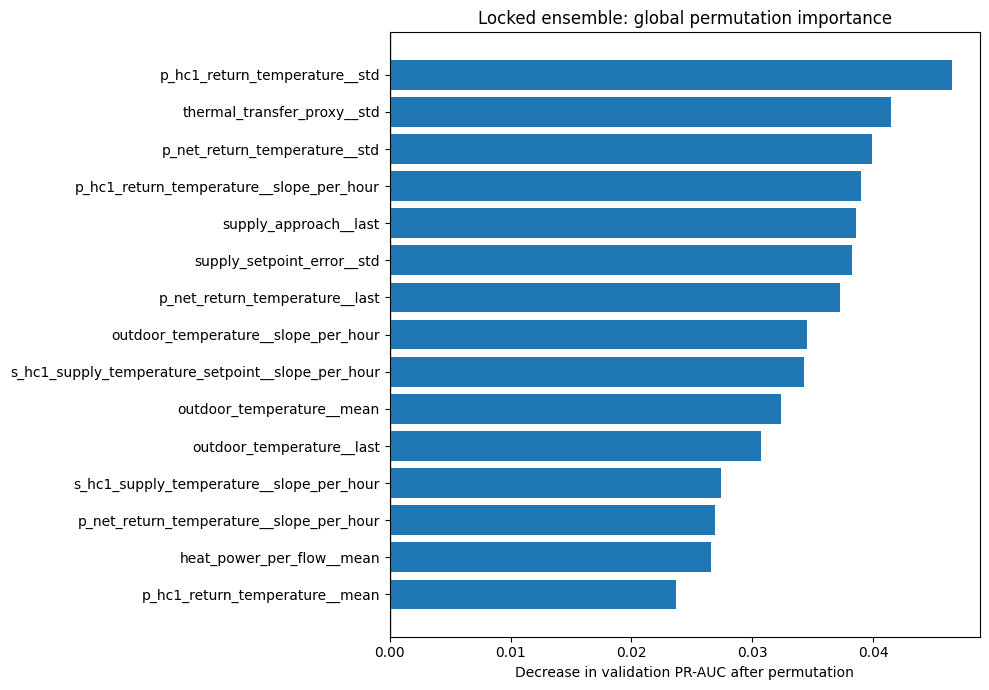

=== LOCKED MODEL STATUS ===
Feature set: compact_uncorrelated
Features: 49
Models loaded: 5
Validation reproduction difference: 6.871072388836552e-08
Model or threshold modified: False

=== VALIDATION PERMUTATION BASELINE ===
Baseline validation PR-AUC: 0.3762
Baseline validation ROC-AUC: 0.6532

=== TOP VALIDATION PERMUTATION IMPORTANCE ===
                                                feature           family  pr_auc_drop_mean  pr_auc_drop_std  roc_auc_drop_mean
                    stat__p_hc1_return_temperature__std      Statistical            0.0465           0.0128             0.0675
                      phys__thermal_transfer_proxy__std Physics-informed            0.0415           0.0122             0.0128
                    stat__p_net_return_temperature__std      Statistical            0.0399           0.0156             0.0324
         stat__p_hc1_return_temperature__slope_per_hour      Statistical            0.0390           0.0177             0.0315
                     

In [ ]:
# Phase 13A: Locked-model error analysis and global permutation importance

from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
)


# =========================================================
# 1. Paths
# =========================================================

FEATURE_PATH = Path(
    "/content/thermoguard_de/processed/"
    "thermoguard_features_24h.csv"
)

FEATURE_SETS_PATH = Path(
    "/content/thermoguard_de/processed/"
    "thermoguard_feature_sets.json"
)

TEST_RESULTS_PATH = Path(
    "/content/thermoguard_de/results/"
    "final_test_predictions.csv"
)

PHASE11_VALIDATION_PATH = Path(
    "/content/thermoguard_de/results/"
    "phase11_ensemble_validation_predictions.csv"
)

MODEL_DIR = Path(
    "/content/thermoguard_de/models/"
    "final_ensemble"
)

RESULTS_DIR = Path(
    "/content/thermoguard_de/results"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# =========================================================
# 2. Load locked data and artefacts
# =========================================================

feature_table = pd.read_csv(
    FEATURE_PATH,
    parse_dates=[
        "window_start",
        "window_end",
        "Report date",
        "Possible anomaly start",
    ]
)

test_results = pd.read_csv(
    TEST_RESULTS_PATH,
    parse_dates=["window_end"]
)

validation_reference = pd.read_csv(
    PHASE11_VALIDATION_PATH,
    parse_dates=["window_end"]
)

with open(
    FEATURE_SETS_PATH,
    "r",
    encoding="utf-8"
) as file:
    feature_sets = json.load(file)

FEATURE_SET_NAME = "compact_uncorrelated"
feature_columns = feature_sets[
    FEATURE_SET_NAME
]

if len(feature_columns) != 49:
    raise ValueError(
        f"Locked feature count changed: {len(feature_columns)}"
    )


train_data = feature_table[
    feature_table["split"] == "train"
].copy()

validation_data = feature_table[
    feature_table["split"] == "validation"
].copy()

test_data = feature_table[
    feature_table["split"] == "test"
].copy()


if len(train_data) != 391:
    raise ValueError("Training rows changed.")

if len(validation_data) != 114:
    raise ValueError("Validation rows changed.")

if len(test_data) != 118:
    raise ValueError("Test rows changed.")


preprocessor = joblib.load(
    MODEL_DIR
    / "final_preprocessor.joblib"
)

SEEDS = [107, 207, 307, 407, 507]

models = [
    tf.keras.models.load_model(
        MODEL_DIR
        / f"final_seed_{seed}.keras"
    )
    for seed in SEEDS
]


# =========================================================
# 3. Prediction helper
# =========================================================

def ensemble_predict(raw_frame):
    numeric_frame = raw_frame[
        feature_columns
    ].apply(
        pd.to_numeric,
        errors="coerce"
    )

    processed = preprocessor.transform(
        numeric_frame
    )

    seed_probabilities = np.column_stack([
        model(
            processed,
            training=False
        )
        .numpy()
        .reshape(-1)
        for model in models
    ])

    return (
        seed_probabilities.mean(axis=1),
        seed_probabilities.std(
            axis=1,
            ddof=0
        ),
    )


# =========================================================
# 4. Reproduce validation ensemble
# =========================================================

validation_probabilities, validation_seed_std = (
    ensemble_predict(validation_data)
)

stored_validation_probabilities = (
    validation_reference[
        "EXP08_ensemble_probability"
    ].to_numpy(dtype=float)
)

maximum_validation_difference = float(
    np.max(
        np.abs(
            validation_probabilities
            - stored_validation_probabilities
        )
    )
)

if maximum_validation_difference > 1e-4:
    raise ValueError(
        "Validation ensemble was not reproduced."
    )


y_validation = (
    validation_data["label"]
    .astype(int)
    .to_numpy()
)

baseline_pr_auc = float(
    average_precision_score(
        y_validation,
        validation_probabilities
    )
)

baseline_roc_auc = float(
    roc_auc_score(
        y_validation,
        validation_probabilities
    )
)


# =========================================================
# 5. Validation permutation importance
# =========================================================

PERMUTATION_REPEATS = 10
RANDOM_SEED = 507

rng = np.random.default_rng(
    RANDOM_SEED
)

importance_records = []


for feature_number, feature in enumerate(
    feature_columns,
    start=1
):

    repeated_pr_auc = []
    repeated_roc_auc = []

    for repeat in range(
        PERMUTATION_REPEATS
    ):
        permuted = validation_data.copy()

        permuted[feature] = rng.permutation(
            permuted[feature].to_numpy()
        )

        probabilities, _ = ensemble_predict(
            permuted
        )

        repeated_pr_auc.append(
            average_precision_score(
                y_validation,
                probabilities
            )
        )

        repeated_roc_auc.append(
            roc_auc_score(
                y_validation,
                probabilities
            )
        )

    if feature.startswith("phys__"):
        family = "Physics-informed"
    elif feature.startswith("stat__"):
        family = "Statistical"
    elif feature.startswith("meter__"):
        family = "Meter-derived"
    else:
        family = "Other"

    importance_records.append({
        "feature": feature,
        "family": family,
        "baseline_pr_auc": baseline_pr_auc,
        "permuted_pr_auc_mean": float(
            np.mean(repeated_pr_auc)
        ),
        "pr_auc_drop_mean": float(
            baseline_pr_auc
            - np.mean(repeated_pr_auc)
        ),
        "pr_auc_drop_std": float(
            np.std(
                [
                    baseline_pr_auc - value
                    for value
                    in repeated_pr_auc
                ],
                ddof=0
            )
        ),
        "baseline_roc_auc": baseline_roc_auc,
        "permuted_roc_auc_mean": float(
            np.mean(repeated_roc_auc)
        ),
        "roc_auc_drop_mean": float(
            baseline_roc_auc
            - np.mean(repeated_roc_auc)
        ),
    })

    if (
        feature_number % 10 == 0
        or feature_number == len(feature_columns)
    ):
        print(
            "Permutation features completed:",
            f"{feature_number}/{len(feature_columns)}"
        )


permutation_importance = (
    pd.DataFrame(importance_records)
    .sort_values(
        "pr_auc_drop_mean",
        ascending=False
    )
    .reset_index(drop=True)
)


family_importance = (
    permutation_importance
    .groupby("family")
    .agg(
        features=("feature", "count"),
        positive_importance_features=(
            "pr_auc_drop_mean",
            lambda values:
            int((values > 0).sum())
        ),
        total_pr_auc_drop=(
            "pr_auc_drop_mean",
            "sum"
        ),
        mean_pr_auc_drop=(
            "pr_auc_drop_mean",
            "mean"
        ),
    )
    .reset_index()
    .sort_values(
        "total_pr_auc_drop",
        ascending=False
    )
)


# =========================================================
# 6. Test prediction outcome categories
# =========================================================

test_results["label"] = (
    test_results["label"]
    .astype(int)
)

test_results["prediction"] = (
    test_results["prediction"]
    .astype(int)
)


conditions = [
    (
        (test_results["label"] == 1)
        & (test_results["prediction"] == 1)
    ),
    (
        (test_results["label"] == 1)
        & (test_results["prediction"] == 0)
    ),
    (
        (test_results["label"] == 0)
        & (test_results["prediction"] == 1)
    ),
    (
        (test_results["label"] == 0)
        & (test_results["prediction"] == 0)
    ),
]

outcomes = [
    "True positive",
    "False negative",
    "False positive",
    "True negative",
]

test_results["outcome"] = np.select(
    conditions,
    outcomes,
    default="Unknown"
)


outcome_summary = (
    test_results
    .groupby("outcome")
    .agg(
        windows=("outcome", "size"),
        substations=(
            "substation ID",
            "nunique"
        ),
        events=("event_uid", "nunique"),
        mean_probability=(
            "ensemble_probability",
            "mean"
        ),
        median_probability=(
            "ensemble_probability",
            "median"
        ),
        mean_seed_std=(
            "seed_std",
            "mean"
        ),
        maximum_seed_std=(
            "seed_std",
            "max"
        ),
    )
    .reset_index()
)


# =========================================================
# 7. Test substation error profiles
# =========================================================

substation_error_profile = (
    test_results
    .groupby(
        [
            "substation ID",
            "label",
        ]
    )
    .agg(
        windows=("label", "size"),
        predicted_prefault=(
            "prediction",
            "sum"
        ),
        mean_probability=(
            "ensemble_probability",
            "mean"
        ),
        maximum_probability=(
            "ensemble_probability",
            "max"
        ),
        minimum_probability=(
            "ensemble_probability",
            "min"
        ),
        mean_seed_std=(
            "seed_std",
            "mean"
        ),
    )
    .reset_index()
)

substation_error_profile["class"] = (
    substation_error_profile["label"]
    .map({
        0: "Normal",
        1: "Pre-fault",
    })
)

substation_error_profile[
    "alert_fraction"
] = (
    substation_error_profile[
        "predicted_prefault"
    ]
    / substation_error_profile["windows"]
)


# =========================================================
# 8. Standardised test distribution shift
# =========================================================

X_train_scaled = preprocessor.transform(
    train_data[
        feature_columns
    ].apply(
        pd.to_numeric,
        errors="coerce"
    )
)

X_test_scaled = preprocessor.transform(
    test_data[
        feature_columns
    ].apply(
        pd.to_numeric,
        errors="coerce"
    )
)


global_shift = pd.DataFrame({
    "feature": feature_columns,
    "training_scaled_mean": (
        X_train_scaled.mean(axis=0)
    ),
    "test_scaled_mean": (
        X_test_scaled.mean(axis=0)
    ),
})

global_shift[
    "standardised_mean_shift"
] = (
    global_shift["test_scaled_mean"]
    - global_shift["training_scaled_mean"]
)

global_shift[
    "absolute_standardised_shift"
] = (
    global_shift[
        "standardised_mean_shift"
    ].abs()
)

global_shift = global_shift.sort_values(
    "absolute_standardised_shift",
    ascending=False
)


# =========================================================
# 9. Critical subgroup distribution shifts
# =========================================================

critical_groups = {
    "Normal substation 1": (
        (test_data["substation ID"] == 1)
        & (test_data["label"] == 0)
    ),
    "Missed no-heat substation 21": (
        (test_data["substation ID"] == 21)
        & (test_data["label"] == 1)
    ),
    "Detected leakage substation 24": (
        (test_data["substation ID"] == 24)
        & (test_data["label"] == 1)
    ),
}


critical_shift_records = []


for group_name, mask in critical_groups.items():

    group_data = test_data.loc[
        mask,
        feature_columns
    ].apply(
        pd.to_numeric,
        errors="coerce"
    )

    group_scaled = preprocessor.transform(
        group_data
    )

    mean_shift = (
        group_scaled.mean(axis=0)
        - X_train_scaled.mean(axis=0)
    )

    for feature, shift in zip(
        feature_columns,
        mean_shift
    ):
        critical_shift_records.append({
            "group": group_name,
            "feature": feature,
            "standardised_mean_shift": float(
                shift
            ),
            "absolute_standardised_shift": float(
                abs(shift)
            ),
        })


critical_group_shifts = pd.DataFrame(
    critical_shift_records
)


# =========================================================
# 10. Permutation-importance plot
# =========================================================

top_importance = (
    permutation_importance
    .head(15)
    .sort_values(
        "pr_auc_drop_mean"
    )
)

short_names = (
    top_importance["feature"]
    .str.replace(
        "phys__",
        "",
        regex=False
    )
    .str.replace(
        "stat__",
        "",
        regex=False
    )
    .str.replace(
        "meter__",
        "",
        regex=False
    )
)


plt.figure(figsize=(10, 7))

plt.barh(
    short_names,
    top_importance[
        "pr_auc_drop_mean"
    ]
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel(
    "Decrease in validation PR-AUC after permutation"
)

plt.title(
    "Locked ensemble: global permutation importance"
)

plt.tight_layout()

IMPORTANCE_PLOT_PATH = (
    RESULTS_DIR
    / "phase13_permutation_importance.png"
)

plt.savefig(
    IMPORTANCE_PLOT_PATH,
    dpi=160,
    bbox_inches="tight"
)

plt.show()


# =========================================================
# 11. Save Phase 13A outputs
# =========================================================

IMPORTANCE_PATH = (
    RESULTS_DIR
    / "phase13_permutation_importance.csv"
)

FAMILY_PATH = (
    RESULTS_DIR
    / "phase13_feature_family_importance.csv"
)

OUTCOME_PATH = (
    RESULTS_DIR
    / "phase13_test_outcome_summary.csv"
)

SUBSTATION_PATH = (
    RESULTS_DIR
    / "phase13_test_substation_error_profile.csv"
)

SHIFT_PATH = (
    RESULTS_DIR
    / "phase13_global_distribution_shift.csv"
)

CRITICAL_SHIFT_PATH = (
    RESULTS_DIR
    / "phase13_critical_group_shifts.csv"
)


permutation_importance.to_csv(
    IMPORTANCE_PATH,
    index=False
)

family_importance.to_csv(
    FAMILY_PATH,
    index=False
)

outcome_summary.to_csv(
    OUTCOME_PATH,
    index=False
)

substation_error_profile.to_csv(
    SUBSTATION_PATH,
    index=False
)

global_shift.to_csv(
    SHIFT_PATH,
    index=False
)

critical_group_shifts.to_csv(
    CRITICAL_SHIFT_PATH,
    index=False
)


# =========================================================
# 12. Display concise results
# =========================================================

print("=== LOCKED MODEL STATUS ===")
print("Feature set:", FEATURE_SET_NAME)
print("Features:", len(feature_columns))
print("Models loaded:", len(models))
print(
    "Validation reproduction difference:",
    maximum_validation_difference
)
print("Model or threshold modified:", False)


print("\n=== VALIDATION PERMUTATION BASELINE ===")
print(
    "Baseline validation PR-AUC:",
    round(baseline_pr_auc, 4)
)
print(
    "Baseline validation ROC-AUC:",
    round(baseline_roc_auc, 4)
)


print("\n=== TOP VALIDATION PERMUTATION IMPORTANCE ===")
print(
    permutation_importance[
        [
            "feature",
            "family",
            "pr_auc_drop_mean",
            "pr_auc_drop_std",
            "roc_auc_drop_mean",
        ]
    ]
    .head(20)
    .round(4)
    .to_string(index=False)
)


print("\n=== FEATURE-FAMILY IMPORTANCE ===")
print(
    family_importance
    .round(4)
    .to_string(index=False)
)


print("\n=== TEST OUTCOME SCORE SUMMARY ===")
print(
    outcome_summary
    .round(4)
    .to_string(index=False)
)


print("\n=== TEST SUBSTATION ERROR PROFILE ===")
print(
    substation_error_profile[
        [
            "substation ID",
            "class",
            "windows",
            "predicted_prefault",
            "alert_fraction",
            "mean_probability",
            "maximum_probability",
            "mean_seed_std",
        ]
    ]
    .sort_values(
        ["class", "substation ID"]
    )
    .round(4)
    .to_string(index=False)
)


print("\n=== LARGEST GLOBAL TEST DISTRIBUTION SHIFTS ===")
print(
    global_shift[
        [
            "feature",
            "standardised_mean_shift",
            "absolute_standardised_shift",
        ]
    ]
    .head(20)
    .round(4)
    .to_string(index=False)
)


print("\n=== CRITICAL SUBGROUP SHIFTS ===")

for group_name in critical_groups:
    print(f"\n{group_name}")

    group_rows = (
        critical_group_shifts[
            critical_group_shifts["group"]
            == group_name
        ]
        .sort_values(
            "absolute_standardised_shift",
            ascending=False
        )
        .head(12)
    )

    print(
        group_rows[
            [
                "feature",
                "standardised_mean_shift",
                "absolute_standardised_shift",
            ]
        ]
        .round(4)
        .to_string(index=False)
    )


print("\n=== SAVED PHASE 13A FILES ===")
print(IMPORTANCE_PATH)
print(FAMILY_PATH)
print(OUTCOME_PATH)
print(SUBSTATION_PATH)
print(SHIFT_PATH)
print(CRITICAL_SHIFT_PATH)
print(IMPORTANCE_PLOT_PATH)


print(
    "\nPHASE 13A POST-TEST ERROR "
    "AND GLOBAL EXPLAINABILITY COMPLETE"
)

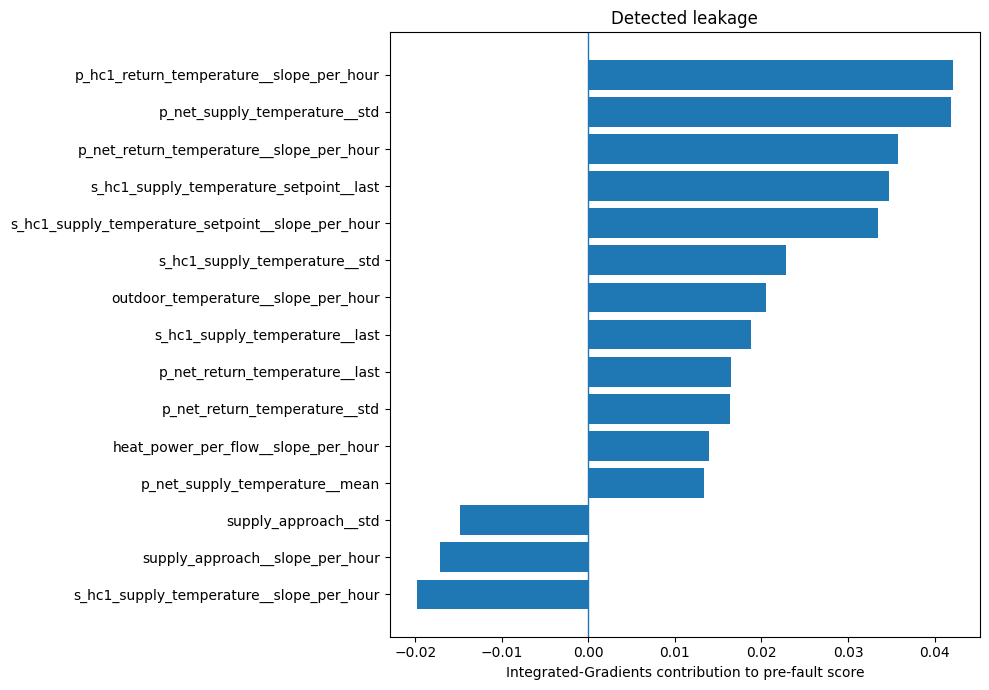

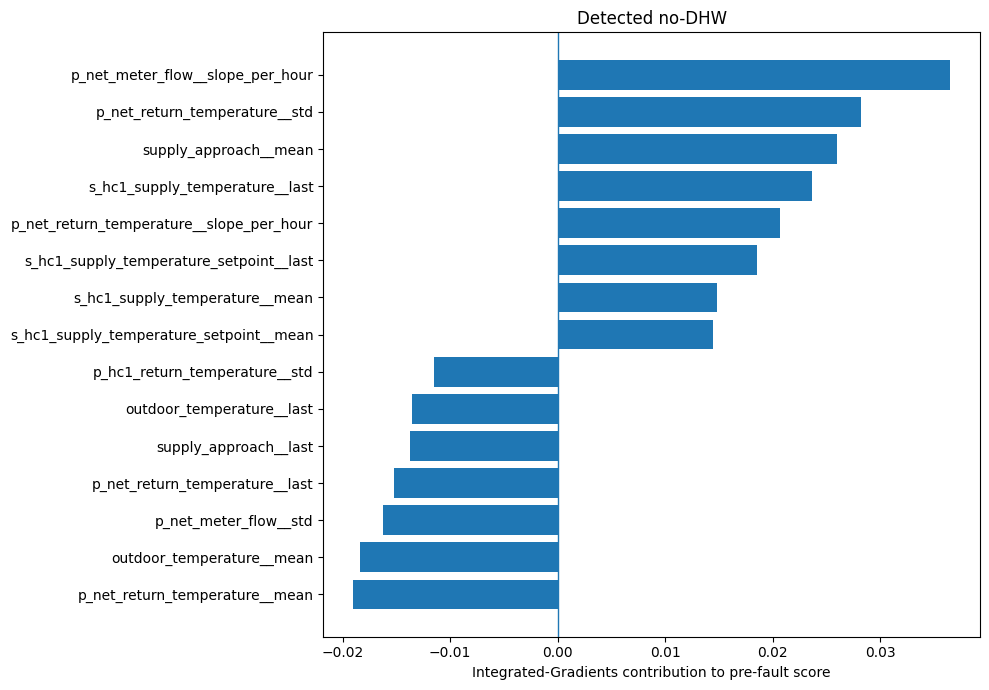

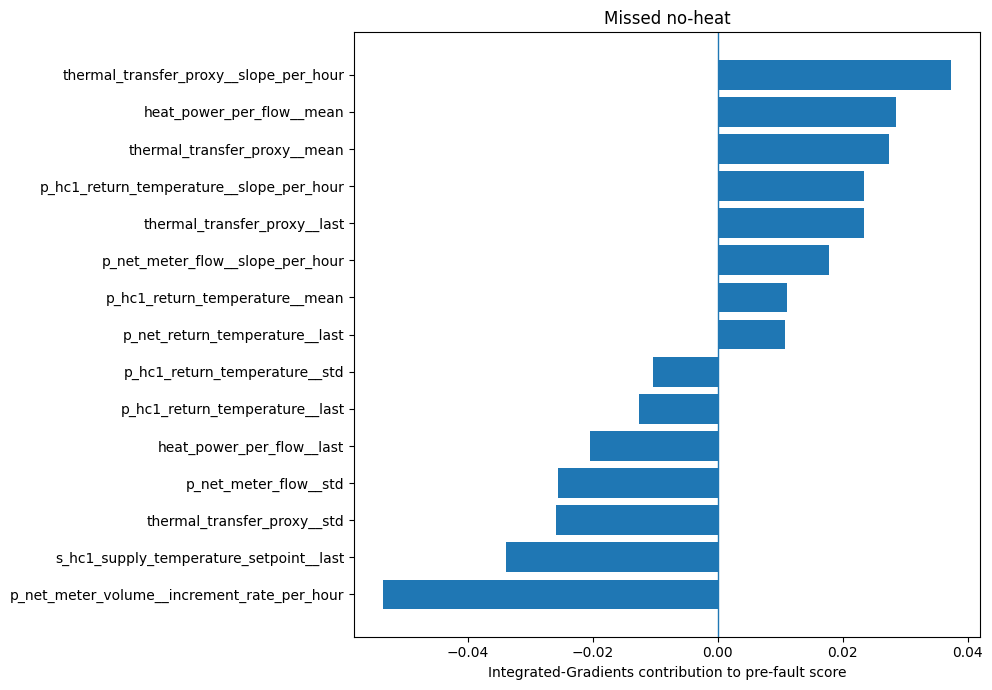

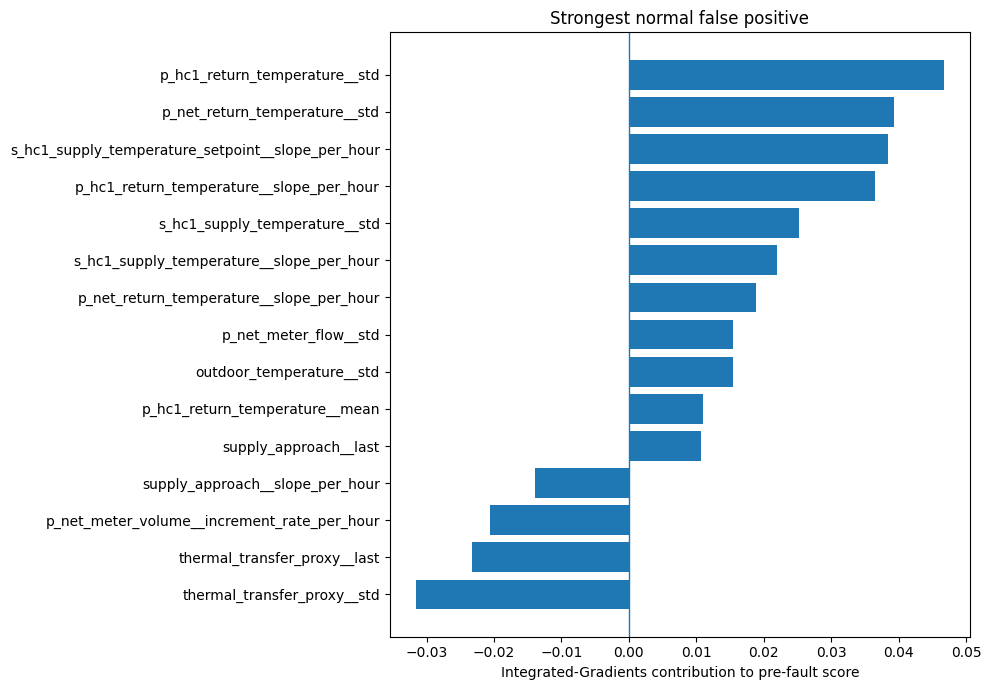

=== LOCKED LOCAL-EXPLANATION STATUS ===
Feature set: compact_uncorrelated
Models explained: 5
Integration steps: 128
Baseline: zero in standardised feature space
Model or threshold modified: False

=== SELECTED LOCAL CASES ===
                      case_name  substation ID  event_id problem_category          window_end  hours_to_report  label  prediction  ensemble_probability  seed_std
               Detected leakage             24        40          leakage 2016-04-06 19:00:00          12.7833      1           1                0.8130    0.2559
                Detected no-DHW             13        53           no DHW 2020-05-26 03:00:00           7.0000      1           1                0.5132    0.0197
                 Missed no-heat             21        52          no heat 2016-12-12 08:00:00           7.9167      1           0                0.4720    0.1177
Strongest normal false positive             14        61           normal 2019-12-10 00:00:00              NaN      0        

In [ ]:
# Phase 13B: Local Integrated-Gradients explanations

from pathlib import Path
import json
import re

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf


# =========================================================
# 1. Paths and locked configuration
# =========================================================

FEATURE_PATH = Path(
    "/content/thermoguard_de/processed/"
    "thermoguard_features_24h.csv"
)

FEATURE_SETS_PATH = Path(
    "/content/thermoguard_de/processed/"
    "thermoguard_feature_sets.json"
)

TEST_RESULTS_PATH = Path(
    "/content/thermoguard_de/results/"
    "final_test_predictions.csv"
)

MODEL_DIR = Path(
    "/content/thermoguard_de/models/"
    "final_ensemble"
)

RESULTS_DIR = Path(
    "/content/thermoguard_de/results"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FEATURE_SET_NAME = "compact_uncorrelated"
FINAL_THRESHOLD = 0.51
SEEDS = [107, 207, 307, 407, 507]
INTEGRATION_STEPS = 128


# =========================================================
# 2. Load data, feature set and locked models
# =========================================================

feature_table = pd.read_csv(
    FEATURE_PATH,
    parse_dates=[
        "window_start",
        "window_end",
        "Report date",
        "Possible anomaly start",
    ]
)

test_results = pd.read_csv(
    TEST_RESULTS_PATH,
    parse_dates=["window_end"]
)

with open(
    FEATURE_SETS_PATH,
    "r",
    encoding="utf-8"
) as file:
    feature_sets = json.load(file)

feature_columns = feature_sets[
    FEATURE_SET_NAME
]

if len(feature_columns) != 49:
    raise ValueError(
        f"Locked feature count changed: {len(feature_columns)}"
    )

test_features = feature_table[
    feature_table["split"] == "test"
].copy()


for frame in [test_features, test_results]:
    frame["substation ID"] = pd.to_numeric(
        frame["substation ID"],
        errors="raise"
    ).astype(int)

    frame["event_id"] = pd.to_numeric(
        frame["event_id"],
        errors="raise"
    ).astype(int)

    frame["label"] = pd.to_numeric(
        frame["label"],
        errors="raise"
    ).astype(int)


merge_keys = [
    "substation ID",
    "event_id",
    "event_type",
    "window_end",
    "label",
]

prediction_columns = [
    *merge_keys,
    "ensemble_probability",
    "seed_std",
    "prediction",
]

explanation_data = test_features.merge(
    test_results[prediction_columns],
    on=merge_keys,
    how="left",
    validate="one_to_one"
)

if len(explanation_data) != 118:
    raise ValueError(
        "Test explanation row count changed."
    )

if explanation_data[
    "ensemble_probability"
].isna().any():
    raise ValueError(
        "Test prediction merge failed."
    )


preprocessor = joblib.load(
    MODEL_DIR / "final_preprocessor.joblib"
)

models = [
    tf.keras.models.load_model(
        MODEL_DIR / f"final_seed_{seed}.keras"
    )
    for seed in SEEDS
]


# =========================================================
# 3. Select four representative cases
# =========================================================

def select_highest_probability(data, mask, case_name):
    candidates = data.loc[mask].copy()

    if candidates.empty:
        raise ValueError(
            f"No eligible rows for case: {case_name}"
        )

    selected = (
        candidates
        .sort_values(
            "ensemble_probability",
            ascending=False
        )
        .iloc[0]
    )

    return selected


selected_cases = [
    select_highest_probability(
        explanation_data,
        (
            (explanation_data["substation ID"] == 24)
            & (explanation_data["label"] == 1)
            & (explanation_data["prediction"] == 1)
        ),
        "Detected leakage",
    ),
    select_highest_probability(
        explanation_data,
        (
            (explanation_data["substation ID"] == 13)
            & (explanation_data["label"] == 1)
            & (explanation_data["prediction"] == 1)
        ),
        "Detected no-DHW",
    ),
    select_highest_probability(
        explanation_data,
        (
            (explanation_data["substation ID"] == 21)
            & (explanation_data["label"] == 1)
            & (explanation_data["prediction"] == 0)
        ),
        "Missed no-heat",
    ),
    select_highest_probability(
        explanation_data,
        (
            (explanation_data["label"] == 0)
            & (explanation_data["prediction"] == 1)
        ),
        "Strongest normal false positive",
    ),
]


case_names = [
    "Detected leakage",
    "Detected no-DHW",
    "Missed no-heat",
    "Strongest normal false positive",
]


selected_case_frame = pd.DataFrame(
    selected_cases
).reset_index(drop=True)

selected_case_frame.insert(
    0,
    "case_name",
    case_names
)


# =========================================================
# 4. Process selected feature rows
# =========================================================

selected_numeric = selected_case_frame[
    feature_columns
].apply(
    pd.to_numeric,
    errors="coerce"
)

selected_scaled = preprocessor.transform(
    selected_numeric
).astype(np.float32)

baseline = np.zeros(
    len(feature_columns),
    dtype=np.float32
)


# =========================================================
# 5. Integrated-Gradients function
# =========================================================

def integrated_gradients(
    model,
    input_vector,
    baseline_vector,
    steps=128
):
    """
    Integrated Gradients from a training-centred baseline.
    """

    input_tensor = tf.convert_to_tensor(
        input_vector.reshape(1, -1),
        dtype=tf.float32
    )

    baseline_tensor = tf.convert_to_tensor(
        baseline_vector.reshape(1, -1),
        dtype=tf.float32
    )

    alphas = tf.linspace(
        0.0,
        1.0,
        steps + 1
    )[:, tf.newaxis]

    interpolated = (
        baseline_tensor
        + alphas
        * (
            input_tensor
            - baseline_tensor
        )
    )

    with tf.GradientTape() as tape:
        tape.watch(interpolated)

        predictions = model(
            interpolated,
            training=False
        )[:, 0]

    gradients = tape.gradient(
        predictions,
        interpolated
    )

    trapezoidal_gradients = (
        gradients[:-1]
        + gradients[1:]
    ) / 2.0

    average_gradients = tf.reduce_mean(
        trapezoidal_gradients,
        axis=0
    )

    attributions = (
        input_tensor[0]
        - baseline_tensor[0]
    ) * average_gradients

    input_prediction = float(
        model(
            input_tensor,
            training=False
        )
        .numpy()
        .reshape(-1)[0]
    )

    baseline_prediction = float(
        model(
            baseline_tensor,
            training=False
        )
        .numpy()
        .reshape(-1)[0]
    )

    return (
        attributions.numpy(),
        input_prediction,
        baseline_prediction,
    )


# =========================================================
# 6. Calculate five-model local attributions
# =========================================================

attribution_records = []
completeness_records = []
family_records = []


def identify_family(feature):
    if feature.startswith("stat__"):
        return "Statistical"
    if feature.startswith("phys__"):
        return "Physics-informed"
    if feature.startswith("meter__"):
        return "Meter-derived"
    return "Other"


def shorten_feature_name(feature):
    shortened = re.sub(
        r"^(stat__|phys__|meter__)",
        "",
        feature
    )

    return shortened


for case_number, case_row in (
    selected_case_frame.iterrows()
):

    case_name = case_row["case_name"]
    input_vector = selected_scaled[
        case_number
    ]

    model_attributions = []
    input_predictions = []
    baseline_predictions = []

    for model in models:

        (
            attribution,
            input_prediction,
            baseline_prediction,
        ) = integrated_gradients(
            model,
            input_vector,
            baseline,
            steps=INTEGRATION_STEPS
        )

        model_attributions.append(
            attribution
        )

        input_predictions.append(
            input_prediction
        )

        baseline_predictions.append(
            baseline_prediction
        )

    model_attributions = np.vstack(
        model_attributions
    )

    mean_attribution = (
        model_attributions.mean(axis=0)
    )

    attribution_std = (
        model_attributions.std(
            axis=0,
            ddof=0
        )
    )

    ensemble_input_prediction = float(
        np.mean(input_predictions)
    )

    ensemble_baseline_prediction = float(
        np.mean(baseline_predictions)
    )

    predicted_difference = (
        ensemble_input_prediction
        - ensemble_baseline_prediction
    )

    attribution_sum = float(
        mean_attribution.sum()
    )

    completeness_residual = (
        attribution_sum
        - predicted_difference
    )

    completeness_records.append({
        "case_name": case_name,
        "substation ID": int(
            case_row["substation ID"]
        ),
        "event_id": int(
            case_row["event_id"]
        ),
        "problem_category": (
            case_row["problem_category"]
        ),
        "label": int(case_row["label"]),
        "prediction": int(
            case_row["prediction"]
        ),
        "stored_ensemble_probability": float(
            case_row["ensemble_probability"]
        ),
        "reproduced_ensemble_probability": (
            ensemble_input_prediction
        ),
        "baseline_probability": (
            ensemble_baseline_prediction
        ),
        "prediction_minus_baseline": (
            predicted_difference
        ),
        "integrated_gradient_sum": (
            attribution_sum
        ),
        "completeness_residual": (
            completeness_residual
        ),
        "seed_std": float(
            case_row["seed_std"]
        ),
    })

    case_feature_records = []

    for feature_number, feature in enumerate(
        feature_columns
    ):
        record = {
            "case_name": case_name,
            "substation ID": int(
                case_row["substation ID"]
            ),
            "event_id": int(
                case_row["event_id"]
            ),
            "problem_category": (
                case_row["problem_category"]
            ),
            "feature": feature,
            "short_feature": (
                shorten_feature_name(feature)
            ),
            "family": (
                identify_family(feature)
            ),
            "original_feature_value": float(
                selected_numeric.iloc[
                    case_number,
                    feature_number
                ]
            ),
            "standardised_feature_value": float(
                input_vector[
                    feature_number
                ]
            ),
            "mean_attribution": float(
                mean_attribution[
                    feature_number
                ]
            ),
            "absolute_attribution": float(
                abs(
                    mean_attribution[
                        feature_number
                    ]
                )
            ),
            "attribution_std_across_seeds": float(
                attribution_std[
                    feature_number
                ]
            ),
        }

        attribution_records.append(record)
        case_feature_records.append(record)

    case_attribution_frame = pd.DataFrame(
        case_feature_records
    )

    case_family_summary = (
        case_attribution_frame
        .groupby("family")
        .agg(
            signed_contribution=(
                "mean_attribution",
                "sum"
            ),
            total_absolute_contribution=(
                "absolute_attribution",
                "sum"
            ),
            contributing_features=(
                "feature",
                "count"
            ),
        )
        .reset_index()
    )

    case_family_summary.insert(
        0,
        "case_name",
        case_name
    )

    family_records.extend(
        case_family_summary.to_dict(
            orient="records"
        )
    )


attribution_table = pd.DataFrame(
    attribution_records
)

completeness_table = pd.DataFrame(
    completeness_records
)

family_summary = pd.DataFrame(
    family_records
)


# =========================================================
# 7. Produce local-attribution plots
# =========================================================

plot_paths = []


for case_name in case_names:

    case_rows = (
        attribution_table[
            attribution_table["case_name"]
            == case_name
        ]
        .sort_values(
            "absolute_attribution",
            ascending=False
        )
        .head(15)
        .sort_values(
            "mean_attribution"
        )
    )

    plt.figure(figsize=(10, 7))

    plt.barh(
        case_rows["short_feature"],
        case_rows["mean_attribution"]
    )

    plt.axvline(
        0,
        linewidth=1
    )

    plt.xlabel(
        "Integrated-Gradients contribution "
        "to pre-fault score"
    )

    plt.title(case_name)

    plt.tight_layout()

    safe_name = (
        case_name.lower()
        .replace("-", "_")
        .replace(" ", "_")
    )

    plot_path = (
        RESULTS_DIR
        / f"phase13_local_{safe_name}.png"
    )

    plt.savefig(
        plot_path,
        dpi=160,
        bbox_inches="tight"
    )

    plt.show()

    plot_paths.append(plot_path)


# =========================================================
# 8. Save outputs
# =========================================================

CASE_PATH = (
    RESULTS_DIR
    / "phase13_selected_local_cases.csv"
)

ATTRIBUTION_PATH = (
    RESULTS_DIR
    / "phase13_local_integrated_gradients.csv"
)

COMPLETENESS_PATH = (
    RESULTS_DIR
    / "phase13_integrated_gradients_completeness.csv"
)

FAMILY_SUMMARY_PATH = (
    RESULTS_DIR
    / "phase13_local_family_summary.csv"
)


selected_case_frame[
    [
        "case_name",
        "substation ID",
        "event_id",
        "problem_category",
        "window_end",
        "hours_to_report",
        "label",
        "prediction",
        "ensemble_probability",
        "seed_std",
    ]
].to_csv(
    CASE_PATH,
    index=False
)

attribution_table.to_csv(
    ATTRIBUTION_PATH,
    index=False
)

completeness_table.to_csv(
    COMPLETENESS_PATH,
    index=False
)

family_summary.to_csv(
    FAMILY_SUMMARY_PATH,
    index=False
)


# =========================================================
# 9. Display concise outputs
# =========================================================

print("=== LOCKED LOCAL-EXPLANATION STATUS ===")
print("Feature set:", FEATURE_SET_NAME)
print("Models explained:", len(models))
print("Integration steps:", INTEGRATION_STEPS)
print("Baseline: zero in standardised feature space")
print("Model or threshold modified:", False)


print("\n=== SELECTED LOCAL CASES ===")

print(
    selected_case_frame[
        [
            "case_name",
            "substation ID",
            "event_id",
            "problem_category",
            "window_end",
            "hours_to_report",
            "label",
            "prediction",
            "ensemble_probability",
            "seed_std",
        ]
    ]
    .round(4)
    .to_string(index=False)
)


print(
    "\n=== INTEGRATED-GRADIENTS "
    "COMPLETENESS CHECK ==="
)

print(
    completeness_table
    .round(6)
    .to_string(index=False)
)


print(
    "\n=== LOCAL FEATURE-FAMILY "
    "CONTRIBUTIONS ==="
)

print(
    family_summary
    .sort_values(
        [
            "case_name",
            "total_absolute_contribution",
        ],
        ascending=[
            True,
            False,
        ]
    )
    .round(5)
    .to_string(index=False)
)


for case_name in case_names:

    case_rows = attribution_table[
        attribution_table["case_name"]
        == case_name
    ]

    positive_features = (
        case_rows[
            case_rows["mean_attribution"] > 0
        ]
        .sort_values(
            "mean_attribution",
            ascending=False
        )
        .head(10)
    )

    negative_features = (
        case_rows[
            case_rows["mean_attribution"] < 0
        ]
        .sort_values(
            "mean_attribution"
        )
        .head(10)
    )

    print(
        f"\n=== {case_name.upper()}: "
        "FEATURES PUSHING TOWARD PRE-FAULT ==="
    )

    print(
        positive_features[
            [
                "feature",
                "family",
                "original_feature_value",
                "standardised_feature_value",
                "mean_attribution",
                "attribution_std_across_seeds",
            ]
        ]
        .round(5)
        .to_string(index=False)
    )

    print(
        f"\n=== {case_name.upper()}: "
        "FEATURES PUSHING TOWARD NORMAL ==="
    )

    print(
        negative_features[
            [
                "feature",
                "family",
                "original_feature_value",
                "standardised_feature_value",
                "mean_attribution",
                "attribution_std_across_seeds",
            ]
        ]
        .round(5)
        .to_string(index=False)
    )


print("\n=== SAVED PHASE 13B FILES ===")
print(CASE_PATH)
print(ATTRIBUTION_PATH)
print(COMPLETENESS_PATH)
print(FAMILY_SUMMARY_PATH)

for plot_path in plot_paths:
    print(plot_path)


print(
    "\nPHASE 13B LOCAL NEURAL "
    "EXPLAINABILITY COMPLETE"
)

### Findings and error analysis

Global permutation importance showed that the ensemble relied on both statistical and physics-informed information. The largest validation PR-AUC reductions came from return-temperature variability, thermal-transfer variability, setpoint-error variability and recent supply-approach measurements; statistical features contributed most in aggregate, while physics-informed variables also carried meaningful signal.

Integrated Gradients was applied to four representative unseen-test windows. The detected leakage case (score 0.81) was driven by extreme temperature variability and abnormal setpoint behaviour. The missed no-heat event scored 0.47 — just below the 0.51 threshold — with thermal-transfer evidence offset by meter-derived variables, showing how a weak signal can fall short of the operating point. The strongest normal false positive (score 0.70) reflected temperature and flow variability resembling pre-fault patterns. Because the validation set contains only three independent faults, both global and local attributions carry instability risk and are indicative rather than definitive.


## Section 13 — Critical discussion

**Strengths.** The study uses a public, service-validated real-world dataset with strict expert-anchored labels; a leakage-safe complete-substation split; training-only preprocessing; thirteen controlled experiments; multi-seed robustness-based selection; a locked one-time unseen-test evaluation; global and local explainability; and honest reporting of limitations.


**Limitations.** The study contains only 15 strict anomaly-annotated fault events, with nine for training and three each for validation and testing. Overlapping windows increase the number of modelling observations but not the number of independent failures, so performance estimates carry substantial uncertainty and correlated windows can flatter window-level metrics.

On the unseen test set the ensemble detected two of three fault events but alerted in all four normal events, with near-random balanced accuracy and low pre-fault precision (Section 11), and missed the no-heat event entirely. This points to sensitivity to asset-level distribution shift and incomplete coverage of fault mechanisms. The output is an uncalibrated risk score, not a failure probability, and permutation importance may be unstable given only three independent validation faults. The results therefore support an exploratory proof of concept, not production deployment.


## Section 14 — Responsible AI and deployment

ThermoGuard-DE is positioned as a human-in-the-loop decision-support tool: no autonomous control and no automatic fault diagnosis. Responsible deployment would require model-drift and data-quality monitoring, alert logging, a technician-feedback loop, retraining governance, probability calibration, asset-specific normalisation for distribution shift, and appropriate security and privacy controls, with uncertainty communicated transparently. The model card below consolidates this decision record.


In [ ]:
# Phase 14: Consolidate the final model card and decision record

from pathlib import Path
import json
import pandas as pd

RESULTS_DIR = Path(
    "/content/thermoguard_de/results"
)

final_metrics = pd.read_csv(
    RESULTS_DIR / "final_test_metrics.csv"
).iloc[0]

operational_metrics = pd.read_csv(
    RESULTS_DIR / "final_operational_metrics.csv"
).iloc[0]

efficiency = pd.read_csv(
    RESULTS_DIR / "final_efficiency_summary.csv"
).iloc[0]

permutation_importance = pd.read_csv(
    RESULTS_DIR / "phase13_permutation_importance.csv"
)

family_importance = pd.read_csv(
    RESULTS_DIR / "phase13_feature_family_importance.csv"
)

local_cases = pd.read_csv(
    RESULTS_DIR / "phase13_selected_local_cases.csv"
)

ig_completeness = pd.read_csv(
    RESULTS_DIR
    / "phase13_integrated_gradients_completeness.csv"
)


top_features = (
    permutation_importance
    .sort_values(
        "pr_auc_drop_mean",
        ascending=False
    )
    .head(5)["feature"]
    .tolist()
)

maximum_ig_residual = float(
    ig_completeness[
        "completeness_residual"
    ]
    .abs()
    .max()
)


model_card = pd.DataFrame([
    {
        "section": "Identity",
        "item": "Project",
        "value": "ThermoGuard-DE"
    },
    {
        "section": "Task",
        "item": "Prediction objective",
        "value": (
            "Classify a 24-hour substation window as "
            "documented normal or strict pre-fault"
        )
    },
    {
        "section": "Data",
        "item": "Scope",
        "value": (
            "PreDist Manufacturer 1; complete-substation "
            "train, validation and test separation"
        )
    },
    {
        "section": "Features",
        "item": "Input representation",
        "value": (
            "49 correlation-reduced statistical, "
            "physics-informed and meter-derived features"
        )
    },
    {
        "section": "Model",
        "item": "Architecture",
        "value": (
            "Five-seed ensemble of 64-32-16 MLPs "
            "with dropout 0.30 and L2=1e-4"
        )
    },
    {
        "section": "Model",
        "item": "Training",
        "value": (
            "Event-class sample weighting, Adam 5e-4, "
            "binary cross-entropy and early stopping"
        )
    },
    {
        "section": "Decision",
        "item": "Alert rule",
        "value": (
            "Single-window ensemble score >= 0.51"
        )
    },
    {
        "section": "Test performance",
        "item": "PR-AUC",
        "value": round(
            float(final_metrics["pr_auc"]),
            4
        )
    },
    {
        "section": "Test performance",
        "item": "Balanced accuracy",
        "value": round(
            float(
                final_metrics[
                    "balanced_accuracy"
                ]
            ),
            4
        )
    },
    {
        "section": "Test performance",
        "item": "Macro F1",
        "value": round(
            float(final_metrics["macro_f1"]),
            4
        )
    },
    {
        "section": "Test performance",
        "item": "Pre-fault recall",
        "value": round(
            float(final_metrics["recall"]),
            4
        )
    },
    {
        "section": "Operational performance",
        "item": "Independent faults detected",
        "value": (
            f"{int(operational_metrics['detected_fault_events'])}"
            f"/{int(operational_metrics['total_fault_events'])}"
        )
    },
    {
        "section": "Operational performance",
        "item": "Normal events alerted",
        "value": (
            f"{int(operational_metrics['normal_events_alerted'])}"
            f"/{int(operational_metrics['total_normal_events'])}"
        )
    },
    {
        "section": "Operational performance",
        "item": "Median warning time",
        "value": (
            f"{float(operational_metrics['median_warning_hours']):.2f} hours"
        )
    },
    {
        "section": "Explainability",
        "item": "Global method",
        "value": (
            "Validation permutation importance"
        )
    },
    {
        "section": "Explainability",
        "item": "Local method",
        "value": (
            "Five-model averaged Integrated Gradients"
        )
    },
    {
        "section": "Explainability",
        "item": "Top global features",
        "value": " | ".join(top_features)
    },
    {
        "section": "Explainability",
        "item": "Maximum IG completeness residual",
        "value": maximum_ig_residual
    },
    {
        "section": "Efficiency",
        "item": "Total ensemble parameters",
        "value": int(
            efficiency[
                "total_ensemble_parameters"
            ]
        )
    },
    {
        "section": "Efficiency",
        "item": "Saved ensemble size",
        "value": (
            f"{float(efficiency['total_model_file_size_mib']):.3f} MiB"
        )
    },
    {
        "section": "Limitations",
        "item": "Primary limitation",
        "value": (
            "Small number of independent labelled faults "
            "and strong asset-level distribution shift"
        )
    },
    {
        "section": "Deployment",
        "item": "Permitted use",
        "value": (
            "Human-reviewed maintenance prioritisation pilot"
        )
    },
    {
        "section": "Deployment",
        "item": "Prohibited use",
        "value": (
            "Autonomous diagnosis or equipment control"
        )
    },
    {
        "section": "Test lock",
        "item": "Post-test modification",
        "value": "None"
    },
])


MODEL_CARD_PATH = (
    RESULTS_DIR
    / "phase14_final_model_card.csv"
)

MODEL_CARD_JSON_PATH = (
    RESULTS_DIR
    / "phase14_final_model_card.json"
)

model_card.to_csv(
    MODEL_CARD_PATH,
    index=False
)

with open(
    MODEL_CARD_JSON_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        model_card.to_dict(
            orient="records"
        ),
        file,
        indent=2,
        ensure_ascii=False,
        default=str
    )


print("=== FINAL MODEL CARD ===")
print(
    model_card.to_string(index=False)
)

print("\n=== EXPLAINABILITY VALIDATION ===")
print(
    "Maximum absolute IG completeness residual:",
    round(maximum_ig_residual, 6)
)
print(
    "Local cases explained:",
    len(local_cases)
)
print(
    "Feature families assessed:",
    family_importance["family"].tolist()
)

print("\n=== FINAL SCIENTIFIC VERDICT ===")
print(
    "Exploratory proof of concept with partial "
    "unseen-event detection, limited class-level "
    "generalisation and substantial false-alert burden."
)

print("\n=== TEST LOCK ===")
print("Model modified after test:", False)
print("Threshold modified after test:", False)
print("Test groups changed:", False)

print("\n=== SAVED PHASE 14 FILES ===")
print(MODEL_CARD_PATH)
print(MODEL_CARD_JSON_PATH)

print(
    "\nPHASE 14 FINAL MODEL CARD COMPLETE"
)

=== FINAL MODEL CARD ===
                section                             item                                                                                                                                                                                        value
               Identity                          Project                                                                                                                                                                               ThermoGuard-DE
                   Task             Prediction objective                                                                                                                Classify a 24-hour substation window as documented normal or strict pre-fault
                   Data                            Scope                                                                                                            PreDist Manufacturer 1; complete-substation train, validation and test se

### Business and deployment recommendations

An alert should present the risk score, recent operating trends, influential features and data-quality indicators to a qualified operator, who retains responsibility for diagnosis and intervention. Before operational use, the system requires more labelled fault events, broader coverage of equipment configurations and prospective evaluation on newly collected substations. Asset-specific normal baselines or domain-adaptation methods should be investigated, because legitimate operating regimes differed substantially across substations. Calibration and cost-sensitive threshold selection should be evaluated on a future validation population rather than the locked test data. The current model may support technician prioritisation in a controlled pilot, but alerts remain investigative evidence rather than confirmed diagnoses.


## Section 15 — Conclusion

ThermoGuard-DE demonstrates a technically rigorous proof of concept: leakage-safe data preparation, controlled experimentation, multi-seed robustness testing, explainability and a disciplined one-time unseen-test evaluation. Returning to the research question, some pre-fault signal was detected — the locked ensemble caught two of three independent test faults with useful warning lead time — but generalisation to unseen substations was weak, balanced accuracy was near random, and the false-alert burden was unacceptable, with alerts in all four normal events and the no-heat fault missed. The current model is an exploratory proof of concept; it may support a controlled, human-reviewed pilot but is not ready for unsupervised production deployment.


## Section 16 — References

Breiman, L. (2001) 'Random forests', *Machine Learning*, 45(1), pp. 5–32. doi:10.1023/A:1010933404324.

International Energy Agency – District Heating and Cooling Technology Collaboration Programme (IEA DHC) (2021) *Annex XIII, Project 03: AI for forecasting and fault detection in district heating networks*. Available at: https://www.iea-dhc.org/the-research/annexes/annex-xiii/annex-xiii-project-03 (Accessed: 21 June 2026).

Kingma, D.P. and Ba, J. (2015) 'Adam: a method for stochastic optimization', *3rd International Conference on Learning Representations (ICLR)*, San Diego. arXiv:1412.6980.

Lin, T.-Y., Goyal, P., Girshick, R., He, K. and Dollár, P. (2017) 'Focal loss for dense object detection', *Proceedings of the IEEE International Conference on Computer Vision (ICCV)*, pp. 2980–2988. doi:10.1109/ICCV.2017.324.

Ma, Z. and Lygnerud, K. (2025) 'Digital transformation of district heating: a scoping review of technological innovation, business model evolution, and policy integration', *Energies*, 18(22), 5994. doi:10.3390/en18225994.

Månsson, S., Lundholm Benzi, I., Thern, M., Salenbien, R., Sernhed, K. and Johansson Kallioniemi, P.-O. (2021) 'A taxonomy for labeling deviations in district heating customer data', *Smart Energy*, 2, 100020. doi:10.1016/j.segy.2021.100020.

Neumayer, M., Stecher, D., Grimm, S., Maier, A., Bücker, D. and Schmidt, J. (2023) 'Fault and anomaly detection in district heating substations: a survey on methodology and data sets', *Energy*, 276, 127569. doi:10.1016/j.energy.2023.127569.

Roelofs, C.M.A., Guevara Bastidas, E., Hugo, T., Faulstich, S. and Cadenbach, A. (2025) 'Enabling predictive maintenance in district heating substations: a labelled dataset and fault detection evaluation framework based on service data'. arXiv:2511.14791. Available at: https://arxiv.org/abs/2511.14791 (Accessed: 21 June 2026).

Roelofs, C.M.A., Guevara Bastidas, E., Hugo, T., Faulstich, S. and Cadenbach, A. (2025) *PreDist: operational data of district heating substations labelled with faults and maintenance information* [Dataset]. Zenodo. doi:10.5281/zenodo.17522255 (Zenodo record 19496480 used in this study).

Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I. and Salakhutdinov, R. (2014) 'Dropout: a simple way to prevent neural networks from overfitting', *Journal of Machine Learning Research*, 15(1), pp. 1929–1958.

Sundararajan, M., Taly, A. and Yan, Q. (2017) 'Axiomatic attribution for deep networks', *Proceedings of the 34th International Conference on Machine Learning (ICML)*, PMLR 70, pp. 3319–3328. arXiv:1703.01365.

Toleikyte, A., Volt, J., Mountraki, A., Letout, S., Wegener, M. *et al.* (2025) *Clean Energy Technology Observatory: smart thermal networks in the European Union — 2025 status report on technology development, trends, value chains and markets*. Luxembourg: Publications Office of the European Union. doi:10.2760/6476347 (JRC144163).

van Dreven, J., Boeva, V., Abghari, S., Grahn, H., Al Koussa, J. and Motoasca, E. (2023) 'Intelligent approaches to fault detection and diagnosis in district heating: current trends, challenges, and opportunities', *Electronics*, 12(6), 1448. doi:10.3390/electronics12061448.

*Wärmeplanungsgesetz* (WPG) (2023) *Gesetz für die Wärmeplanung und zur Dekarbonisierung der Wärmenetze* [Act on Heat Planning and the Decarbonisation of Heating Networks]. Berlin: Federal Ministry for Economic Affairs and Climate Action (BMWK). In force 1 January 2024.


---

*An HTML export of this notebook accompanies the submission, preserving the outputs from the original locked Colab run for review convenience.*
